# Balance Sheet Optimization — Analytical Report

**LabBank ALM | Strategic Optimization Layer**

This notebook documents a single-period balance sheet optimization run:
baseline structure and measures → optimizer logic → optimized structure → measure improvement.
The final section outlines the roadmap toward a dynamic, multi-period optimization framework.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyArrowPatch

# Path bootstrap — notebook lives in bs_optimization/notebooks/
_ROOT    = os.path.normpath(os.path.join(os.getcwd(), "..", ".."))
_OPT_PY  = os.path.join(_ROOT, "bs_optimization", "python_code")
_PREP_PY = os.path.join(_ROOT, "optimize_prep",   "python_code")
for _p in (_OPT_PY, _PREP_PY):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from bs_vector      import BalanceSheetParams, CohortRates
from bs_optimizer   import OptimizationConfig, optimize_nii, OPEX_RATE
from optimizer_io   import load_optimizer_config
from ftp_store      import load_ftp_rates, margin_unit_rate

_PARAMS = os.path.join(_ROOT, "optimize_prep", "output", "product_params.npz")
_XL     = os.path.join(_ROOT, "bs_optimization", "input", "optimizer_config.xlsx")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":    "DejaVu Sans",
    "font.size":      10,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "figure.dpi":     120,
})

C_ASSET  = "#1F4E79"
C_LIAB   = "#C55A11"
C_EQUITY = "#375623"
C_OLD    = "#A9C4D8"
C_NEW    = "#1F4E79"
C_POS    = "#2E7D32"
C_NEG    = "#C62828"

def _fmt_m(v): return f"{v/1e6:,.1f}M"
def _fmt_pct(v): return f"{v:.2f}%"

_TABLE_HDR_STYLE = [{"selector": "th", "props": [("background-color", "#1F4E79"), ("color", "white")]}]

def sot_table(sot_dict, floor_eff, label="SOT (% T1)"):
    """Tidy SOT dataframe: one row per scenario, with the FLOOR ACTUALLY USED
    for that check as an explicit column (never hardcode a floor value when
    displaying results -- different sections/demos in this notebook use
    different floors on purpose, e.g. Section 8's tightened demo floor)."""
    rows = [
        {"Scenario": str(s), label: v, "Floor (% T1)": floor_eff,
         "Status": "BREACH" if v < floor_eff - 1e-6 else "OK"}
        for s, v in sorted(sot_dict.items())
    ]
    return pd.DataFrame(rows)

def style_sot(df, caption=None):
    label_col = [c for c in df.columns if c not in ("Scenario", "Floor (% T1)", "Status")][0]
    def _status_color(v):
        if v == "BREACH":
            return "background-color: #F8D7DA; color: #842029; font-weight: bold"
        return "background-color: #D4EDDA; color: #155724"
    sty = (df.style
        .format({label_col: "{:+.2f}%", "Floor (% T1)": "{:+.1f}%"})
        .map(_status_color, subset=["Status"])
        .set_table_styles(_TABLE_HDR_STYLE)
        .hide(axis="index"))
    return sty.set_caption(caption) if caption else sty

def style_table(df, caption=None, fmt=None):
    """Generic styled table (header colour, no index) for non-SOT result tables."""
    sty = df.style.set_table_styles(_TABLE_HDR_STYLE).hide(axis="index")
    if fmt:
        sty = sty.format(fmt)
    return sty.set_caption(caption) if caption else sty

def changes_table(product_changes, total_assets, min_delta_pct=0.001):
    """ProductChange list -> tidy display dataframe with an arrow 'old -> new'
    column plus the raw delta (for coloring/sorting) -- see style_changes()."""
    rows = []
    for c in product_changes:
        if abs(c.delta_pct) <= min_delta_pct:
            continue
        old_m = c.weight_old * total_assets / 1e6
        new_m = c.weight_new * total_assets / 1e6
        rows.append({
            "Code": c.product_code, "Side": c.bs_side,
            "Change (M PLN)": f"{old_m:,.0f} → {new_m:,.0f}",
            "Δ (M)": new_m - old_m,
            "Δ pp":  c.delta_pct,
        })
    if not rows:
        return pd.DataFrame(columns=["Code", "Side", "Change (M PLN)", "Δ (M)", "Δ pp"])
    return pd.DataFrame(rows).sort_values("Δ (M)", ascending=False).reset_index(drop=True)

def style_changes(df, caption=None):
    """Product-changes table: font colour + ▲/▼ marker only (no cell
    background fill -- kept deliberately light per user feedback)."""
    def _delta_color(v):
        if v > 0:
            return "color: #1B7A3D; font-weight: bold"
        if v < 0:
            return "color: #B02A2A; font-weight: bold"
        return ""
    def _change_color(row):
        v = row["Δ (M)"]
        color = "#1B7A3D" if v > 0 else ("#B02A2A" if v < 0 else "")
        return [f"color: {color}" if col == "Change (M PLN)" else "" for col in row.index]
    sty = (df.style
        .format({"Δ (M)": lambda v: f"▲ {v:+,.1f}" if v > 0 else (f"▼ {v:+,.1f}" if v < 0 else f"{v:+,.1f}"),
                 "Δ pp":  lambda v: f"▲ {v:+.2f}"  if v > 0 else (f"▼ {v:+.2f}"  if v < 0 else f"{v:+.2f}")})
        .map(_delta_color, subset=["Δ (M)", "Δ pp"])
        .apply(_change_color, axis=1)
        .set_table_styles(_TABLE_HDR_STYLE)
        .hide(axis="index"))
    return sty.set_caption(caption) if caption else sty

def swap_table(swap_notional, min_notional=1.0):
    """swap_notional dict (bucket_id -> PLN) -> tidy display dataframe, sorted desc."""
    rows = [{"Bucket": b, "Notional (M PLN)": n / 1e6}
            for b, n in swap_notional.items() if n > min_notional]
    df = pd.DataFrame(rows, columns=["Bucket", "Notional (M PLN)"])
    return df.sort_values("Notional (M PLN)", ascending=False).reset_index(drop=True)

def compute_ep_components(x_w, pm, mask_irs=False):
    """Full EP decomposition (NII/FTP/Margin/Fee/EL/CoC/OpEx/AcqCost/EP) at
    arbitrary product weights x_w, using the SAME formulas as Sections 2/4 --
    factored out so Section 5 (stochastic) and Section 9 (joint) can show
    consistent, comparable EP waterfalls. Only valid once params/cr/
    _margin_rate_base (Section 2) have already run in this kernel.

    mask_irs=True reproduces the "unhedged" convention bs_optimizer.py /
    joint_optimizer.py already use internally: IRS (product '0000') is ALWAYS
    pinned in the actual balance sheet (x_w includes it, unaffected by this
    flag) -- only the INFORMATIONAL NII figure zeroes IRS's contribution when
    unhedged, matching how the SOT regulatory constraints treat it. Margin/
    Fee/EL/CoC/OpEx/AcqCost are genuinely hedge-view-invariant by the same
    convention (bs_optimizer.py/joint_optimizer.py always compute those on
    the FULL amounts regardless of include_irs) -- only NII (and therefore
    the derived FTP-effect bar, which is defined relative to NII) changes
    with mask_irs. (2026-07-14 fix: earlier version ignored mask_irs
    entirely, silently showing identical NII/FTP bars for hedged and
    unhedged charts even when the two views genuinely differ.)
    """
    amounts = pm.to_amounts(x_w, params.total_assets)
    if mask_irs:
        irs_mask = np.array([str(pc) == "0000" for pc in params.product_code])
        amounts_nii = np.where(irs_mask, 0.0, amounts)
    else:
        amounts_nii = amounts
    nii = compute_nii_cf_all(amounts_nii, params, cr)["base"]
    elast_corr = float(np.dot(pm.vol_elast_prod * (x_w - pm.base_prod_w), x_w)) * params.total_assets
    margin = float(np.dot(amounts, _margin_rate_base)) + elast_corr
    fee = float(np.dot(amounts, params.fee_unit_rate))
    ftp = margin - nii
    rwa = compute_rwa_fast(amounts, params)
    el = float(np.dot(amounts, params.el_unit))
    coc = rwa * params.cet1_target * params.coc_rate
    opex = OPEX_RATE * float(np.sum(amounts[~params.is_equity]))
    acq_cost = float(np.dot(pm.acq_cost_prod, np.maximum(0.0, x_w - pm.base_prod_w))) * params.total_assets
    ep = margin + fee - el - coc - opex - acq_cost
    return dict(nii=nii, ftp=ftp, margin=margin, fee=fee, el=el, coc=coc,
                opex=opex, acq_cost=acq_cost, ep=ep)


def plot_ep_waterfall(ax, comp_base, comp_opt, title, base_label="base", opt_label="opt"):
    """Full-width EP-decomposition waterfall: NII -> +-FTP -> +Fee -> Margin ->
    -EL -> -CoC -> -OpEx -> -AcqCost -> EP, baseline vs optimized side by side.
    Shared by Sections 4/5/9 so every optimizer variant's headline chart looks
    and reads identically -- this is the single most important chart in the
    notebook, per user request it always gets full chart width, never squeezed
    into a subplot grid."""
    def _vals(c):
        return [c["nii"], c["ftp"], c["fee"], c["margin"], -c["el"], -c["coc"],
                -c["opex"], -c["acq_cost"], c["ep"]]
    vals_base = [v / 1e6 for v in _vals(comp_base)]
    vals_opt  = [v / 1e6 for v in _vals(comp_opt)]
    cats = ([f"NII\n{base_label}", f"\u00b1 FTP\n{base_label}", f"+ Fee\n{base_label}", f"Margin\n{base_label}",
             f"\u2212 EL\n{base_label}", f"\u2212 CoC\n{base_label}", f"\u2212 OpEx\n{base_label}", f"\u2212 AcqCost\n{base_label}", f"EP\n{base_label}"]
            + [f"NII\n{opt_label}", f"\u00b1 FTP\n{opt_label}", f"+ Fee\n{opt_label}", f"Margin\n{opt_label}",
               f"\u2212 EL\n{opt_label}", f"\u2212 CoC\n{opt_label}", f"\u2212 OpEx\n{opt_label}", f"\u2212 AcqCost\n{opt_label}", f"EP\n{opt_label}"])
    vals = vals_base + vals_opt
    cols = ([C_OLD, (C_POS if comp_base["ftp"] >= 0 else C_NEG), (C_POS if comp_base["fee"] >= 0 else C_NEG), C_OLD,
             C_NEG, C_NEG, C_NEG, C_NEG, (C_POS if comp_base["ep"] >= 0 else C_NEG)]
            + [C_NEW, (C_POS if comp_opt["ftp"] >= 0 else C_NEG), (C_POS if comp_opt["fee"] >= 0 else C_NEG), C_NEW,
               C_NEG, C_NEG, C_NEG, C_NEG, (C_POS if comp_opt["ep"] >= 0 else C_NEG)])
    x_pos = list(range(9)) + [i + 1.6 for i in range(9, 18)]
    ax.bar(x_pos, vals, color=cols, edgecolor="white", linewidth=0.6, width=0.8)
    span = max(abs(v) for v in vals) or 1.0
    for xp, val in zip(x_pos, vals):
        y_pos = val + (span * 0.02 if val >= 0 else -span * 0.035)
        ax.text(xp, y_pos, f"{val:+,.0f}M", ha="center", va="bottom", fontsize=9)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(cats, fontsize=9)
    ax.set_ylabel("PLN M")
    ax.set_title(title, fontsize=13)


def _label_barh(ax, y_pos, vals, fmt="{:+.1f}%", fontsize=7, pad_frac=0.015):
    """Value label at the tip of each horizontal bar -- every SOT/
    comparison barh chart below calls this so each bar shows its exact
    number, not just an axis to eyeball."""
    span = max((abs(v) for v in vals), default=1.0) or 1.0
    for yp, val in zip(y_pos, vals):
        ax.text(val + (span * pad_frac if val >= 0 else -span * pad_frac), yp,
                fmt.format(val), va="center",
                ha="left" if val >= 0 else "right", fontsize=fontsize)


def _label_bar(ax, x_pos, vals, fmt="{:,.0f}", fontsize=7, pad_frac=0.02):
    """Value label above/below the tip of each vertical bar -- same
    convention as _label_barh, for grouped/vertical bar charts."""
    span = max((abs(v) for v in vals), default=1.0) or 1.0
    for xp, val in zip(x_pos, vals):
        ax.text(xp, val + (span * pad_frac if val >= 0 else -span * pad_frac),
                fmt.format(val), ha="center",
                va="bottom" if val >= 0 else "top", fontsize=fontsize)


_CURVE_KEY_COLS = ["shape", "level", "is_anchor", "shift_idx"]


def _curve_breach_count(df, col, floor):
    """Count of DISTINCT curves with >=1 breaching scenario -- NOT raw
    (curve x scenario) combo rows. Every exact-repricing bank in this
    notebook (165-curve, 500-MC) tests each curve against all 6 EBA shock
    directions -- a curve that breaches under two of them is still ONE
    risky market state, not two, so counting combo rows as the headline
    breach rate understates/inflates it depending on how correlated the 6
    shock directions happen to be for a given book. Always report distinct
    curves, never raw combo rows, as the headline number."""
    return df[df[col] < floor - 1e-6].drop_duplicates(_CURVE_KEY_COLS).shape[0]


print("Environment OK")

Environment OK


In [2]:
params = BalanceSheetParams.load(_PARAMS)
cr     = CohortRates.load(_PARAMS)
print(f"Loaded: {len(params.product_code)} cohorts | total assets {_fmt_m(params.total_assets)}")

Loaded: 535 cohorts | total assets 10,000.0M


---
## 1. Initial Balance Sheet Structure

The baseline balance sheet reflects the current book of business aggregated to product level.
Assets are funded by liabilities and equity (Tier 1 capital).

In [3]:
# ── Aggregate cohorts → product level ────────────────────────────────────────
rows = {}
for pc, side, name, ccy, bal, nii_u in zip(
    params.product_code, params.bs_side, params.product_name,
    params.currency, params.balance_arr, params.nii_unit_rate,
):
    key = (str(pc), str(side))
    if key not in rows:
        rows[key] = {"product_code": str(pc), "side": str(side),
                     "name": str(name), "ccy": str(ccy),
                     "balance": 0.0, "nii_contrib": 0.0}
    rows[key]["balance"]    += float(bal)
    rows[key]["nii_contrib"] += float(bal) * float(nii_u)

bs_df = pd.DataFrame(rows.values())
bs_df["pct_ta"]    = bs_df["balance"] / params.total_assets * 100
bs_df["nii_rate"]  = bs_df["nii_contrib"] / bs_df["balance"].replace(0, np.nan)
bs_df["balance_m"] = bs_df["balance"] / 1e6

# T1 capital
t1 = float(params.balance_arr[params.is_equity].sum())
total_assets = params.total_assets

# Display table
disp_cols = ["product_code", "side", "name", "ccy", "balance_m", "pct_ta", "nii_rate"]
disp = bs_df.sort_values(["side", "balance_m"], ascending=[True, False])[disp_cols].copy()
disp.columns = ["Code", "Side", "Name", "CCY", "Balance (M PLN)", "% TA", "NII rate"]
disp["Balance (M PLN)"] = disp["Balance (M PLN)"].map("{:,.1f}".format)
disp["% TA"]            = disp["% TA"].map("{:.2f}%".format)
disp["NII rate"]        = disp["NII rate"].map(lambda v: f"{v*100:.2f}%" if pd.notna(v) else "")

print(f"Total assets : {_fmt_m(total_assets)}")
print(f"Tier 1 capital: {_fmt_m(t1)}   ({t1/total_assets*100:.1f}% TA)")
print()
display(disp.reset_index(drop=True))

Total assets : 10,000.0M
Tier 1 capital: 1,200.0M   (12.0% TA)



,Code,Side,Name,CCY,Balance (M PLN),% TA,NII rate
0,1100,A,mortgage_float,PLN,"2,800.0",28.00%,5.73%
1,2100,A,cash_loan_float,PLN,"1,800.0",18.00%,13.75%
2,3000,A,bond_fixed,PLN,"1,400.0",14.00%,4.57%
3,3100,A,bond_float,PLN,"1,200.0",12.00%,3.83%
4,1000,A,mortgage_fixed,PLN,"1,000.0",10.00%,6.21%
5,4100,A,investment_loan_float,PLN,600.0,6.00%,5.28%
6,2000,A,cash_loan_fixed,PLN,600.0,6.00%,11.54%
7,0000,A,0000,PLN,420.0,4.20%,4.50%
8,3200,A,t_bill,PLN,200.0,2.00%,3.01%
9,7900,A,term_deposit,PLN,200.0,2.00%,3.68%


**Reading this chart:** left panel stacks the balance sheet by product (assets on the left bar, liabilities+equity on the right); each segment ≥4% of total assets is labeled inline with its product code and PLN M balance -- smaller segments are left unlabeled to avoid clutter (see the full table above for every product). Right panel ranks every non-equity product by its NII contribution (client-rate income/cost, PLN M) -- assets in blue earn NII, liabilities in orange cost NII; bars are labeled with their exact PLN M value.

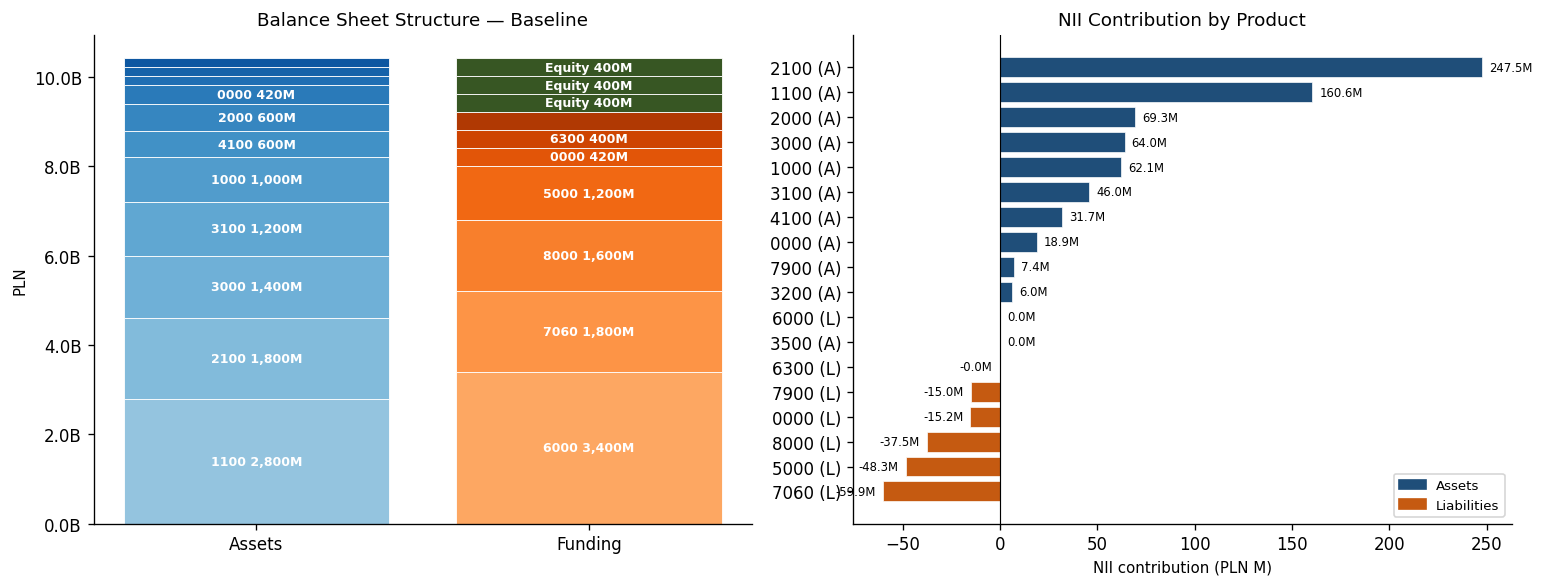

In [4]:
# ── Balance sheet waterfall chart ─────────────────────────────────────────────
assets  = bs_df[bs_df["side"] == "A"].sort_values("balance", ascending=False)
liabs   = bs_df[bs_df["side"] == "L"].sort_values("balance", ascending=False)
equity  = bs_df[bs_df["side"] == "E"].sort_values("balance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: stacked bar assets vs. funding --------------------------------
ax = axes[0]
x_pos = [0, 1]
labels = ["Assets", "Funding"]

# Assets stack
bottom = 0
colors_a = plt.cm.Blues(np.linspace(0.4, 0.85, len(assets)))
for (_, row), col in zip(assets.iterrows(), colors_a):
    bar = ax.bar(0, row["balance_m"], bottom=bottom, color=col, edgecolor="white", linewidth=0.5)
    if row["balance_m"] > total_assets / 1e6 * 0.04:
        ax.text(0, bottom + row["balance_m"] / 2,
                f"{row['product_code']} {row['balance_m']:,.0f}M",
                ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")
    bottom += row["balance_m"]

# Liabilities + equity stack
bottom = 0
colors_l = plt.cm.Oranges(np.linspace(0.4, 0.85, len(liabs)))
for (_, row), col in zip(liabs.iterrows(), colors_l):
    ax.bar(1, row["balance_m"], bottom=bottom, color=col, edgecolor="white", linewidth=0.5)
    if row["balance_m"] > total_assets / 1e6 * 0.04:
        ax.text(1, bottom + row["balance_m"] / 2,
                f"{row['product_code']} {row['balance_m']:,.0f}M",
                ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")
    bottom += row["balance_m"]

for (_, row) in equity.iterrows():
    ax.bar(1, row["balance_m"], bottom=bottom, color=C_EQUITY, edgecolor="white", linewidth=0.5)
    ax.text(1, bottom + row["balance_m"] / 2,
            f"Equity {row['balance_m']:,.0f}M",
            ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")
    bottom += row["balance_m"]

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.1f}B"))
ax.set_ylabel("PLN")
ax.set_title("Balance Sheet Structure — Baseline")

# --- Right: product NII rate contribution --------------------------------
ax2 = axes[1]
non_eq = bs_df[bs_df["side"] != "E"].sort_values("nii_contrib", ascending=True)
colors = [C_ASSET if s == "A" else C_LIAB for s in non_eq["side"]]
bars = ax2.barh(non_eq["product_code"] + " (" + non_eq["side"] + ")",
                non_eq["nii_contrib"] / 1e6, color=colors, edgecolor="white", linewidth=0.4)
_label_barh(ax2, np.arange(len(non_eq)), (non_eq["nii_contrib"] / 1e6).tolist(), fmt="{:,.1f}M")
ax2.axvline(0, color="black", linewidth=0.7)
ax2.set_xlabel("NII contribution (PLN M)")
ax2.set_title("NII Contribution by Product")
from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(color=C_ASSET, label="Assets"),
    Patch(color=C_LIAB,  label="Liabilities"),
], loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(_PARAMS), "..", "..",
            "bs_optimization", "output", "fig_baseline_bs.png"),
            dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Baseline Financial Measures

Key measures are computed from the current balance sheet using the Method B (CF-based) approach.
These serve as the reference point for evaluating optimization improvement.

| Measure | Definition |
|---|---|
| **NII** | Net Interest Income — sum of CF-weighted rates over each product's repricing schedule |
| **EL** | Expected Loss = Σ(PD × LGD × balance) — credit cost of the asset book |
| **CoC** | Cost of Capital = RWA × CET1_target × hurdle_rate — regulatory capital charge |
| **FTP** | Funds Transfer Pricing — internal transfer rate per cohort (market + liquidity spread); see Section 3 |
| **Margin** | Margin over FTP = client-rate NII adjusted for FTP — drives EP |
| **Fee** | Non-interest fee income = Σ fee_unit_rate × balance (per-product static assumption, e.g. mortgage/cash-loan servicing fees) — drives EP |
| **OpEx** | Operating cost = flat rate × balance, applied to both assets and liabilities |
| **AcqCost** | Marketing/acquisition cost = acq_cost_rate × growth ABOVE baseline weight (0 at baseline by construction); see Section 3 |
| **EP** | Economic Profit = Margin + Fee − EL − CoC − OpEx − AcqCost — risk-adjusted profitability |
| **EVE SOT** | Change in Economic Value of Equity under rate shock / T1 (EBA floor: −15%) |
| **NII SOT** | Change in NII under rate shock / T1 (EBA floor: −5%) |
| **LCR** | Liquidity Coverage Ratio = HQLA / net 30-day outflows |
| **NSFR** | Net Stable Funding Ratio = ASF / RSF |

The −15% / −5% figures above are the **EBA standard default floors**, used here only as a reference point for the current, un-optimized book. Section 4 onward uses this notebook's OWN configured floors (loaded from `optimizer_config.xlsx`, which may be tighter than the EBA default) — every result table/chart from Section 4 on states its own actual effective floor explicitly rather than assuming −15%/−5%.


In [5]:
from nii_eve_cf_fast import compute_nii_cf_all, compute_eve_cf_fast_all
from lcr_fast        import compute_lcr_fast
from nsfr_fast       import compute_nsfr_fast
from rwa_fast        import compute_rwa_fast
from bias_store      import load_bias_corrections, apply_eve_bias, apply_nii_bias

base_amounts = params.balance_arr.copy()

bias_eve, bias_nii, bias_scens = load_bias_corrections()

nii_dict  = compute_nii_cf_all(base_amounts, params, cr)
eve_dict  = compute_eve_cf_fast_all(base_amounts, params, cr)
lcr_dict  = compute_lcr_fast(base_amounts, params)
nsfr_dict = compute_nsfr_fast(base_amounts, params)
rwa_val   = compute_rwa_fast(base_amounts, params)

if bias_eve is not None:
    apply_eve_bias(eve_dict,  base_amounts, bias_eve, bias_scens)
    apply_nii_bias(nii_dict,  base_amounts, bias_nii, bias_scens)

nii_base  = nii_dict["base"]
el_base   = float(np.dot(base_amounts, params.el_unit))
coc_base  = rwa_val * params.cet1_target * params.coc_rate

# FTP / Margin / OpEx (2026-07-09 EP redefinition) -- computed here too so the
# Section 2 baseline chart/table can show NII and FTP as distinct components,
# matching the Section 4 baseline-vs-optimized decomposition below.
_ftp_rate_base = load_ftp_rates(params.cohort_id)
if _ftp_rate_base is None:
    _ftp_rate_base = np.zeros_like(params.nii_unit_rate)
_margin_rate_base = margin_unit_rate(params.nii_unit_rate, _ftp_rate_base, params.bs_side)
margin_base = float(np.dot(base_amounts, _margin_rate_base))
ftp_base    = margin_base - nii_base          # net FTP effect: NII -> Margin
fee_base    = float(np.dot(base_amounts, params.fee_unit_rate))   # non-interest fee income
opex_base   = OPEX_RATE * float(np.sum(base_amounts[~params.is_equity]))
ep_base     = margin_base + fee_base - el_base - coc_base - opex_base

shocked_scens = [s for s in cr.rate_scenario_ids if str(s) != "base"]

# ── Summary tables ───────────────────────────────────────────────────────────
nii_base_v = nii_dict["base"]

# EBA standard DEFAULT floors -- this section runs before the optimizer config
# is loaded (Section 4), so it checks the baseline book against the generic
# EBA floor, not this notebook's own (possibly tighter) configured floor.
EBA_EVE_FLOOR = -15.0
EBA_NII_FLOOR = -5.0

measures_df = pd.DataFrame([
    {"Measure": "NII (base)",              "Value": _fmt_m(nii_base)},
    {"Measure": "FTP effect (base)",        "Value": _fmt_m(ftp_base)},
    {"Measure": "Margin (base, over FTP)",  "Value": _fmt_m(margin_base)},
    {"Measure": "Fee income (base)",        "Value": _fmt_m(fee_base)},
    {"Measure": "Expected Loss (EL)",       "Value": _fmt_m(el_base)},
    {"Measure": "Cost of Capital",          "Value": _fmt_m(coc_base)},
    {"Measure": "OpEx",                     "Value": _fmt_m(opex_base)},
    {"Measure": "AcqCost (base)",            "Value": _fmt_m(0.0) + "  (no growth yet)"},
    {"Measure": "Economic Profit",          "Value": _fmt_m(ep_base)},
    {"Measure": "RWA",                      "Value": _fmt_m(rwa_val)},
    {"Measure": "T1 / RWA",                 "Value": f"{t1/rwa_val*100:.1f}%"},
])
display(style_table(measures_df, caption="Baseline measures"))

sot_eve_base = {str(s): eve_dict.get(str(s), 0.0) / t1 * 100 for s in shocked_scens}
sot_nii_base = {str(s): (nii_dict.get(str(s), nii_base_v) - nii_base_v) / t1 * 100 for s in shocked_scens}
display(style_sot(sot_table(sot_eve_base, EBA_EVE_FLOOR, "EVE SOT (% T1)"),
                   caption="EVE SOT — baseline book (vs EBA standard default floor)"))
display(style_sot(sot_table(sot_nii_base, EBA_NII_FLOOR, "NII SOT (% T1)"),
                   caption="NII SOT — baseline book (vs EBA standard default floor)"))

liq_df = pd.DataFrame(
    [{"Metric": f"LCR {ccy}", "Value": f"{v:.3f}"} for ccy, v in sorted(lcr_dict.items())]
    + [{"Metric": f"NSFR {ccy}", "Value": f"{v:.3f}"} for ccy, v in sorted(nsfr_dict.items())]
)
display(style_table(liq_df, caption="Baseline liquidity ratios"))

Measure,Value
NII (base),537.5M
FTP effect (base),-261.5M
"Margin (base, over FTP)",275.9M
Fee income (base),7.6M
Expected Loss (EL),45.7M
Cost of Capital,43.4M
OpEx,127.7M
AcqCost (base),0.0M (no growth yet)
Economic Profit,66.8M
RWA,"3,620.0M"


Scenario,EVE SOT (% T1),Floor (% T1),Status
flat,+0.96%,-15.0%,OK
own,+2.96%,-15.0%,OK
par_dn,+7.58%,-15.0%,OK
par_up,-6.96%,-15.0%,OK
sr_dn,+2.14%,-15.0%,OK
sr_up,-2.09%,-15.0%,OK
steep,-1.65%,-15.0%,OK


Scenario,NII SOT (% T1),Floor (% T1),Status
flat,-1.95%,-5.0%,OK
own,-1.74%,-5.0%,OK
par_dn,-4.13%,-5.0%,OK
par_up,+3.83%,-5.0%,OK
sr_dn,-0.16%,-5.0%,OK
sr_up,-0.16%,-5.0%,OK
steep,+2.01%,-5.0%,OK


Metric,Value
LCR PLN,2.944
NSFR PLN,1.609


**Reading this chart:** left panel is the EP decomposition (NII → ±FTP → +Fee → −EL → −CoC → −OpEx → EP) for today's book. Middle/right panels are the 7-scenario EVE/NII SOT check -- **against the EBA standard default floor** (−15% / −5% T1, dashed red line), *not* this notebook's own configured floor (used from Section 4 onward, which may be tighter or looser -- see the table footnote above). Bars are colored red where they breach that EBA default floor and are labeled with their exact %T1 value.

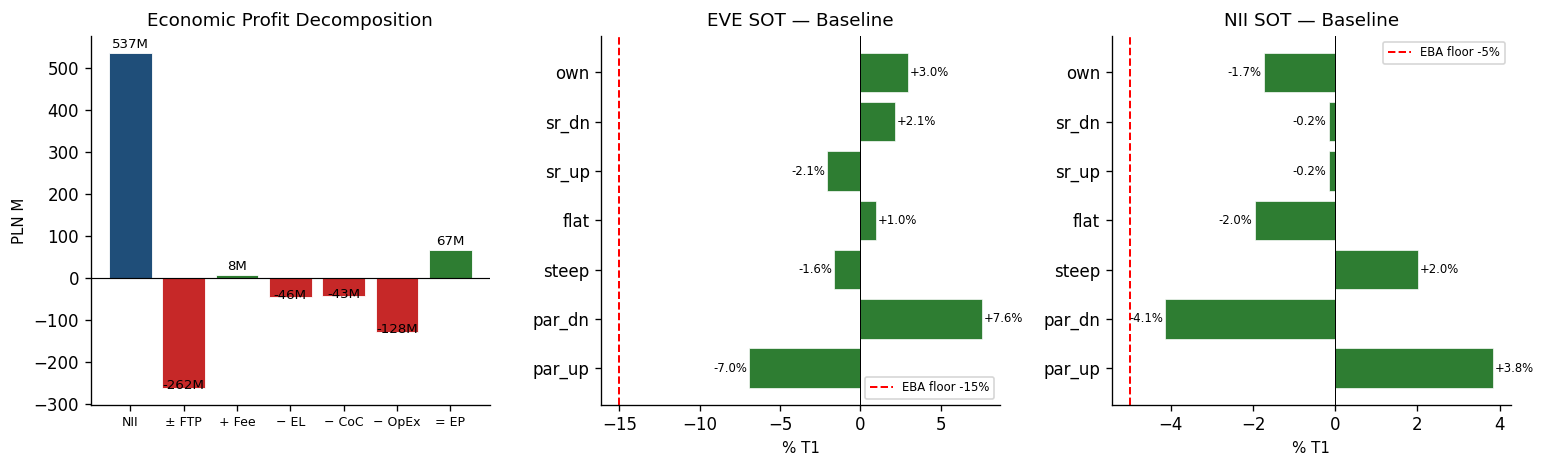

In [6]:
# ── Baseline measures chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# EP decomposition
ax = axes[0]
components = ["NII", "± FTP", "+ Fee", "− EL", "− CoC", "− OpEx", "= EP"]
values     = [nii_base/1e6, ftp_base/1e6, fee_base/1e6, -el_base/1e6, -coc_base/1e6, -opex_base/1e6, ep_base/1e6]
colors     = [C_ASSET, (C_POS if ftp_base >= 0 else C_NEG), (C_POS if fee_base >= 0 else C_NEG),
              C_NEG, C_NEG, C_NEG, C_POS if ep_base >= 0 else C_NEG]
bars = ax.bar(components, values, color=colors, edgecolor="white", linewidth=0.5)
ax.tick_params(axis="x", labelsize=7.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (5 if val >= 0 else -10),
            f"{val:,.0f}M", ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_ylabel("PLN M")
ax.set_title("Economic Profit Decomposition")

# EVE SOT
ax = axes[1]
sot_labels = [str(s) for s in shocked_scens]
sot_eve_vals = [eve_dict.get(str(s), 0.0) / t1 * 100 for s in shocked_scens]
cols = [C_POS if v >= EBA_EVE_FLOOR else C_NEG for v in sot_eve_vals]
ax.barh(sot_labels, sot_eve_vals, color=cols, edgecolor="white", linewidth=0.4)
_label_barh(ax, np.arange(len(sot_labels)), sot_eve_vals)
ax.axvline(EBA_EVE_FLOOR, color="red", linewidth=1.2, linestyle="--",
           label=f"EBA floor {EBA_EVE_FLOOR:+.0f}%")
ax.axvline(0,   color="black", linewidth=0.6)
ax.set_xlabel("% T1")
ax.set_title("EVE SOT — Baseline")
ax.legend(fontsize=7)

# NII SOT
ax = axes[2]
sot_nii_vals = [(nii_dict.get(str(s), nii_base_v) - nii_base_v) / t1 * 100 for s in shocked_scens]
cols = [C_POS if v >= EBA_NII_FLOOR else C_NEG for v in sot_nii_vals]
ax.barh(sot_labels, sot_nii_vals, color=cols, edgecolor="white", linewidth=0.4)
_label_barh(ax, np.arange(len(sot_labels)), sot_nii_vals)
ax.axvline(EBA_NII_FLOOR, color="red", linewidth=1.2, linestyle="--",
           label=f"EBA floor {EBA_NII_FLOOR:+.0f}%")
ax.axvline(0,  color="black", linewidth=0.6)
ax.set_xlabel("% T1")
ax.set_title("NII SOT — Baseline")
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(_ROOT, "bs_optimization", "output", "fig_baseline_measures.png"),
            dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Optimization Algorithm

### Objective

Maximize **Economic Profit** subject to regulatory and structural constraints:

$$\max_{\mathbf{x}} \; EP(\mathbf{x}) = Margin(\mathbf{x}) + Fee(\mathbf{x}) - EL(\mathbf{x}) - CoC(\mathbf{x}) - OpEx(\mathbf{x}) - AcqCost(\mathbf{x})$$

where $\mathbf{x} \in \mathbb{R}^P$ is the vector of product weights (fraction of total assets).
Every component except $AcqCost$ is **linear** in $\mathbf{x}$ directly; $AcqCost$ is
piecewise-linear (see below) and is folded into the LP via a standard epigraph
reformulation, so the problem is still a true Linear Program.

**Margin over FTP (2026-07-09):** $Margin$ replaces raw client-rate NII as the income
driver. Every cohort gets an FTP (Funds Transfer Pricing) rate = market rate at its
repricing tenor (fixing frequency for floating cohorts, months-to-maturity for fixed --
these coincide, since a fixed cohort's "next reprice" IS its maturity) + a linear
liquidity spread (0% at 0 months -> 0.5% at 120 months/10Y, capped beyond). Margin per
cohort = client_rate − FTP for assets, FTP − client_rate for liabilities (the asset pays
FTP to treasury; the liability is credited FTP by treasury). Computed once and cached
by `optimize_prep/python_code/build_ftp_rates.py` (see `ftp_store.py`) -- **not** threaded
through the CF-based EVE/NII SOT engine below, which stays client-rate based; NII is
still shown throughout this notebook as an informational reference, it just no longer
drives EP directly.

**OpEx:** a flat operating-cost rate (`bs_optimizer.OPEX_RATE = 0.65%/yr`) applied to
every non-equity product's balance, both assets AND liabilities (loan servicing and
deposit/funding servicing both cost money) -- same rate for every product, not
per-cohort. Note the rate is applied to BOTH sides of the balance sheet (≈2× total
assets, since assets ≈ liabilities + equity), so the *effective* cost is ≈1.3% of
total assets -- 0.65%/yr is the halved constant that recovers that intended figure
(2026-07-14 fix; was 1.3%/yr applied to the 2x base, i.e. an effective 2.6% of TA).

**AcqCost (2026-07-14):** unlike OpEx, marketing/acquisition cost is charged only on
a product's GROWTH above its baseline weight in the optimizer -- growing the book
costs more than servicing what's already there (new customer acquisition, broker
commissions, marketing campaigns), so it shouldn't scale with the whole balance the
way OpEx does. Per-product `acq_cost_rate` from `bs_structure` (currently: mortgage
0.10%/yr, cash loan 0.40%/yr, SME investment loan 0.30%/yr, 0 elsewhere), applied as
$AcqCost_j = acq\_cost\_rate_j \times \max(0, x_j - \bar{x}_j) \times TA$. Because
$\max(0, \cdot)$ isn't linear, it's implemented via the standard LP epigraph trick:
an auxiliary variable $g_j \geq x_j - \bar{x}_j$, $g_j \geq 0$, with $AcqCost_j =
acq\_cost\_rate_j \times g_j \times TA$ in the objective -- since $g_j$ only ever
costs, the solver drives it down to exactly $\max(0, x_j-\bar{x}_j)$ at optimality,
keeping the whole problem a true LP (no QP needed for this piece). Always 0 at
baseline by construction (no growth relative to itself).

### Solver

**Primary:** `scipy.optimize.linprog` with the **HiGHS** backend — a state-of-the-art LP solver.
For most problem sizes (< 50 products, 12 scenarios) the LP solves in under 1 second.

**Polish step:** When price-volume elasticity is active (rate changes as volumes grow),
the objective becomes quadratic (QP). The LP provides a warm start; SLSQP polishes the solution.

### Constraints

| Constraint | Form | Notes |
|---|---|---|
| Balance sheet integrity | $\sum_j x_j^A = \bar{w}^A$, $\sum_j x_j^F = \bar{w}^F$ | Assets and funding sums fixed |
| EVE SOT (EBA) | $\Delta EVE_s(\mathbf{x}) / T_1 \geq -15\%$ ∀s | Duration risk floor per shock scenario |
| NII SOT (EBA) | $\Delta NII_s(\mathbf{x}) / T_1 \geq -5\%$ ∀s | Income sensitivity floor |
| LCR | $HQLA / \text{net outflows} \geq 1.0$ per CCY | Short-term liquidity |
| NSFR | $ASF / RSF \geq 1.0$ per CCY | Structural liquidity |
| Capital floor | $T_1 / RWA \geq \text{min\_t1\_rwa}$ | Optional CET1 floor |
| Weight bounds | $x_j \in [lb_j, ub_j]$ | Mode-specific (see below) |

EVE and NII-delta constraints are **linear** in $\mathbf{x}$ — the LP coefficient matrix
$A_{\text{EVE}}$ is built by numerical differentiation (one evaluation per product).

### Optimization Modes

| Mode | Description | When to use |
|---|---|---|
| `full` | All non-equity products free in [0, 1] | Theoretical upper bound, no business constraints |
| `partial` | Only selected products freed; rest pinned | When specific products are targets of a strategic review |
| `max_shift` | Each product bounded to [w ± shift] | Realistic short-term plan (e.g. ±3pp per product) |
| `custom` | Per-product asymmetric [lb, ub] from Excel | Full business-scenario modeling |

### IRS Handling

Interest rate swaps (IRS) are always pinned at current notional — the optimizer does not vary them.
The `include_irs` flag controls whether IRS EVE/NII contribution enters the SOT constraints:
- **Hedged view** (`include_irs=True`): realistic book, swaps reduce duration risk
- **Unhedged view** (`include_irs=False`): pure banking book sensitivity

---
## 4. Optimization Results

In [7]:
cfg = load_optimizer_config(_XL, params)
cfg_df = pd.DataFrame([
    {"Parameter": "Mode",                   "Value": cfg.mode},
    {"Parameter": "Max shift",               "Value": f"{cfg.max_shift*100:.1f}%"},
    {"Parameter": "Include IRS",             "Value": str(cfg.include_irs)},
    {"Parameter": "EVE floor (effective)",   "Value": f"{cfg.sot_eve_floor - cfg.sot_eve_buffer:+.1f}% T1"},
    {"Parameter": "NII floor (effective)",   "Value": f"{cfg.sot_nii_floor - cfg.sot_nii_buffer:+.1f}% T1"},
    {"Parameter": "Min T1/RWA",              "Value": f"{cfg.min_t1_rwa*100:.0f}%"},
    {"Parameter": "Min LCR",                 "Value": f"{cfg.min_lcr:.2f}"},
    {"Parameter": "Min NSFR",                "Value": f"{cfg.min_nsfr:.2f}"},
])
display(style_table(cfg_df, caption="Optimizer configuration (optimizer_config.xlsx)"))

result = optimize_nii(cfg, params, cr)
_status = "SUCCESS" if result.success else "FAILED"
_feas   = "feasible" if result.feasible else "INFEASIBLE"
print(f"Optimization [{result.mode}] -- {_status} ({_feas})  |  {result.message}  |  "
      f"{result.n_iter} iterations, {result.elapsed_s:.2f}s  "
      f"-- full measures/SOT tables follow below")

Parameter,Value
Mode,max_shift
Max shift,3.0%
Include IRS,True
EVE floor (effective),-13.5% T1
NII floor (effective),-4.5% T1
Min T1/RWA,18%
Min LCR,1.40
Min NSFR,1.25


  IR derivatives: hedged (IRS in metrics)  |  notional 840M  |  2 cohort(s) — always pinned
  Bias corrections loaded: 7 scenarios, 535 cohorts
    EVE correction at baseline: par_up=+0.2M  par_dn=-0.2M  steep=-0.1M  flat=+0.1M  sr_up=+0.2M  sr_dn=-0.2M  own=-0.1M
  FTP rates loaded: mean 3.63% (market + liquidity component)
  Substitution constraints: 6 pairs active
  Price-volume elasticity: 15 products active — LP warm-start + QP polish
  Building LP coefficients...
  LP (HiGHS): optimal  nit=17  elapsed=0.1s
  QP polish (price-volume elasticity)...


  SLSQP QP: success=True  msg=Optimization terminated successfully
Optimization [max_shift] -- SUCCESS (feasible)  |  Optimization terminated successfully. (HiGHS Status 7: Optimal)  |  17 iterations, 0.12s  -- full measures/SOT tables follow below


In [8]:
# ── Collect product-level old/new weights ─────────────────────────────────────
_rows = [
    {
        "product_code": c.product_code,
        "side":         c.bs_side,
        "pct_old":      c.pct_old,
        "pct_new":      c.pct_new,
        "delta_pct":    c.delta_pct,
        "bal_old_m":    c.weight_old * params.total_assets / 1e6,
        "bal_new_m":    c.weight_new * params.total_assets / 1e6,
        "delta_bal_m":  (c.weight_new - c.weight_old) * params.total_assets / 1e6,
    }
    for c in result.product_changes
    if abs(c.delta_pct) > 0.001
]
if _rows:
    changes_df = pd.DataFrame(_rows).sort_values("delta_bal_m", ascending=False)
else:
    changes_df = pd.DataFrame(columns=["product_code", "side", "pct_old", "pct_new",
                                        "delta_pct", "bal_old_m", "bal_new_m", "delta_bal_m"])

display(style_changes(changes_table(result.product_changes, params.total_assets),
                      caption="Product changes (sorted by balance shift)"))

Code,Side,Change (M PLN),Δ (M),Δ pp
1000,A,"1,000 → 1,300",▲ +300.0,▲ +3.00
2000,A,600 → 900,▲ +300.0,▲ +3.00
2100,A,"1,800 → 2,100",▲ +300.0,▲ +3.00
3500,A,200 → 500,▲ +300.0,▲ +3.00
7900,L,400 → 516,▲ +116.1,▲ +1.16
1100,A,"2,800 → 2,705",▼ -95.1,▼ -0.95
5000,L,"1,200 → 1,084",▼ -116.1,▼ -1.16
3000,A,"1,400 → 1,206",▼ -194.4,▼ -1.94
3200,A,200 → 0,▼ -200.0,▼ -2.00
7900,A,200 → 0,▼ -200.0,▼ -2.00


**Reading these charts:** the balance-sheet shift and EP waterfall below compare the **baseline** book to the **EP-optimized** result from this run's `optimizer_config.xlsx` settings (printed above). The SOT pair checks EVE/NII SOT against **this notebook's own configured floor** (dashed red line) and -- like every SOT chart in Sections 2 and 4 -- is scored in the **hedged view**: the existing ~840M IRS book is included in the balance sheet used for these EVE/NII calculations. Compare against Section 10's chart later, which deliberately recomputes the same baseline **unhedged** (IRS excluded from the EVE/NII credit) to isolate the banking book's own risk.

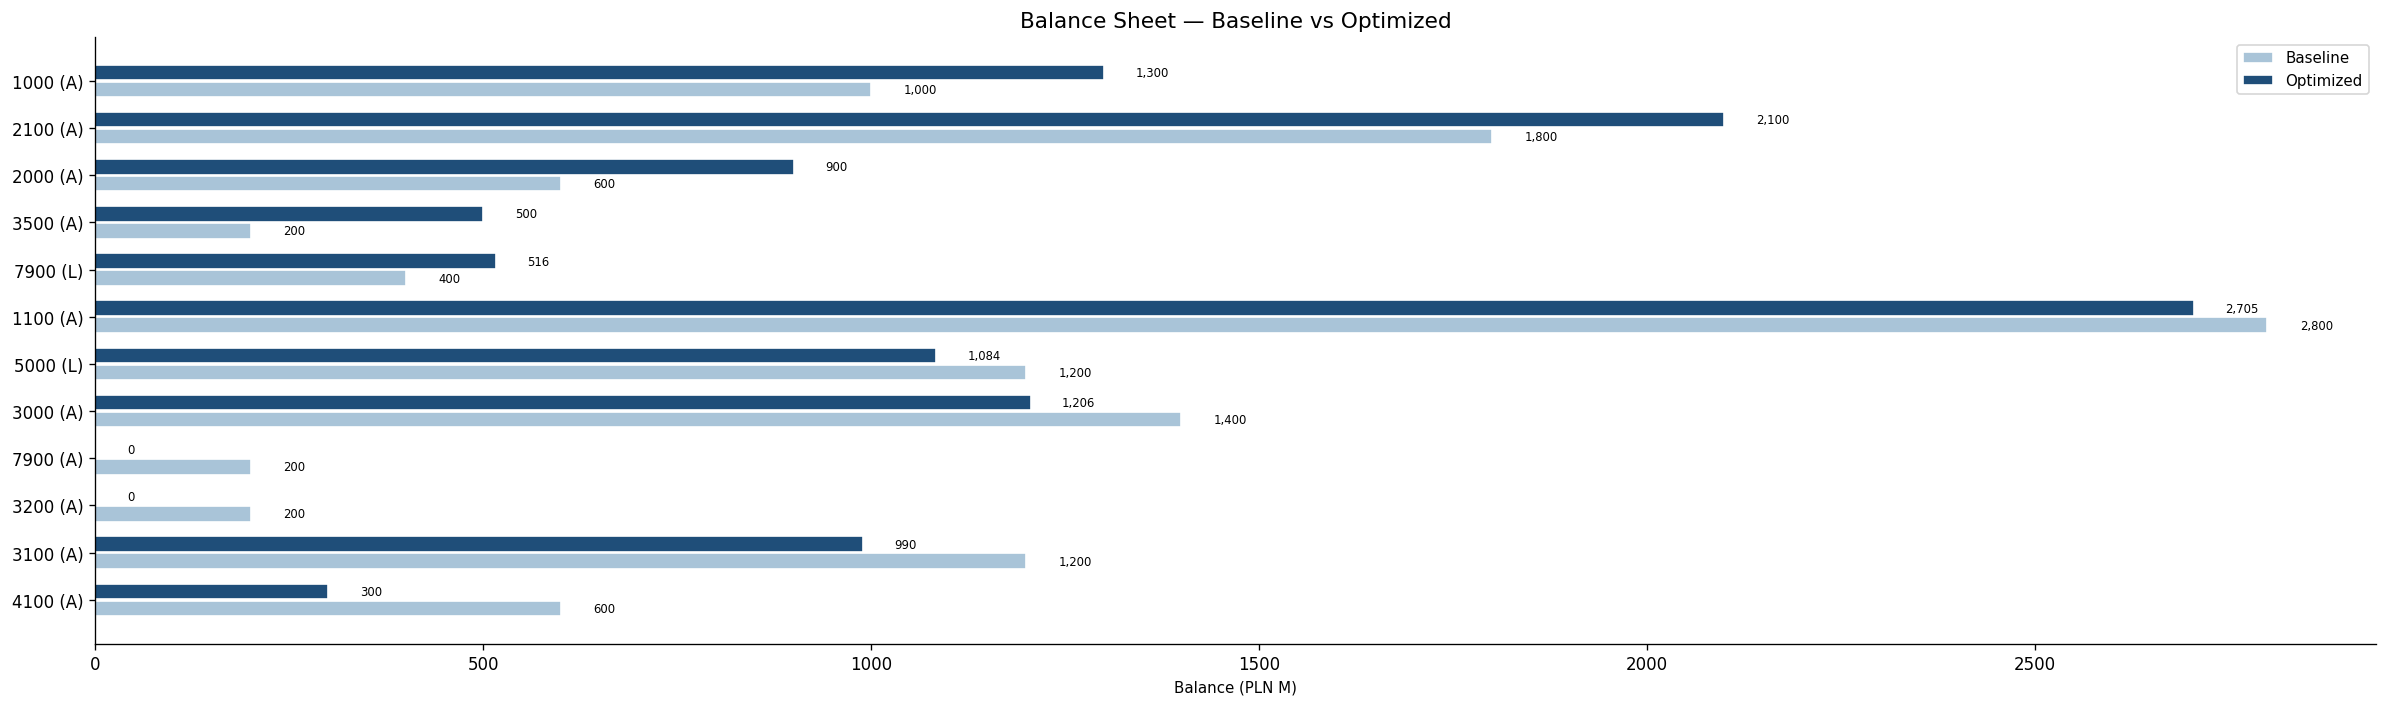

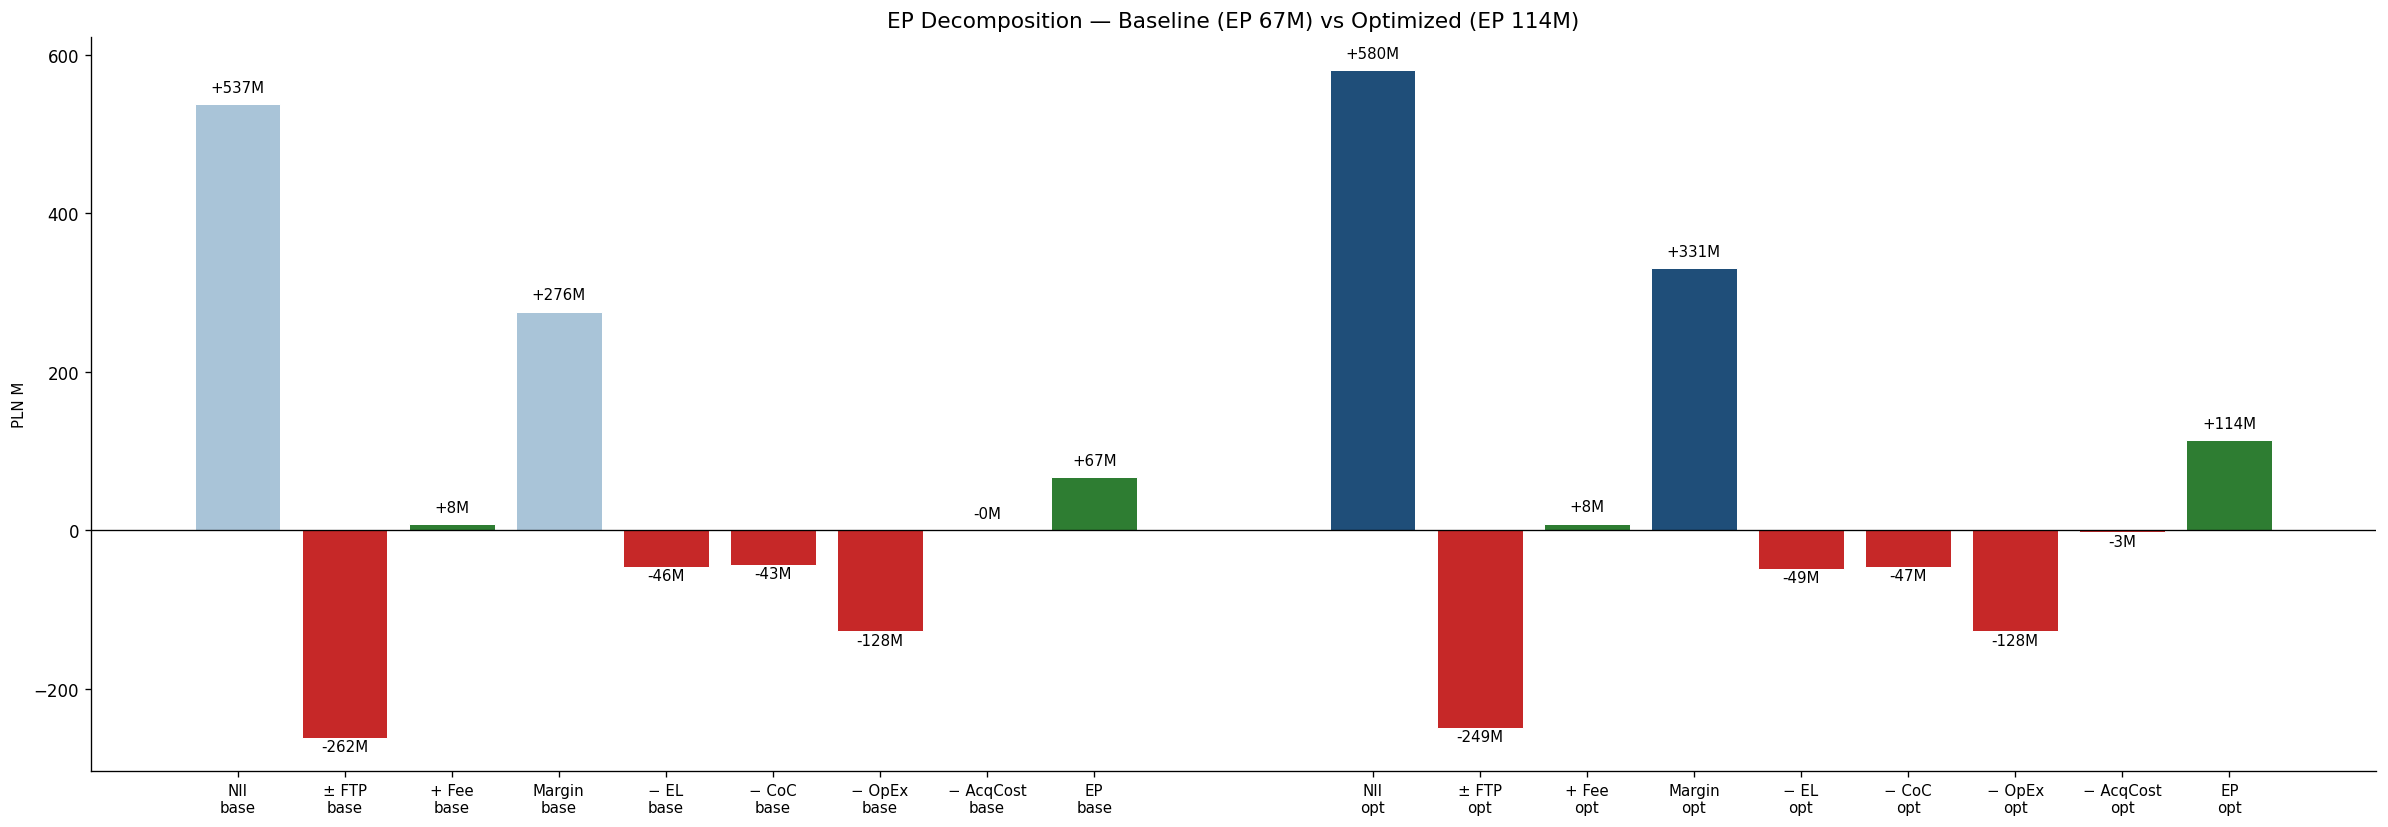

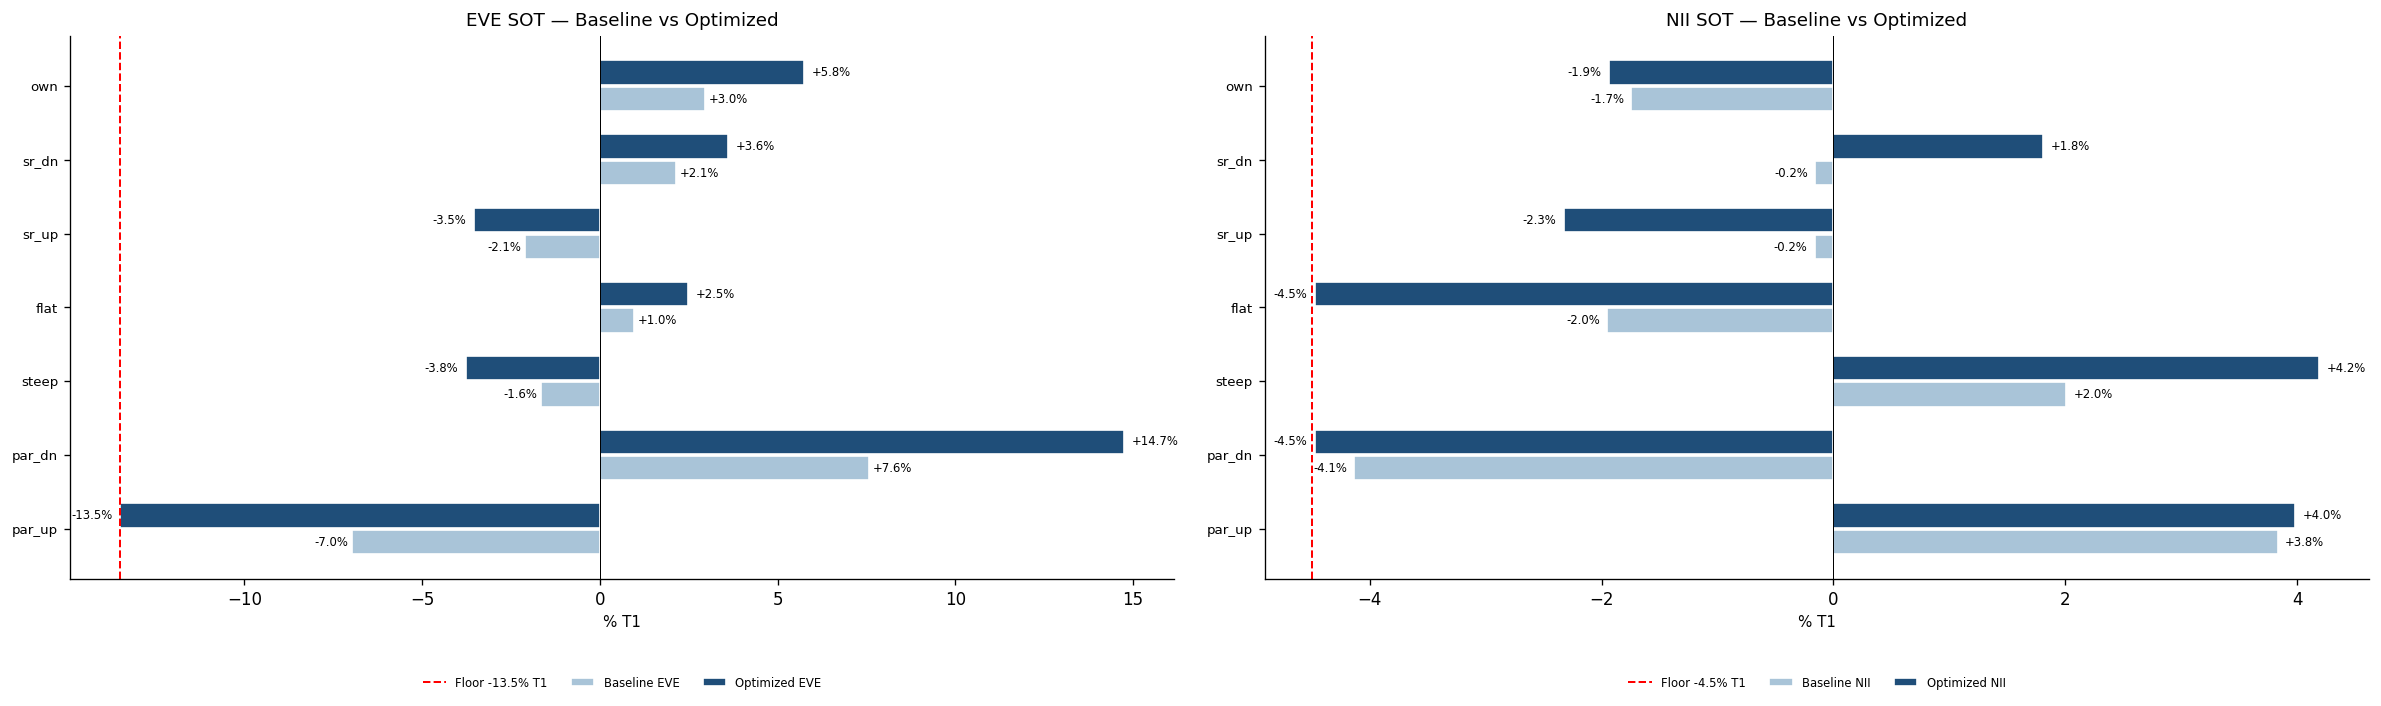

In [9]:
# ── Figure 1: Balance sheet shift (full width — its own line: this and the
#    EP waterfall below are the two headline charts of this section, so
#    neither gets squeezed into a subplot grid) ───────────────────────────────
fig, ax = plt.subplots(figsize=(20, 6))
df_plot = changes_df.sort_values("delta_bal_m", ascending=True)
y = np.arange(len(df_plot))
ax.barh(y - 0.18, df_plot["bal_old_m"], height=0.33,
        color=C_OLD, label="Baseline", edgecolor="white")
ax.barh(y + 0.18, df_plot["bal_new_m"], height=0.33,
        color=C_NEW, label="Optimized", edgecolor="white")
_label_barh(ax, y - 0.18, df_plot["bal_old_m"].tolist(), fmt="{:,.0f}")
_label_barh(ax, y + 0.18, df_plot["bal_new_m"].tolist(), fmt="{:,.0f}")
ytick_labels = df_plot["product_code"] + " (" + df_plot["side"] + ")"
ax.set_yticks(y)
ax.set_yticklabels(ytick_labels, fontsize=10)
ax.set_xlabel("Balance (PLN M)")
ax.set_title("Balance Sheet — Baseline vs Optimized", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(_ROOT, "bs_optimization", "output", "fig_optimization_bs_shift.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2: EP waterfall, baseline vs optimized (full width, via the SAME
#    plot_ep_waterfall() helper Sections 5/9 already use -- this used to be
#    a bespoke 18-bar version crammed into a quarter-page subplot with 6pt
#    labels and a separate BASELINE/OPTIMIZED banner that overlapped the
#    title; reusing the shared helper both fixes that and keeps every EP
#    waterfall in the notebook visually consistent) ────────────────────────────
ftp_old = result.margin_old - result.nii_old
ftp_new = result.margin_new - result.nii_new
comp_base = dict(nii=result.nii_old, ftp=ftp_old, fee=result.fee_old, margin=result.margin_old,
                  el=result.el_old, coc=result.coc_old, opex=result.opex_old,
                  acq_cost=result.acq_cost_old, ep=result.ep_old)
comp_opt = dict(nii=result.nii_new, ftp=ftp_new, fee=result.fee_new, margin=result.margin_new,
                 el=result.el_new, coc=result.coc_new, opex=result.opex_new,
                 acq_cost=result.acq_cost_new, ep=result.ep_new)

fig, ax = plt.subplots(figsize=(20, 7))
plot_ep_waterfall(ax, comp_base, comp_opt,
                   title=f"EP Decomposition — Baseline (EP {result.ep_old/1e6:,.0f}M) vs "
                         f"Optimized (EP {result.ep_new/1e6:,.0f}M)",
                   base_label="base", opt_label="opt")
plt.tight_layout()
plt.savefig(os.path.join(_ROOT, "bs_optimization", "output", "fig_optimization_ep_waterfall.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 3: SOT before / after, EVE and NII side by side -- uses THIS run's
#    actual effective floor, never a hardcoded EBA default, since
#    optimizer_config.xlsx can set its own. This pair reads fine as a 2-up
#    row (same floor-line comparison, not competing for width like the two
#    figures above) so only those needed splitting out. ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

ax = axes[0]
scen_labels = [str(s) for s in shocked_scens]
eve_old_vals = [eve_dict.get(str(s), 0.0) / t1 * 100 for s in shocked_scens]
eve_new_vals = [result.sot_eve.get(str(s), 0.0) for s in shocked_scens]

y2 = np.arange(len(scen_labels))
ax.barh(y2 - 0.18, eve_old_vals, height=0.33, color=C_OLD, label="Baseline EVE", edgecolor="white")
ax.barh(y2 + 0.18, eve_new_vals, height=0.33, color=C_NEW, label="Optimized EVE", edgecolor="white")
_label_barh(ax, y2 - 0.18, eve_old_vals)
_label_barh(ax, y2 + 0.18, eve_new_vals)
ax.axvline(result.sot_eve_floor, color="red", linewidth=1.2, linestyle="--",
           label=f"Floor {result.sot_eve_floor:+.1f}% T1")
ax.axvline(0,   color="black", linewidth=0.6)
ax.set_yticks(y2)
ax.set_yticklabels(scen_labels, fontsize=8)
ax.set_xlabel("% T1")
ax.set_title("EVE SOT — Baseline vs Optimized")
ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False)

ax = axes[1]
nii_old_vals = [(nii_dict.get(str(s), nii_base_v) - nii_base_v) / t1 * 100 for s in shocked_scens]
nii_new_vals = [result.sot_nii.get(str(s), 0.0) for s in shocked_scens]

ax.barh(y2 - 0.18, nii_old_vals, height=0.33, color=C_OLD, label="Baseline NII", edgecolor="white")
ax.barh(y2 + 0.18, nii_new_vals, height=0.33, color=C_NEW, label="Optimized NII", edgecolor="white")
_label_barh(ax, y2 - 0.18, nii_old_vals)
_label_barh(ax, y2 + 0.18, nii_new_vals)
ax.axvline(result.sot_nii_floor, color="red", linewidth=1.2, linestyle="--",
           label=f"Floor {result.sot_nii_floor:+.1f}% T1")
ax.axvline(0,  color="black", linewidth=0.6)
ax.set_yticks(y2)
ax.set_yticklabels(scen_labels, fontsize=8)
ax.set_xlabel("% T1")
ax.set_title("NII SOT — Baseline vs Optimized")
ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(_ROOT, "bs_optimization", "output", "fig_optimization_sot.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ── Measures comparison table ─────────────────────────────────────────────────
def _sign(v): return f"+{v:,.1f}" if v >= 0 else f"{v:,.1f}"

rows_tbl = [
    ["NII (M PLN) -- informational, client-rate", f"{result.nii_old/1e6:,.1f}",
                               f"{result.nii_new/1e6:,.1f}",
                               _sign(result.nii_improvement_m/1e6),
                               _sign(result.nii_improvement_pct) + "%"],
    ["Margin (M PLN) -- over FTP, drives EP", f"{result.margin_old/1e6:,.1f}",
                               f"{result.margin_new/1e6:,.1f}",
                               _sign((result.margin_new - result.margin_old)/1e6), ""],
    ["Fee income (M PLN) -- non-interest, drives EP", f"{result.fee_old/1e6:,.1f}",
                               f"{result.fee_new/1e6:,.1f}",
                               _sign((result.fee_new - result.fee_old)/1e6), ""],
    ["EL  (M PLN)",           f"{result.el_old/1e6:,.1f}",
                               f"{result.el_new/1e6:,.1f}",
                               _sign((result.el_new - result.el_old)/1e6), ""],
    ["CoC (M PLN)",           f"{result.coc_old/1e6:,.1f}",
                               f"{result.coc_new/1e6:,.1f}",
                               _sign((result.coc_new - result.coc_old)/1e6), ""],
    ["OpEx (M PLN)",          f"{result.opex_old/1e6:,.1f}",
                               f"{result.opex_new/1e6:,.1f}",
                               _sign((result.opex_new - result.opex_old)/1e6), ""],
    ["AcqCost (M PLN) -- marketing cost on growth only", f"{result.acq_cost_old/1e6:,.1f}",
                               f"{result.acq_cost_new/1e6:,.1f}",
                               _sign((result.acq_cost_new - result.acq_cost_old)/1e6), ""],
    ["Econ. Profit (M PLN)",  f"{result.ep_old/1e6:,.1f}",
                               f"{result.ep_new/1e6:,.1f}",
                               _sign(result.ep_improvement_m/1e6),
                               _sign(result.ep_improvement_pct) + "%"],
    ["T1/RWA",                f"{t1/rwa_val*100:.1f}%",
                               f"{result.t1_rwa_ratio*100:.1f}%", "", ""],
]

for ccy, lcr_v in sorted(result.lcr.items()):
    old_lcr = lcr_dict.get(ccy, float("nan"))
    rows_tbl.append([f"LCR {ccy}", f"{old_lcr:.3f}", f"{lcr_v:.3f}",
                     _sign(lcr_v - old_lcr), ""])
for ccy, nsfr_v in sorted(result.nsfr.items()):
    old_nsfr = nsfr_dict.get(ccy, float("nan"))
    rows_tbl.append([f"NSFR {ccy}", f"{old_nsfr:.3f}", f"{nsfr_v:.3f}",
                     _sign(nsfr_v - old_nsfr), ""])

for s in shocked_scens:
    old_v = eve_dict.get(str(s), 0.0) / t1 * 100
    new_v = result.sot_eve.get(str(s), 0.0)
    rows_tbl.append([f"EVE SOT {s} (% T1)", f"{old_v:+.2f}%", f"{new_v:+.2f}%",
                     _sign(new_v - old_v), ""])

for s in shocked_scens:
    old_v = (nii_dict.get(str(s), nii_base_v) - nii_base_v) / t1 * 100
    new_v = result.sot_nii.get(str(s), 0.0)
    rows_tbl.append([f"NII SOT {s} (% T1)", f"{old_v:+.2f}%", f"{new_v:+.2f}%",
                     _sign(new_v - old_v), ""])

summary_df = pd.DataFrame(rows_tbl, columns=["Measure", "Baseline", "Optimized", "Δ", "Δ %"])
display(summary_df.style
    .set_caption(f"Measures comparison — mode: {result.mode}  |  feasible: {result.feasible}")
    .set_table_styles([{"selector": "th", "props": [("background-color", "#1F4E79"),
                                                     ("color", "white")]}])
)

,Measure,Baseline,Optimized,Δ,Δ %
0,"NII (M PLN) -- informational, client-rate",537.5,586.3,+48.8,+9.1%
1,"Margin (M PLN) -- over FTP, drives EP",537.5,586.3,+48.8,
2,"Fee income (M PLN) -- non-interest, drives EP",7.6,8.3,+0.8,
3,EL (M PLN),45.7,48.8,+3.1,
4,CoC (M PLN),43.4,45.7,+2.2,
5,OpEx (M PLN),127.7,127.7,+0.0,
6,AcqCost (M PLN) -- marketing cost on growth only,0.0,2.8,+2.8,
7,Econ. Profit (M PLN),328.3,369.7,+41.4,+12.6%
8,T1/RWA,33.1%,21.0%,,
9,LCR PLN,2.944,2.068,-0.9,


In [11]:
# ── SOT breach counter: baseline vs EP-optimized, both WITH IRS -- recounted
#    against THIS run's own effective floor (result.sot_eve_floor/sot_nii_floor),
#    not Section 2's EBA-default floor, for a fair apples-to-apples comparison
#    (Section 2's sot_eve_base/sot_nii_base dicts are reused, just re-checked
#    against the tighter/looser floor this notebook actually configured) ──────
def _breach_count(sot_dict, floor):
    return sum(1 for v in sot_dict.values() if v < floor - 1e-6)

_n_scen = len(shocked_scens)
breach_rows = [
    ["EVE breaches (out of %d)" % _n_scen,
     f"{_breach_count(sot_eve_base, result.sot_eve_floor)}/{_n_scen}",
     f"{_breach_count(result.sot_eve, result.sot_eve_floor)}/{_n_scen}"],
    ["NII breaches (out of %d)" % _n_scen,
     f"{_breach_count(sot_nii_base, result.sot_nii_floor)}/{_n_scen}",
     f"{_breach_count(result.sot_nii, result.sot_nii_floor)}/{_n_scen}"],
]
breach_df = pd.DataFrame(breach_rows, columns=["Measure", "Baseline (with IRS)", "EP-optimized (with IRS)"])
display(style_table(breach_df, caption=f"SOT breach counter -- effective floors: "
                     f"EVE {result.sot_eve_floor:+.1f}% T1, NII {result.sot_nii_floor:+.1f}% T1"))


Measure,Baseline (with IRS),EP-optimized (with IRS)
EVE breaches (out of 7),0/7,0/7
NII breaches (out of 7),0/7,0/7


**Exact 165-curve stress test.** The breach counter above only tests today's
curve shocked 7 ways. `bank_reprice_at_weights.py` reruns the SAME production-grade
exact CF pricing engine `anchor_sot_exact.py`/`hedge_optimizer.py` already use and have
validated against production, at **165 alternative starting curves** (15 EBA-style
anchors + 150 stochastic shifts) × 6 EBA shocks each (990 curve x scenario combos, but breach counts below report DISTINCT CURVES with >=1 breach, not combo rows -- see the table's caption) — "what if TODAY's
curve had actually looked like one of these 165 alternatives" — parameterized by
product weight so both baseline and EP-optimized structures can be tested, not just
the real SQL book. Runtime: ~11.5 min/book (exact CF repricing, not the fast
approximation used elsewhere) — run once in the background and cached to
`bs_optimization/output/irrbb_165_*.xlsx`, not recomputed on every notebook run.
Baseline run cross-validated bit-for-bit against the existing independently-cached
165-curve reprice of the real book (max diff 8e-14, floating-point noise).


In [12]:
# ── Exact 165-curve x 6-scenario stress breach counter (baseline vs EP-optimized,
#    both WITH IRS) -- see markdown above. Breach pass/fail is recomputed here from
#    the raw delta_eve_pct_t1/delta_nii_pct_t1 against THIS notebook's own effective
#    floor (result.sot_eve_floor/sot_nii_floor) -- the cached xlsx's own eve_sot_pass/
#    nii_sot_pass columns use anchor_sot_exact.py's EBA DEFAULT floor (-15/-5), which
#    is NOT what the rest of this notebook checks against.
from bank_reprice_at_weights import load_cached

_bank_baseline = load_cached("baseline")
_bank_ep_opt   = load_cached("ep_optimized")

if _bank_baseline is None or _bank_ep_opt is None:
    print("Cached 165-curve results not found -- run bank_reprice_at_weights.run_and_cache() "
          "for 'baseline' and 'ep_optimized' first (~11.5 min per book).")
else:
    # Denominator is DISTINCT CURVES (165), not raw curve x scenario combo
    # rows (990) -- see _curve_breach_count()'s docstring in the setup cell.
    _n_curve = _bank_baseline.drop_duplicates(_CURVE_KEY_COLS).shape[0]   # 165

    bank_rows = [
        ["EVE breaches (curves, out of %d)" % _n_curve,
         f"{_curve_breach_count(_bank_baseline, 'delta_eve_pct_t1', result.sot_eve_floor)}/{_n_curve}",
         f"{_curve_breach_count(_bank_ep_opt, 'delta_eve_pct_t1', result.sot_eve_floor)}/{_n_curve}"],
        ["NII breaches (curves, out of %d)" % _n_curve,
         f"{_curve_breach_count(_bank_baseline, 'delta_nii_pct_t1', result.sot_nii_floor)}/{_n_curve}",
         f"{_curve_breach_count(_bank_ep_opt, 'delta_nii_pct_t1', result.sot_nii_floor)}/{_n_curve}"],
        ["Worst EVE (% T1)",
         f"{_bank_baseline['delta_eve_pct_t1'].min():.2f}",
         f"{_bank_ep_opt['delta_eve_pct_t1'].min():.2f}"],
        ["Worst NII (% T1)",
         f"{_bank_baseline['delta_nii_pct_t1'].min():.2f}",
         f"{_bank_ep_opt['delta_nii_pct_t1'].min():.2f}"],
    ]
    bank_df = pd.DataFrame(bank_rows, columns=["Measure", "Baseline (with IRS)", "EP-optimized (with IRS)"])
    display(style_table(bank_df, caption=f"Exact 165-curve stress test -- breach counts are DISTINCT "
                         f"CURVES with >=1 breaching scenario (out of {_n_curve}), not raw curve x "
                         f"scenario combos -- floors: EVE {result.sot_eve_floor:+.1f}% T1, "
                         f"NII {result.sot_nii_floor:+.1f}% T1"))

    print("NII breaches by starting-curve shape (distinct curves, not combo rows) -- "
          "why the 7-scenario counter above misses this: it only ever tests TODAY's "
          "curve, i.e. one single starting shape):")
    _nii_floor = result.sot_nii_floor
    for _label, _df in [("Baseline", _bank_baseline), ("EP-optimized", _bank_ep_opt)]:
        _b = _df[_df["delta_nii_pct_t1"] < _nii_floor - 1e-6].drop_duplicates(_CURVE_KEY_COLS)
        _counts = _b.groupby("shape").size().sort_values(ascending=False)
        print(f"  {_label}: " + ", ".join(f"{k}={v}" for k, v in _counts.items()))


Measure,Baseline (with IRS),EP-optimized (with IRS)
"EVE breaches (curves, out of 165)",0/165,0/165
"NII breaches (curves, out of 165)",133/165,72/165
Worst EVE (% T1),-5.75,-10.91
Worst NII (% T1),-10.12,-7.53


NII breaches by starting-curve shape (distinct curves, not combo rows) -- why the 7-scenario counter above misses this: it only ever tests TODAY's curve, i.e. one single starting shape):
  Baseline: steep=33, normal=33, humped=29, flat=22, inverted=16
  EP-optimized: steep=29, normal=22, flat=21


---
## 5. Phase A — Stochastic Optimization (Monte Carlo Interest-Rate Curves)

The single-period optimizer above uses the current market curve plus 7 fixed EBA/IRRBB
shock scenarios. **Phase A** extends this to a *stochastic* single-period optimization:
instead of one curve, we simulate hundreds of plausible near-term curve paths and
optimize the balance sheet for **risk-adjusted** economic profit — maximizing expected
EP while controlling the downside (CVaR) — rather than a single point estimate.

### Methodology

1. **Historical curve calibration** — fit a Diebold-Li Nelson-Siegel model
   (level β₀, slope β₁, curvature β₂) to 20 years of PLN WIBOR fixings (2005-2025).
2. **Factor risk model (PCA)** — decompose the historical month-over-month changes in
   (β₀, β₁, β₂) into 3 orthogonal principal risk factors.
3. **Monte Carlo simulation (mean-reverting)** — simulate N curve *paths* over a
   24-month horizon via a discretized mean-reverting (AR(1)/Ornstein-Uhlenbeck)
   process per NS factor, anchored at TODAY's curve: each of 24 monthly steps pulls
   the factor toward its historically-fitted long-run mean (from the SAME full 20y
   series) at a fitted reversion speed, plus a random shock drawn from the SAME
   PCA-fitted covariance step 2 already computed. A pure driftless random walk (this
   notebook's original approach) has no pull back toward historically-typical
   levels, so over a horizon this long it just gets arbitrarily wide around TODAY's
   level, however unusual that level is historically -- and today's level genuinely
   is unusual: PLN's ~5.06% level (β₀) sits at roughly the 75th-90th percentile of
   the full 20-year history (mean 2.78%, median 2.35%; 44% of all historical days
   were below 2%). The mean-reverting model lets the simulated distribution reach
   back down toward those historically-common levels with realistic probability,
   not only by lucky-tail chance.
4. **Fast re-pricing** — rather than re-running the full cash-flow engine for every
   Monte Carlo draw, each simulated curve shock is decomposed into the same 3
   tenor-shape functions (level / short-decay / long-decay) that underlie the 6
   official EBA shocks, and the **already-computed, exact** CF-based NII sensitivities
   to those 6 shocks (Section 3/4's `A_nii_delta`) are reused via linear superposition
   to approximate NII under the new shock. Per-scenario evaluation is then a matrix
   multiply — the optimizer scales to thousands of Monte Carlo scenarios in well
   under a second, with zero extra calls into the cohort-level CF engine.
5. **CVaR-LP** — maximize $E[EP] - \lambda \cdot CVaR_{\alpha}(-EP)$ via the
   Rockafellar-Uryasev linear formulation (adds one VaR variable and N slack
   variables — still a true LP, solved with HiGHS).
   Regulatory constraints (EVE/NII SOT, LCR, NSFR, T1/RWA) remain pinned to the
   **7 official EBA scenarios** — the Monte Carlo layer informs the objective
   (economic risk under market uncertainty), not the regulatory floor (which is
   defined by regulation, not simulation).

**Caveats** — this is a research/robustness layer, not (yet) a production ALCO tool:
the historical calibration window (2005-2025) spans the 2008 crisis and the 2021-2023
hiking cycle, so factor volatility (and the fitted reversion target/speed) reflect that
full stress-inclusive history, not "normal times" alone; the long-run mean each factor
reverts to is estimated from that SAME full window (a shorter/more-recent lookback
would give a different, likely higher, reversion target -- a natural follow-up
sensitivity, not yet implemented); the tenor-shape decomposition (step 4) is still a
first-order linear approximation (accurate for moderate shocks, in the same spirit as
the rest of this optimizer's linearised regulatory constraints).

**Reading this chart:** top panel is the fitted Nelson-Siegel level/slope/curvature (β0/β1/β2) factors over the full 20-year history -- the raw input to the Monte Carlo curve model below. Bottom panel is the calibration's fit quality (RMSE in bps) by tenor -- lower is better; labels show the exact bps value per tenor.

Historical PLN fixing panel: 5,433 daily obs, 2005-01-03 .. 2026-08-07
Nelson-Siegel tau = 2.50y (Diebold-Li default -- see ns_curve_model.DIEBOLD_LI_TAU)
Fit RMSE by tenor (bps):
tenor
1D    24.842722
1M     9.282167
3M    14.089696
6M    10.612928
1Y     6.165482
5Y    16.148205
7Y    10.865738


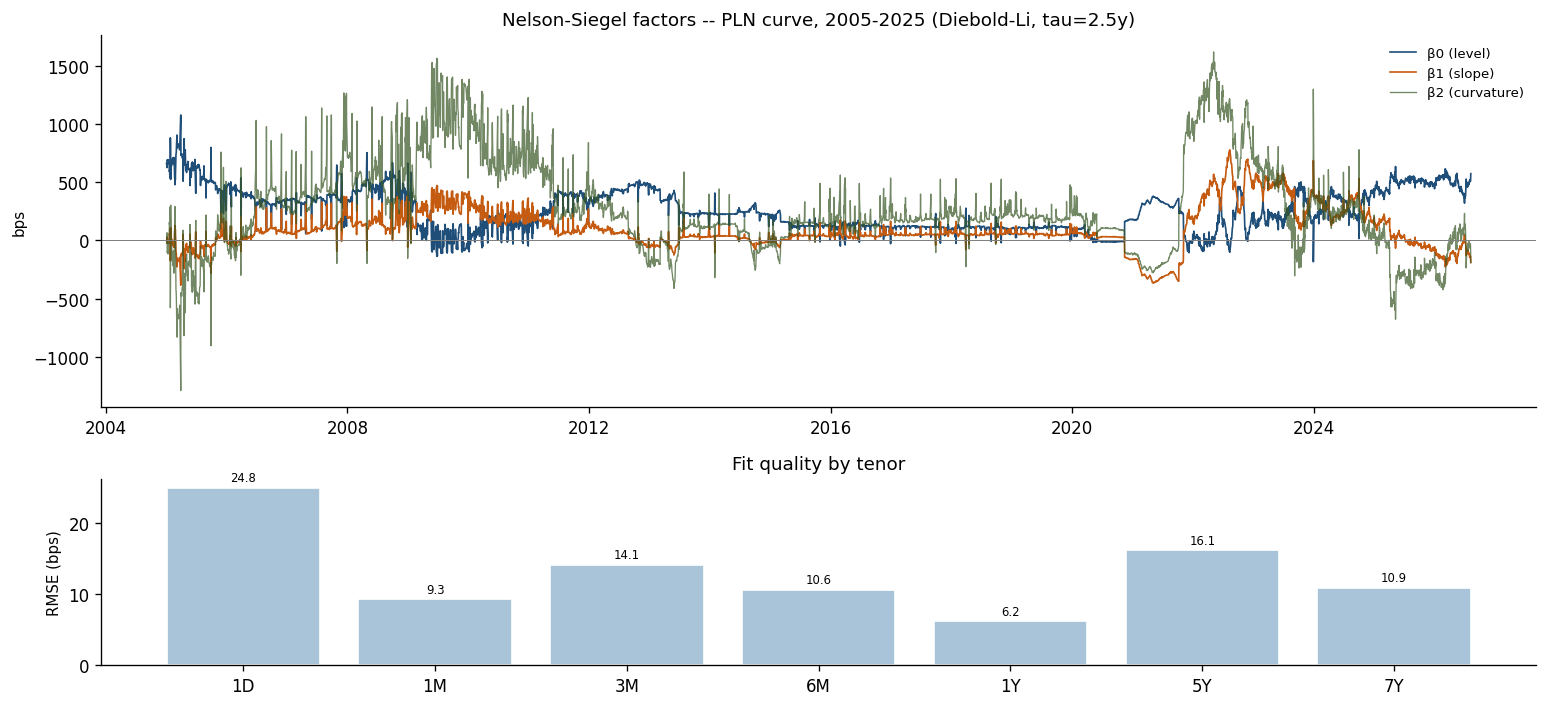

In [13]:
import ns_curve_model as nsm

panel  = nsm.load_historical_panel()
tau    = nsm.DIEBOLD_LI_TAU
ns_ts  = nsm.fit_ns_timeseries(panel, tau)
fit_q  = nsm.ns_fit_quality(panel, ns_ts, tau)

print(f"Historical PLN fixing panel: {panel.shape[0]:,} daily obs, {panel.index.min().date()} .. {panel.index.max().date()}")
print(f"Nelson-Siegel tau = {tau:.2f}y (Diebold-Li default -- see ns_curve_model.DIEBOLD_LI_TAU)")
print("Fit RMSE by tenor (bps):")
print(fit_q.to_string())

fig, axes = plt.subplots(2, 1, figsize=(13, 6), gridspec_kw={"height_ratios": [2, 1]})

ax = axes[0]
ax.plot(ns_ts.index, ns_ts["beta0"], color=C_ASSET,  lw=1.0, label="β0 (level)")
ax.plot(ns_ts.index, ns_ts["beta1"], color=C_LIAB,   lw=1.0, label="β1 (slope)")
ax.plot(ns_ts.index, ns_ts["beta2"], color=C_EQUITY, lw=0.8, alpha=0.7, label="β2 (curvature)")
ax.axhline(0, color="grey", lw=0.6)
ax.set_ylabel("bps")
ax.set_title(f"Nelson-Siegel factors -- PLN curve, 2005-2025 (Diebold-Li, tau={tau:.1f}y)")
ax.legend(loc="upper right", frameon=False, fontsize=8)

ax = axes[1]
_x_fitq = np.arange(len(fit_q))
ax.bar(_x_fitq, fit_q.values, color=C_OLD, edgecolor="white")
_label_bar(ax, _x_fitq, fit_q.values.tolist(), fmt="{:,.1f}")
ax.set_xticks(_x_fitq)
ax.set_xticklabels(fit_q.index)
ax.set_ylabel("RMSE (bps)")
ax.set_title("Fit quality by tenor")

plt.tight_layout()
plt.show()

### Factor risk model — PCA of monthly factor changes

Month-over-month changes in (β₀, β₁, β₂) are decomposed via PCA into 3 orthogonal
principal risk factors. This both diagnoses which factor (level, slope, or curvature)
drives most of the historical curve risk, and gives an efficient basis for Monte Carlo
sampling — draw independent standard normals in principal-component space, then rotate
back to (Δβ₀, Δβ₁, Δβ₂).

Monthly factor changes: n=259  (2005-2025, includes 2008 crisis + 2021-23 hiking cycle)
Explained variance by principal component:
  PC1:  96.0%
  PC2:   3.6%
  PC3:   0.4%


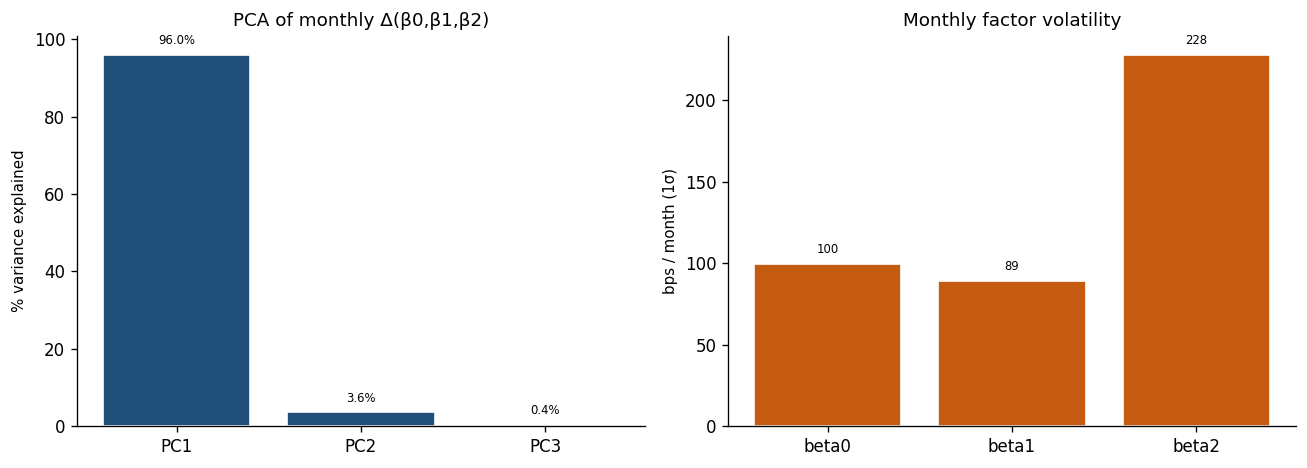

In [14]:
pca = nsm.factor_changes_pca(ns_ts)

print(f"Monthly factor changes: n={len(pca.changes)}  (2005-2025, includes 2008 crisis + 2021-23 hiking cycle)")
print("Explained variance by principal component:")
for i, pct in enumerate(pca.explained_pct):
    print(f"  PC{i+1}: {pct:5.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
_pc_labels = [f"PC{i+1}" for i in range(3)]
_x_pc = np.arange(3)
ax.bar(_x_pc, pca.explained_pct, color=C_ASSET, edgecolor="white")
_label_bar(ax, _x_pc, list(pca.explained_pct), fmt="{:.1f}%")
ax.set_xticks(_x_pc)
ax.set_xticklabels(_pc_labels)
ax.set_ylabel("% variance explained")
ax.set_title("PCA of monthly Δ(β0,β1,β2)")

ax = axes[1]
monthly_std = pca.changes.std()
_x_std = np.arange(len(monthly_std))
ax.bar(_x_std, monthly_std.values, color=C_LIAB, edgecolor="white")
_label_bar(ax, _x_std, monthly_std.values.tolist(), fmt="{:,.0f}")
ax.set_xticks(_x_std)
ax.set_xticklabels(monthly_std.index)
ax.set_ylabel("bps / month (1σ)")
ax.set_title("Monthly factor volatility")

plt.tight_layout()
plt.show()

**Reading this chart:** each thin line is one of the first 80 (of `N_SCENARIOS`) simulated 24-month-ahead curve paths under the mean-reverting model (not a single shock -- 24 monthly steps of reversion + noise, anchored at today's actual curve); the shaded band is the 5th-95th percentile envelope across all draws, and the red line is the mean path -- end-of-curve values for p05/mean/p95 are annotated on the right so they don't have to be read off the axis.

Mean-reversion fit (full 2005-2025 history), per NS factor:
  level (beta0): kappa=0.169/mo  half-life=3.7mo  long-run mean=+250bp
  slope (beta1): kappa=0.123/mo  half-life=5.3mo  long-run mean=+94bp
  curvature (beta2): kappa=0.177/mo  half-life=3.6mo  long-run mean=+278bp

Simulated 500 mean-reverting curve paths, 24-month horizon
  delta-beta std (bps): level=172  slope=176  curvature=393
  resulting level (beta0): min=-203  median=247  max=711bp (today=319bp)  |  41% of paths end below 200bp (~2%)


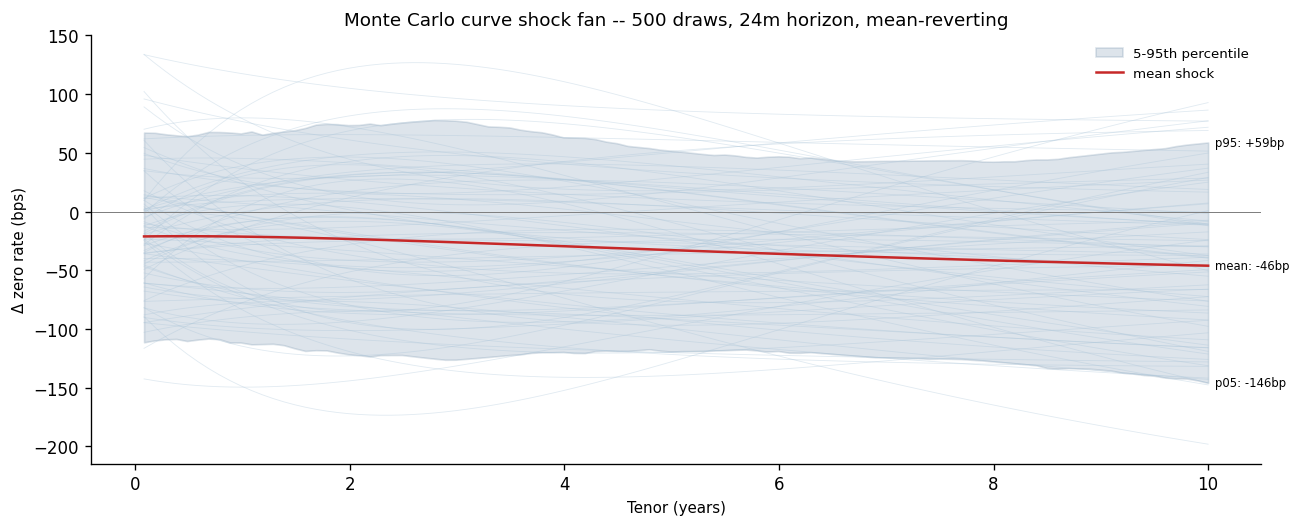

In [15]:
N_SCENARIOS    = 500
HORIZON_MONTHS = 24   # 2-year horizon -- long enough for mean-reversion to matter
MC_SEED        = 42

import anchor_sot_exact as ase
today_beta = ns_ts.asof(ase.REPORT_DATE)[["beta0", "beta1", "beta2"]].to_numpy(dtype=float)

mr = nsm.fit_mean_reversion(ns_ts)
print("Mean-reversion fit (full 2005-2025 history), per NS factor:")
for _name, _k, _b in zip(["level (beta0)", "slope (beta1)", "curvature (beta2)"], mr.kappa, mr.beta_bar):
    _half_life = np.log(0.5) / np.log(1 - _k)
    print(f"  {_name}: kappa={_k:.3f}/mo  half-life={_half_life:.1f}mo  long-run mean={_b:+.0f}bp")

factor_draws = nsm.simulate_mean_reverting_shocks(pca, mr, today_beta, n_scenarios=N_SCENARIOS,
                                                   horizon_months=HORIZON_MONTHS, seed=MC_SEED)
print(f"\nSimulated {N_SCENARIOS} mean-reverting curve paths, {HORIZON_MONTHS}-month horizon")
print(f"  delta-beta std (bps): level={factor_draws[:,0].std():.0f}  slope={factor_draws[:,1].std():.0f}  curvature={factor_draws[:,2].std():.0f}")
_final_level = today_beta[0] + factor_draws[:, 0]
print(f"  resulting level (beta0): min={_final_level.min():.0f}  median={np.median(_final_level):.0f}  "
f"max={_final_level.max():.0f}bp (today={today_beta[0]:.0f}bp)  |  "
f"{(_final_level<200).mean():.0%} of paths end below 200bp (~2%)")

t_grid_plot  = np.linspace(1/12, 10, 100)
shock_curves = nsm.ns_curve_bps(factor_draws, tau, t_grid_plot)   # (N, len(t_grid_plot))

fig, ax = plt.subplots(figsize=(11, 4.5))
for i in range(min(80, N_SCENARIOS)):
    ax.plot(t_grid_plot, shock_curves[i], color=C_OLD, lw=0.5, alpha=0.35)
p05 = np.percentile(shock_curves, 5, axis=0)
p95 = np.percentile(shock_curves, 95, axis=0)
ax.fill_between(t_grid_plot, p05, p95, color=C_ASSET, alpha=0.15, label="5-95th percentile")
_mean_curve = shock_curves.mean(axis=0)
ax.plot(t_grid_plot, _mean_curve, color=C_NEG, lw=1.5, label="mean shock")
_t_end = t_grid_plot[-1]
for _val, _lbl in [(p95[-1], "p95"), (_mean_curve[-1], "mean"), (p05[-1], "p05")]:
    ax.annotate(f"{_lbl}: {_val:+.0f}bp", (_t_end, _val), textcoords="offset points",
                xytext=(4, 0), fontsize=7, va="center")
ax.axhline(0, color="grey", lw=0.6)
ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Δ zero rate (bps)")
ax.set_title(f"Monte Carlo curve shock fan -- {N_SCENARIOS} draws, {HORIZON_MONTHS}m horizon, mean-reverting")
ax.legend(loc="upper right", frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

### Risk-adjusted optimization result

Maximize $E[EP] - \lambda \cdot CVaR_{95}(-EP)$ over the same `max_shift` bounds
(±3pp) and regulatory constraints as Section 4, using the Monte Carlo scenario set
above. Regulatory constraints stay pinned to the 7 official EBA scenarios; only the
objective sees the Monte Carlo curves.

In [16]:
from stochastic_optimizer import (
    StochasticConfig, build_scenario_ep_matrix, optimize_stochastic, sweep_risk_frontier,
)

C_scenarios, lp_blocks = build_scenario_ep_matrix(cfg, StochasticConfig(), params, cr, factor_draws, tau)

stoch_cfg = StochasticConfig(
    n_scenarios=N_SCENARIOS, horizon_months=HORIZON_MONTHS,
    cvar_alpha=0.95, risk_lambda=1.0, seed=MC_SEED,
)
stoch_result = optimize_stochastic(cfg, stoch_cfg, params, cr, C_scenarios, lp_blocks)
stoch_result.print_summary()


Stochastic optimization (Phase A) - SUCCESS
  N scenarios: 500   lambda: 1.00   CVaR alpha: 0.95   elapsed: 0.01s
  Optimization terminated successfully. (HiGHS Status 7: Optimal)
  E[EP]           :     314.06M  ->      354.89M   (+40.82M)
  Worst-tail EP95:     283.24M  ->      318.26M   (+35.03M)   (avg EP over worst 5% of scenarios)
  AcqCost         :       0.00M  ->        3.05M   (marketing cost, only on growth above baseline; already netted into E[EP]/CVaR above)

  Product weight changes:
    3500   A    2.00% ->   5.00%  (+3.00 pp)
    1000   A   10.00% ->  13.00%  (+3.00 pp)
    1100   A   28.00% ->  25.00%  (-3.00 pp)
    2000   A    6.00% ->   9.00%  (+3.00 pp)
    2100   A   18.00% ->  21.00%  (+3.00 pp)
    4100   A    6.00% ->   3.00%  (-3.00 pp)
    5000   L   12.00% ->   9.00%  (-3.00 pp)
    8000   L   16.00% ->  19.00%  (+3.00 pp)
    3200   A    2.00% ->   0.00%  (-2.00 pp)
    7900   A    2.00% ->   0.00%  (-2.00 pp)
    3000   A   14.00% ->  13.00%  (-1.00 pp)
 

In [17]:
# ── Baseline vs stochastic-optimized: comparison table + SOT breach check ────
# The Monte Carlo layer only feeds the OBJECTIVE (E[EP] - lambda*CVaR); the
# regulatory floor is still the 7 official EBA scenarios (see this section's
# intro). This checks the stochastic-optimized weights against THAT floor,
# using this notebook's own configured floor (not a hardcoded EBA default).
from bs_optimizer import _ProductMap

pm_stoch = _ProductMap(params)
amounts_stoch = pm_stoch.to_amounts(stoch_result.weights_new, params.total_assets)

nii_stoch_dict = compute_nii_cf_all(amounts_stoch, params, cr)
eve_stoch_dict = compute_eve_cf_fast_all(amounts_stoch, params, cr)
if bias_eve is not None:
    apply_eve_bias(eve_stoch_dict, amounts_stoch, bias_eve, bias_scens)
    apply_nii_bias(nii_stoch_dict, amounts_stoch, bias_nii, bias_scens)

nii_stoch_base = nii_stoch_dict["base"]
sot_eve_stoch = {str(s): eve_stoch_dict.get(str(s), 0.0) / t1 * 100 for s in shocked_scens}
sot_nii_stoch = {str(s): (nii_stoch_dict.get(str(s), nii_stoch_base) - nii_stoch_base) / t1 * 100
                 for s in shocked_scens}

eve_floor_eff_s5 = cfg.sot_eve_floor - cfg.sot_eve_buffer
nii_floor_eff_s5 = cfg.sot_nii_floor - cfg.sot_nii_buffer

stoch_comp_rows = [
    ["E[EP] (M PLN)",
     f"{stoch_result.ep_mean_old/1e6:,.1f}", f"{stoch_result.ep_mean_new/1e6:,.1f}",
     f"{(stoch_result.ep_mean_new - stoch_result.ep_mean_old)/1e6:+,.1f}"],
    [f"CVaR{int(stoch_result.cvar_alpha*100)} worst-tail EP (M PLN)",
     f"{stoch_result.cvar_old/1e6:,.1f}", f"{stoch_result.cvar_new/1e6:,.1f}",
     f"{(stoch_result.cvar_new - stoch_result.cvar_old)/1e6:+,.1f}"],
    ["VaR-EP threshold (M PLN)", "-", f"{stoch_result.var_new/1e6:,.1f}", ""],
]
stoch_comp_df = pd.DataFrame(stoch_comp_rows, columns=["Measure", "Current book", "Stochastic-optimized", "Δ"])
display(style_table(
    stoch_comp_df,
    caption=f"Stochastic optimization (λ={stoch_result.risk_lambda:g}, "
            f"{stoch_result.n_scenarios} MC scenarios) — current book vs optimized",
))

# _breach_count() is the helper defined in Section 4's breach-counter cell
# above -- reused here so baseline and stochastic-optimized are counted
# the same way, against THIS section's own effective floor.
stoch_breach_rows = [
    ["EVE breaches (out of %d)" % len(sot_eve_stoch),
     f"{_breach_count(sot_eve_base, eve_floor_eff_s5)}/{len(sot_eve_stoch)}",
     f"{_breach_count(sot_eve_stoch, eve_floor_eff_s5)}/{len(sot_eve_stoch)}"],
    ["NII breaches (out of %d)" % len(sot_nii_stoch),
     f"{_breach_count(sot_nii_base, nii_floor_eff_s5)}/{len(sot_nii_stoch)}",
     f"{_breach_count(sot_nii_stoch, nii_floor_eff_s5)}/{len(sot_nii_stoch)}"],
]
stoch_breach_df = pd.DataFrame(stoch_breach_rows, columns=["Measure", "Baseline", "Stochastic-optimized"])
display(style_table(stoch_breach_df, caption=f"Official 7-scenario EBA SOT breach counter -- "
                     f"effective floors: EVE {eve_floor_eff_s5:+.1f}% T1, NII {nii_floor_eff_s5:+.1f}% T1"))

display(style_sot(sot_table(sot_eve_stoch, eve_floor_eff_s5, "EVE SOT (% T1)"),
                   caption="EVE SOT — stochastic-optimized weights"))
display(style_sot(sot_table(sot_nii_stoch, nii_floor_eff_s5, "NII SOT (% T1)"),
                   caption="NII SOT — stochastic-optimized weights"))


Measure,Current book,Stochastic-optimized,Δ
E[EP] (M PLN),314.1,354.9,+40.8
CVaR95 worst-tail EP (M PLN),283.2,318.3,+35.0
VaR-EP threshold (M PLN),-,324.6,


Measure,Baseline,Stochastic-optimized
EVE breaches (out of 7),0/7,0/7
NII breaches (out of 7),0/7,0/7


Scenario,EVE SOT (% T1),Floor (% T1),Status
flat,+1.52%,-13.5%,OK
own,+3.83%,-13.5%,OK
par_dn,+9.81%,-13.5%,OK
par_up,-9.00%,-13.5%,OK
sr_dn,+2.51%,-13.5%,OK
sr_up,-2.46%,-13.5%,OK
steep,-2.39%,-13.5%,OK


Scenario,NII SOT (% T1),Floor (% T1),Status
flat,-2.79%,-4.5%,OK
own,-1.31%,-4.5%,OK
par_dn,-3.00%,-4.5%,OK
par_up,+2.65%,-4.5%,OK
sr_dn,+1.00%,-4.5%,OK
sr_up,-1.37%,-4.5%,OK
steep,+2.58%,-4.5%,OK


**Exact Monte Carlo stress test.** The breach counter above only checks the stochastic-optimized weights against the 7 official EBA scenarios applied to TODAY's curve. `precompute_mc500_irrbb.py` reruns the SAME production-grade exact CF pricing engine (`anchor_sot_exact.py`, already validated against production and already used for Section 4's 165-curve test) at the exact **500 Monte Carlo curves** simulated above (same seed, same draws -- not a new/different random sample), each shocked by the 6 official EBA scenarios (par_up/dn, steep, flat, sr_up/dn -- `own` excluded, matching Section 4's convention) = 3,000 curve x scenario combos per book — but the breach counts below report **distinct curves with >=1 breaching scenario (out of 500)**, not raw combo rows, since a single curve breaching under more than one shock direction is one risky market state, not several. Unlike the 165-curve test ("what if today's curve had looked like a completely different historical regime"), these 500 curves are genuine (mean-reverting) 24-month-ahead paths *from* today's actual curve -- the same distribution the stochastic optimizer above is maximizing E[EP] against. Runtime: ~8 min/book (exact CF repricing, not the fast approximation the EP objective above uses) -- run once in the background via `precompute_mc500_irrbb.py` and cached to `bs_optimization/output/irrbb_mc500_*.xlsx`, not recomputed on every notebook run.


In [18]:
# ── Exact 500-MC-scenario x 6-EBA-shock stress breach counter (baseline vs
#    stochastic-optimized) -- see markdown above. Same curve draws (seed=42)
#    the stochastic optimizer used for its E[EP]/CVaR objective, now exactly
#    repriced instead of approximated. Checked against THIS section's own
#    effective floor (eve_floor_eff_s5/nii_floor_eff_s5, already defined
#    above), not a hardcoded EBA default. ────────────────────────────────
from bank_reprice_at_weights import load_cached as _load_cached_irrbb

_mc_baseline = _load_cached_irrbb("baseline", filename_prefix="irrbb_mc500")
_mc_stoch    = _load_cached_irrbb("stochastic", filename_prefix="irrbb_mc500")

if _mc_baseline is None or _mc_stoch is None:
    print("Cached 500-MC-scenario results not found -- run "
          "bs_optimization/python_code/precompute_mc500_irrbb.py first (~16 min).")
else:
    # Denominator is DISTINCT CURVES (500), not raw curve x scenario combo
    # rows (3000) -- one market state tested against 6 shock directions that
    # breaches under more than one of them is still ONE risky scenario, not
    # several -- see _curve_breach_count()'s docstring in the setup cell.
    _n_curve_mc = _mc_baseline.drop_duplicates(_CURVE_KEY_COLS).shape[0]   # 500

    mc_rows = [
        ["EVE breaches (curves, out of %d)" % _n_curve_mc,
         f"{_curve_breach_count(_mc_baseline, 'delta_eve_pct_t1', eve_floor_eff_s5)}/{_n_curve_mc}",
         f"{_curve_breach_count(_mc_stoch, 'delta_eve_pct_t1', eve_floor_eff_s5)}/{_n_curve_mc}"],
        ["NII breaches (curves, out of %d)" % _n_curve_mc,
         f"{_curve_breach_count(_mc_baseline, 'delta_nii_pct_t1', nii_floor_eff_s5)}/{_n_curve_mc}",
         f"{_curve_breach_count(_mc_stoch, 'delta_nii_pct_t1', nii_floor_eff_s5)}/{_n_curve_mc}"],
        ["Worst EVE (% T1)",
         f"{_mc_baseline['delta_eve_pct_t1'].min():.2f}",
         f"{_mc_stoch['delta_eve_pct_t1'].min():.2f}"],
        ["Worst NII (% T1)",
         f"{_mc_baseline['delta_nii_pct_t1'].min():.2f}",
         f"{_mc_stoch['delta_nii_pct_t1'].min():.2f}"],
    ]
    mc_df = pd.DataFrame(mc_rows, columns=["Measure", "Baseline", "Stochastic-optimized"])
    display(style_table(mc_df, caption=f"Exact 500-Monte-Carlo-scenario stress test -- breach counts "
                         f"are DISTINCT CURVES with >=1 breaching scenario (out of {_n_curve_mc}), not "
                         f"raw curve x scenario combos -- floors: EVE {eve_floor_eff_s5:+.1f}% T1, "
                         f"NII {nii_floor_eff_s5:+.1f}% T1"))

Measure,Baseline,Stochastic-optimized
"EVE breaches (curves, out of 500)",0/500,0/500
"NII breaches (curves, out of 500)",185/500,17/500
Worst EVE (% T1),-7.39,-9.57
Worst NII (% T1),-6.49,-5.00


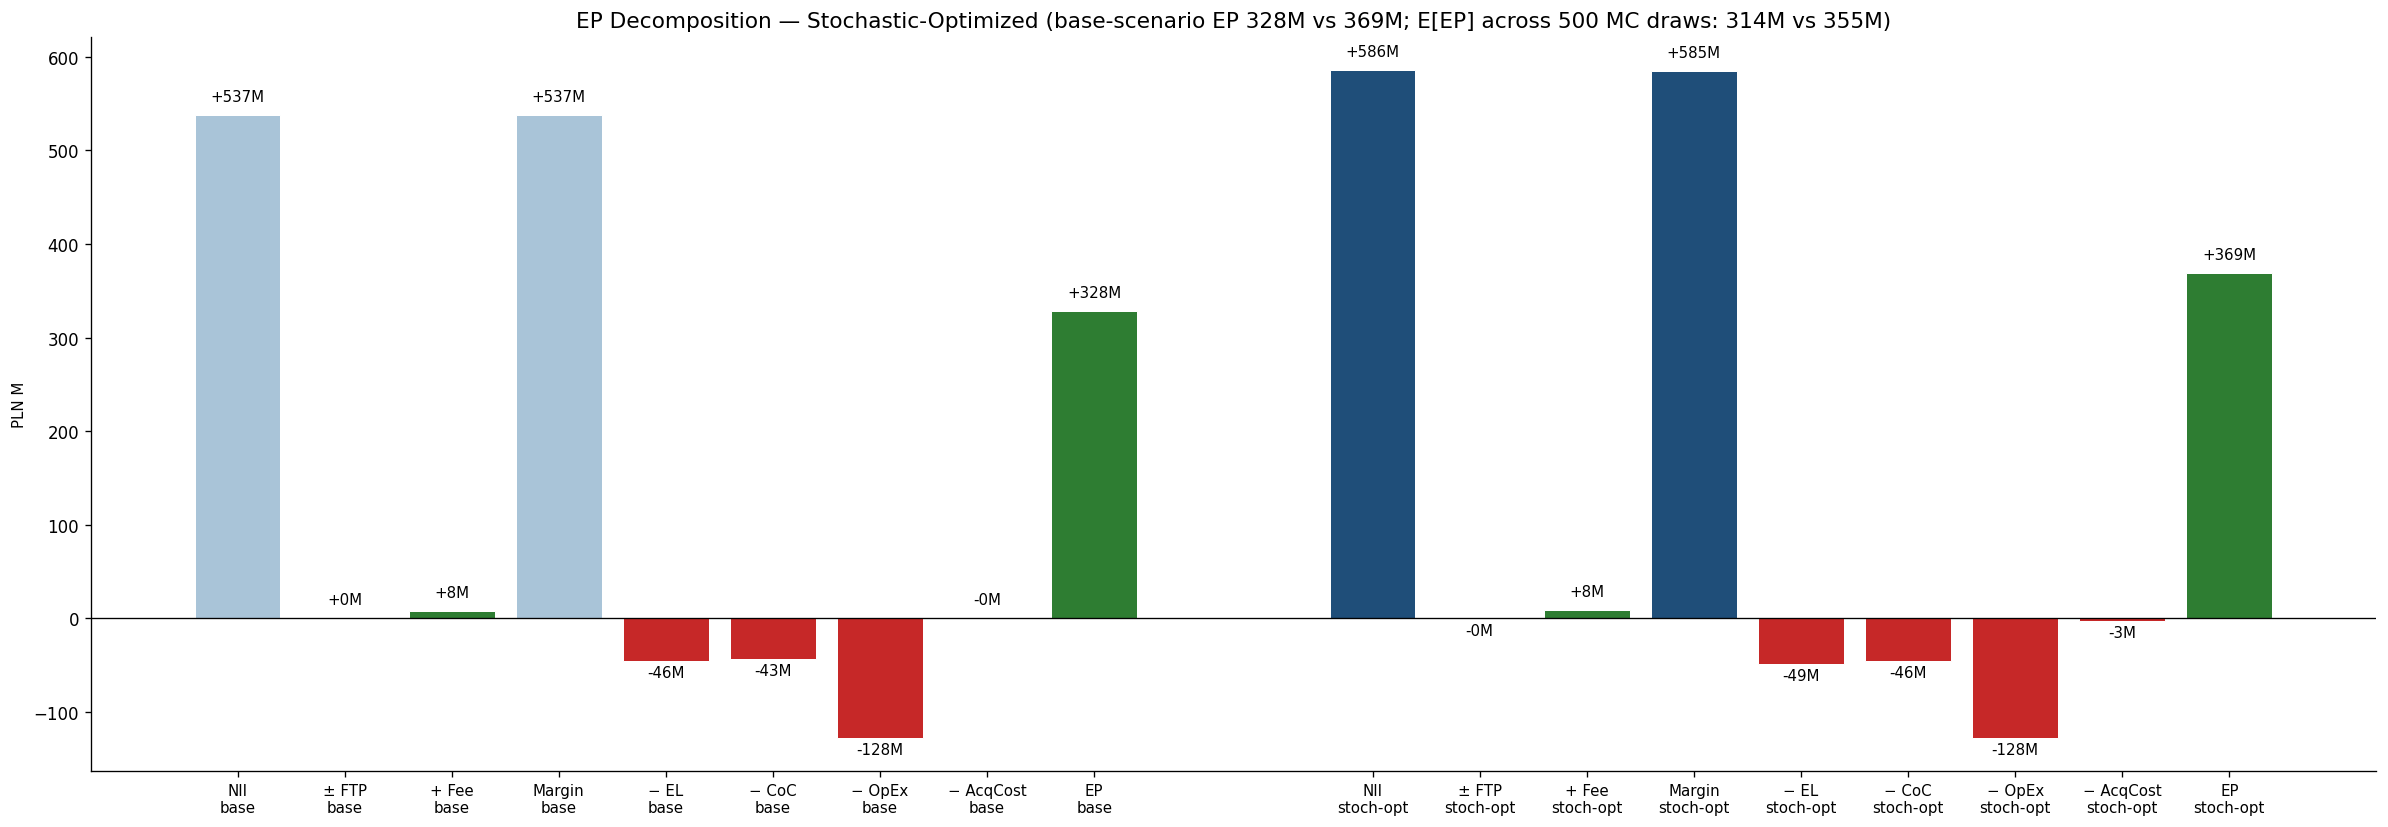

In [19]:
# ── EP Decomposition — Stochastic-Optimized (full-width: the essence of this
#    section — shown at the DETERMINISTIC base-scenario decomposition for the
#    same NII/FTP/Margin/Fee/EL/CoC/OpEx/AcqCost breakdown as Sections 4 and 9;
#    the title also states the Monte-Carlo E[EP] across all scenarios, which is
#    what the optimizer actually maximized ── the two won't match exactly
#    (MC sampling noise around the deterministic base case) ────────────────
comp_base_stoch = compute_ep_components(pm_stoch.base_prod_w, pm_stoch, mask_irs=not cfg.include_irs)
comp_opt_stoch  = compute_ep_components(stoch_result.weights_new, pm_stoch, mask_irs=not cfg.include_irs)

fig, ax = plt.subplots(figsize=(20, 7))
plot_ep_waterfall(ax, comp_base_stoch, comp_opt_stoch,
                   title=f"EP Decomposition — Stochastic-Optimized "
                         f"(base-scenario EP {comp_base_stoch['ep']/1e6:,.0f}M vs {comp_opt_stoch['ep']/1e6:,.0f}M; "
                         f"E[EP] across {stoch_result.n_scenarios} MC draws: "
                         f"{stoch_result.ep_mean_old/1e6:,.0f}M vs {stoch_result.ep_mean_new/1e6:,.0f}M)",
                   base_label="base", opt_label="stoch-opt")
plt.tight_layout()
plt.savefig(os.path.join(_ROOT, "bs_optimization", "output", "fig_stochastic_ep_waterfall.png"),
            dpi=150, bbox_inches="tight")
plt.show()


**Reading this chart:** each percentile (P5/P25/P50/P75/P95) is computed **independently** on the baseline and optimized EP distributions -- this shows how the *shape* of the distribution changes (e.g. does the worst-case tail improve?), not a scenario-by-scenario, apples-to-apples delta on the same underlying curve draw. Bars are labeled with their exact PLN M value.

Percentile,Baseline EP (M PLN),Optimized EP (M PLN),Δ
P5,290.3,324.6,+34.3
P25,303.6,342.5,+38.9
P50,313.5,354.4,+40.9
P75,324.0,367.8,+43.7
P95,339.1,384.2,+45.1


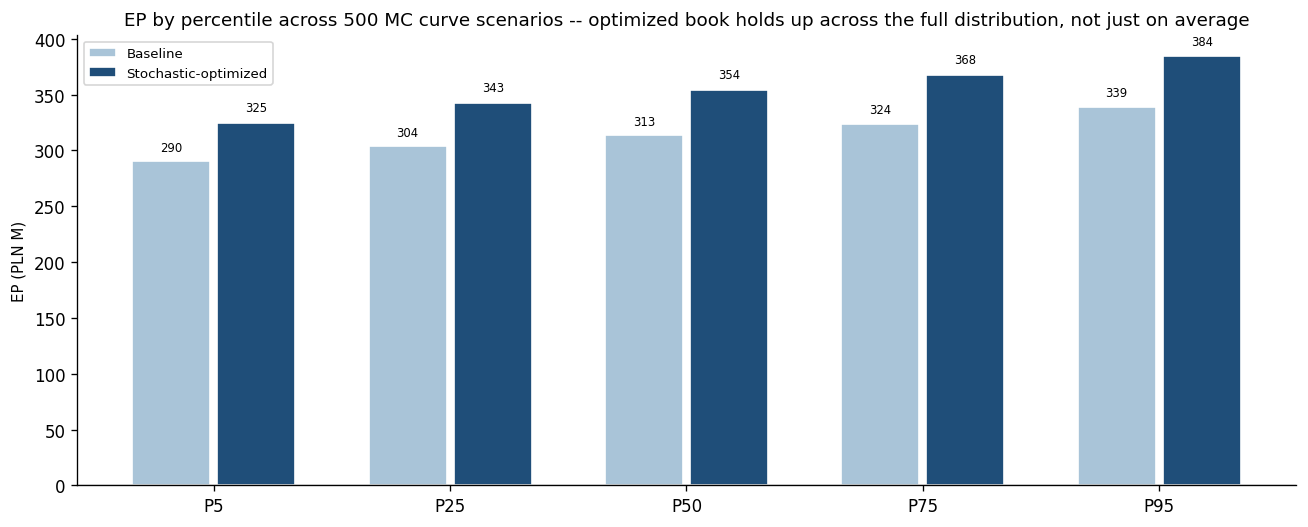

In [20]:
# ── Sample scenarios across the MC distribution -- not just E[EP]/CVaR, but
#    concrete "what does EP look like in a P5 / P25 / median / P75 / P95
#    scenario" examples, baseline vs optimized. Percentiles are taken
#    independently on each array (not the same underlying draw matched
#    across old/new), which is the right comparison for "how does the
#    SHAPE of the distribution change", not "scenario-by-scenario delta". ──
_pctiles = [5, 25, 50, 75, 95]
sample_rows = []
for p in _pctiles:
    ep_old_p = float(np.percentile(stoch_result.ep_scenarios_old, p))
    ep_new_p = float(np.percentile(stoch_result.ep_scenarios_new, p))
    sample_rows.append([f"P{p}", f"{ep_old_p/1e6:,.1f}", f"{ep_new_p/1e6:,.1f}",
                         f"{(ep_new_p-ep_old_p)/1e6:+,.1f}"])
sample_df = pd.DataFrame(sample_rows, columns=["Percentile", "Baseline EP (M PLN)",
                                                "Optimized EP (M PLN)", "Δ"])
display(style_table(sample_df, caption=f"EP across the {stoch_result.n_scenarios}-scenario "
                     f"Monte Carlo distribution -- baseline vs optimized at each percentile "
                     f"(P5/P95 = worst/best 5% of curve draws)"))

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(_pctiles))
old_vals = [float(np.percentile(stoch_result.ep_scenarios_old, p)) / 1e6 for p in _pctiles]
new_vals = [float(np.percentile(stoch_result.ep_scenarios_new, p)) / 1e6 for p in _pctiles]
ax.bar(x - 0.18, old_vals, width=0.33, color=C_OLD, label="Baseline", edgecolor="white")
ax.bar(x + 0.18, new_vals, width=0.33, color=C_NEW, label="Stochastic-optimized", edgecolor="white")
_label_bar(ax, x - 0.18, old_vals, fmt="{:,.0f}")
_label_bar(ax, x + 0.18, new_vals, fmt="{:,.0f}")
ax.axhline(0, color="black", linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f"P{p}" for p in _pctiles])
ax.set_ylabel("EP (PLN M)")
ax.set_title(f"EP by percentile across {stoch_result.n_scenarios} MC curve scenarios -- "
             f"optimized book holds up across the full distribution, not just on average")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(_ROOT, "bs_optimization", "output", "fig_stochastic_percentiles.png"),
            dpi=150, bbox_inches="tight")
plt.show()


**Reading this chart:** left panel is the risk-return frontier -- each point is one `λ` (risk-aversion) re-optimization, labeled with its expected EP; the red ✕ marks today's book for reference. Right panel overlays the full EP distribution (all Monte Carlo scenarios) for the baseline vs. the λ=1 optimized book, with each CVaR₉₅ (worst-tail EP) threshold labeled at its dashed line.

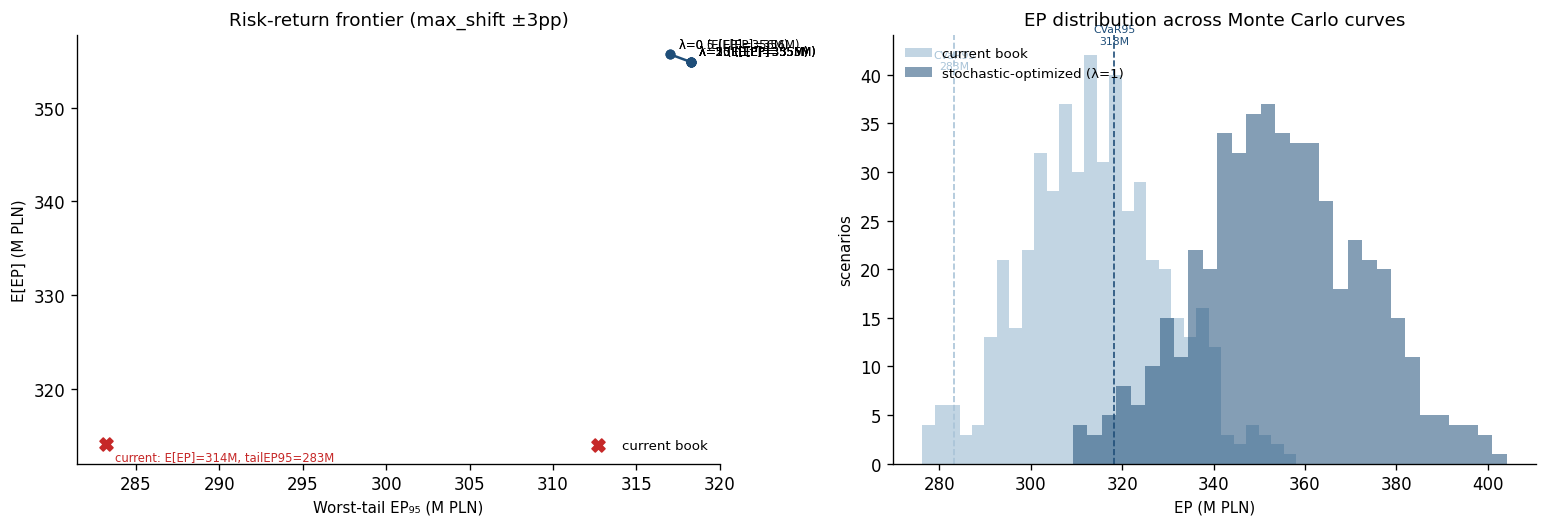


Frontier (max_shift ±3pp -- box constraint makes this a coarse, near-vertex-limited
frontier; re-run with mode='full' for a smoother theoretical frontier):
  lambda=   0.0   E[EP]=   355.69M   tailEP95=   317.04M
  lambda=   0.5   E[EP]=   355.69M   tailEP95=   317.04M
  lambda=   1.0   E[EP]=   354.89M   tailEP95=   318.26M
  lambda=   2.0   E[EP]=   354.89M   tailEP95=   318.26M
  lambda=   5.0   E[EP]=   354.89M   tailEP95=   318.26M
  lambda=  10.0   E[EP]=   354.89M   tailEP95=   318.26M
  lambda=  25.0   E[EP]=   354.89M   tailEP95=   318.26M
  lambda=  50.0   E[EP]=   354.89M   tailEP95=   318.26M


In [21]:
lambdas  = [0.0, 0.5, 1.0, 2.0, 5.0, 10.0, 25.0, 50.0]
frontier = sweep_risk_frontier(cfg, stoch_cfg, params, cr, C_scenarios, lp_blocks, lambdas)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
means = [r.ep_mean_new / 1e6 for r in frontier]
tails = [r.cvar_new    / 1e6 for r in frontier]
ax.plot(tails, means, "o-", color=C_ASSET, ms=5)
for lam, m, t in zip(lambdas, means, tails):
    ax.annotate(f"λ={lam:g} (E[EP]={m:,.0f}M)", (t, m), textcoords="offset points",
                xytext=(5, 4), fontsize=7)
ax.scatter([stoch_result.cvar_old / 1e6], [stoch_result.ep_mean_old / 1e6],
           color=C_NEG, s=60, marker="X", zorder=5, label="current book")
ax.annotate(f"current: E[EP]={stoch_result.ep_mean_old/1e6:,.0f}M, "
            f"tailEP95={stoch_result.cvar_old/1e6:,.0f}M",
            (stoch_result.cvar_old/1e6, stoch_result.ep_mean_old/1e6),
            textcoords="offset points", xytext=(5, -10), fontsize=7, color=C_NEG)
ax.set_xlabel("Worst-tail EP₉₅ (M PLN)")
ax.set_ylabel("E[EP] (M PLN)")
ax.set_title("Risk-return frontier (max_shift ±3pp)")
ax.legend(loc="lower right", frameon=False, fontsize=8)

ax = axes[1]
ax.hist(stoch_result.ep_scenarios_old / 1e6, bins=30, color=C_OLD, alpha=0.7,  label="current book")
ax.hist(stoch_result.ep_scenarios_new / 1e6, bins=30, color=C_NEW, alpha=0.55, label="stochastic-optimized (λ=1)")
ax.axvline(stoch_result.cvar_old / 1e6, color=C_OLD, ls="--", lw=1)
ax.axvline(stoch_result.cvar_new / 1e6, color=C_NEW, ls="--", lw=1)
_ylim_top = ax.get_ylim()[1]
ax.text(stoch_result.cvar_old/1e6, _ylim_top*0.92, f"CVaR95\n{stoch_result.cvar_old/1e6:,.0f}M",
        color=C_OLD, fontsize=6.5, ha="center")
ax.text(stoch_result.cvar_new/1e6, _ylim_top*0.98, f"CVaR95\n{stoch_result.cvar_new/1e6:,.0f}M",
        color=C_NEW, fontsize=6.5, ha="center")
ax.set_xlabel("EP (M PLN)")
ax.set_ylabel("scenarios")
ax.set_title("EP distribution across Monte Carlo curves")
ax.legend(loc="upper left", frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

print("\nFrontier (max_shift ±3pp -- box constraint makes this a coarse, near-vertex-limited")
print("frontier; re-run with mode='full' for a smoother theoretical frontier):")
for lam, r in zip(lambdas, frontier):
    print(f"  lambda={lam:6.1f}   E[EP]={r.ep_mean_new/1e6:9.2f}M   tailEP95={r.cvar_new/1e6:9.2f}M")

### Takeaways

- **Mean-reverting, not a driftless random walk.** Today's curve level (~5.06%) sits at roughly the 75th-90th percentile of the full 2005-2025 history -- a pure random walk centered on today's level would systematically underweight the historically-common possibility of reverting toward lower levels (44% of history was below 2%). The 24-month mean-reverting simulation above lets a meaningful share of paths (see the printed summary above the fan chart) genuinely reach back down toward those levels, rather than only by chance.
- The historically-calibrated Monte Carlo layer confirms the ±3pp `max_shift` box is
  tight enough that the risk-return frontier is coarse (few distinct LP vertices) —
  widening the shift bound would reveal a smoother tradeoff.
- Because the 2005-2025 calibration window includes the 2008 crisis and the 2021-2023
  hiking cycle, the simulated factor volatility is a **stress-inclusive** estimate, not
  "normal times" volatility — appropriate for a conservative robustness check, but a
  shorter recent window (e.g. last 5-7y) would give a lower, more "current-regime"
  volatility estimate. A natural follow-up sensitivity, not yet implemented.
- This directly answers the roadmap's Phase A question: *which product mix is most
  robust to curve uncertainty* — the λ>0 solutions trade a small amount of expected EP
  for a meaningfully better worst-tail outcome, exactly the profile ALCO would want
  once the base single-period optimizer (Section 4) already looks attractive but its
  robustness to real-world curve moves is untested.

---
## 6. Phase B — Monthly Balance-Sheet Rollforward

Where Phase A (Section 5) explores risk across many possible **rate curve paths** for a
single point in time, Phase B evolves the **balance sheet itself** forward in time,
month by month, under one deterministic curve path. It answers a different question:
*given today's book, what does the balance sheet, NII, and capital position look like
12 months from now if business continues on its current trajectory?*

### Methodology

Each month, the rollforward applies five steps in a fixed order:

1. **Age existing cohorts** — run off the t=0 book along its real per-cohort
   amortization schedule (`cohort_outstanding_m`, 12 months forward from report_date).
2. **NII accrual** — interest earned/paid this month on cohorts as they stood after
   aging (existing base cohorts use the exact monthly client rate from `rate_matrix`;
   this month's brand-new originations don't earn interest until the following month).
   Feeds `retained_earnings`.
3. **Growth engine** — for every product, replenish whatever amortized off back to its
   month-0 balance by default ("fixed % of total"), or track an explicit Excel growth
   index when one is supplied. Any shortfall spins off as one new synthetic cohort for
   that month.
4. **Balance-sheet plug** — closes the assets = liabilities + equity identity exactly,
   every month. Assets in excess of funding are deployed into bonds (50/50 fixed/float,
   priced off the real market curve); funding in excess of assets is raised via a new
   "other deposits" product at a flat 1% placeholder rate.
5. **Pricing** — this month's new synthetic and plug cohorts are priced with the same
   new-business formula the existing NII engine already uses for renewals:
   `clip(coeff_a × forward_rate + coeff_b, floor, cap)`.

Limits (LCR/NSFR/RWA/SOT) are **not enforced** in the rollforward — they're
whole-balance-sheet constraints, not per-product ones, and a rolled-forward book is
allowed to breach them. That's a deliberate design choice: a breach is a diagnostic
finding about the business forecast's risk profile, to be fixed by re-running the
Section 4 optimizer on the rolled-forward balance sheet in a later phase, not
something this module guards against.

**Caveats** — this is a mechanical rollforward, not itself an optimizer: no product
mix decisions are made (Approach B's "no FTP steering signal" design choice), the
implementation currently caps at a 12-month horizon (the per-cohort amortization
schedule doesn't extend further yet), synthetic/plug cohorts don't reprice after
origination, and IRS/equity are excluded from both the growth engine and the NII
rollup.


In [22]:
from rollforward import run_rollforward, history_to_totals_frame, state_to_frame, RollforwardConfig
from bs_vector import CurveTensors

curves = CurveTensors.load(os.path.join(_ROOT, "optimize_prep", "output", "curve_tensors.npz"))

rf_history = run_rollforward(params, cr, curves, RollforwardConfig(horizon_months=12))
rf_totals  = history_to_totals_frame(rf_history)

print(f"Balance-sheet identity check: max |assets - (liabilities+equity)| over 12 months = "
      f"{rf_totals['identity_gap'].abs().max():,.2f} PLN")
print()

disp_rf = rf_totals.copy()
disp_rf["Assets (M)"]             = disp_rf["assets"] / 1e6
disp_rf["Liabilities (M)"]        = disp_rf["liabilities"] / 1e6
disp_rf["Equity (M)"]             = disp_rf["equity"] / 1e6
disp_rf["Retained earnings (M)"]  = disp_rf["retained_earnings"] / 1e6
display(disp_rf[["Assets (M)", "Liabilities (M)", "Equity (M)", "Retained earnings (M)"]].round(1))


Balance-sheet identity check: max |assets - (liabilities+equity)| over 12 months = 0.00 PLN



,Assets (M),Liabilities (M),Equity (M),Retained earnings (M)
month,,,,
0,10420.0,9220.0,1200.0,0.0
1,10464.0,9220.0,1244.0,44.0
2,10508.1,9220.0,1288.1,88.1
3,10552.3,9220.0,1332.3,132.3
4,10596.7,9220.0,1376.7,176.7
5,10641.2,9220.0,1421.2,221.2
6,10685.8,9220.0,1465.8,265.8
7,10731.2,9220.0,1511.2,311.2
8,10775.9,9220.0,1555.9,355.9


**Reading this chart:** left panel tracks Assets/Liabilities/Equity month-by-month over the 12-month rollforward (month 0 = today's book); the final (month-12) value is annotated for each line -- the full monthly series is in the table above. Right panel is cumulative retained earnings (NII only, no OpEx/EL/CoC -- see the methodology note above for why).

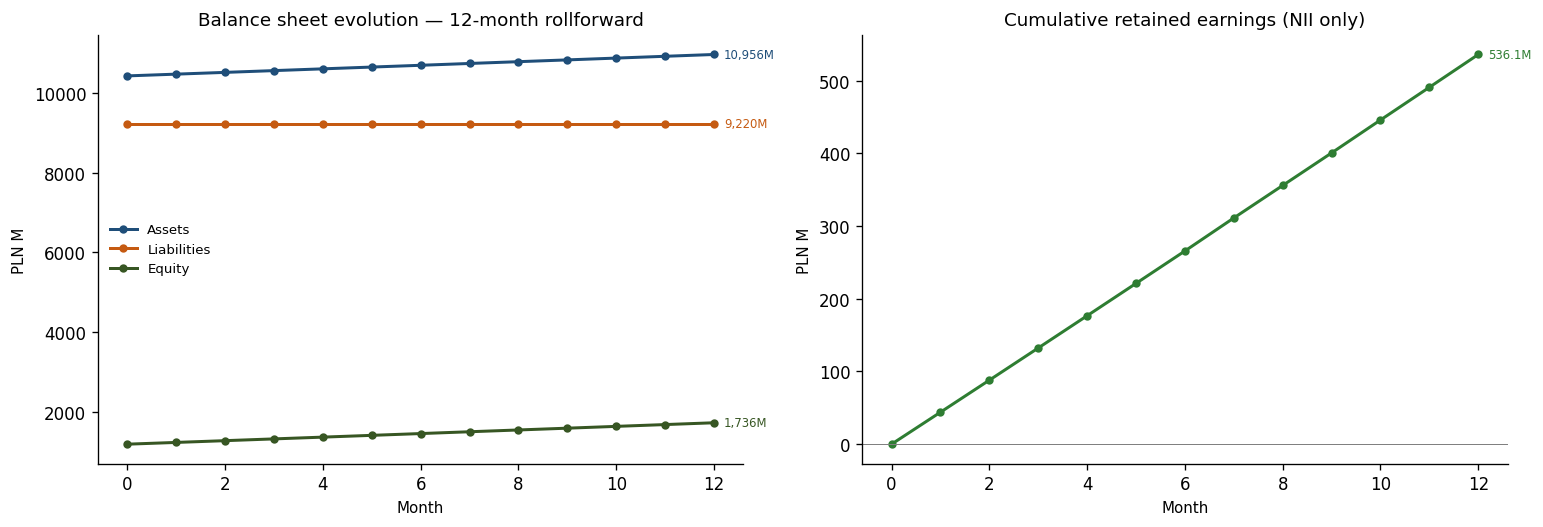

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(rf_totals.index, rf_totals["assets"] / 1e6,      color=C_ASSET,  lw=1.8, marker="o", ms=4, label="Assets")
ax.plot(rf_totals.index, rf_totals["liabilities"] / 1e6, color=C_LIAB,   lw=1.8, marker="o", ms=4, label="Liabilities")
ax.plot(rf_totals.index, rf_totals["equity"] / 1e6,      color=C_EQUITY, lw=1.8, marker="o", ms=4, label="Equity")
_month_end = rf_totals.index[-1]
for _col, _color in [("assets", C_ASSET), ("liabilities", C_LIAB), ("equity", C_EQUITY)]:
    _end_v = rf_totals[_col].iloc[-1] / 1e6
    ax.annotate(f"{_end_v:,.0f}M", (_month_end, _end_v), textcoords="offset points",
                xytext=(6, 0), fontsize=7, color=_color, va="center")
ax.set_xlabel("Month")
ax.set_ylabel("PLN M")
ax.set_title("Balance sheet evolution — 12-month rollforward")
ax.legend(loc="center left", frameon=False, fontsize=8)

ax = axes[1]
ax.plot(rf_totals.index, rf_totals["retained_earnings"] / 1e6, color=C_POS, lw=1.8, marker="o", ms=4)
_end_re = rf_totals["retained_earnings"].iloc[-1] / 1e6
ax.annotate(f"{_end_re:,.1f}M", (_month_end, _end_re), textcoords="offset points",
            xytext=(6, 0), fontsize=7, color=C_POS, va="center")
ax.axhline(0, color="grey", lw=0.6)
ax.set_xlabel("Month")
ax.set_ylabel("PLN M")
ax.set_title("Cumulative retained earnings (NII only)")

plt.tight_layout()
plt.savefig(os.path.join(_ROOT, "bs_optimization", "output", "fig_phaseb_rollforward.png"),
            dpi=150, bbox_inches="tight")
plt.show()


In [24]:
rf_final = state_to_frame(rf_history[-1])
new_cohorts = rf_final[rf_final["origin"] != "base"]
comp = (new_cohorts
        .groupby(["origin", "product_code", "bs_side"])["balance"]
        .sum().div(1e6).round(1).reset_index()
        .rename(columns={"balance": "balance_m"})
        .sort_values(["origin", "balance_m"], ascending=[True, False]))
print(f"New cohorts created over the 12-month horizon: {len(new_cohorts)}")
display(comp)


New cohorts created over the 12-month horizon: 80


,origin,product_code,bs_side,balance_m
0,plug,3000,A,287.4
1,plug,3100,A,287.4
5,synthetic,2100,A,403.3
3,synthetic,1100,A,370.0
10,synthetic,7900,L,366.7
8,synthetic,7060,L,312.5
2,synthetic,1000,A,249.7
9,synthetic,7900,A,183.3
7,synthetic,5000,L,145.9
4,synthetic,2000,A,93.1


### Takeaways

- With no explicit growth index, every product replenishes exactly back to its
  month-0 balance every month — the base book is flat by construction, and all of the
  year's asset growth comes from **retained earnings being redeployed** through the
  balance-sheet plug, not from organic product growth. Feed
  `RollforwardConfig.growth_targets` with an Excel-driven path per product to layer
  real growth/contraction assumptions on top of this baseline.
- The identity gap is exactly zero every month by construction — the plug always runs
  last in the monthly step order specifically to guarantee this. Running the plug
  before the P&L step reopens a gap equal to that month's NII every month (an equity
  bump with no offsetting asset/liability entry) — a bug caught and fixed during
  development, not a hypothetical.
- This directly answers the original Approach B goal — a concrete month-by-month
  trajectory for NII, balance sheet size, and capital — while deliberately dropping
  the "FTP steering signal" idea from the original design (see Section 7 below): the
  rollforward is mechanical, not optimizing, by design.


---
## 8. Does Maximizing EP Also Improve IRRBB Compliance? (Soft SOT Floors)

Section 4 already reports "0/7 breaches" for both baseline and EP-optimized —
but a breach *count* only tells pass/fail, not how much regulatory headroom is
left. Before introducing this section's soft-constraint mechanism, the table
below re-reads Section 4's own numbers (no new optimization run) to check the
actual **margin** to the floor.


In [25]:
# ── Does EP-optimization also improve (or erode) IRRBB headroom, at the
#    REAL configured floor? Reuses Section 4's result / sot_eve_base /
#    sot_nii_base -- no new optimization run, just re-reading numbers already
#    computed there. _breach_count() is Section 4's own helper. ────────────
_worst_eve_scen_base = min(sot_eve_base, key=sot_eve_base.get)
_worst_eve_scen_opt  = min(result.sot_eve, key=result.sot_eve.get)
_worst_nii_scen_base = min(sot_nii_base, key=sot_nii_base.get)
_worst_nii_scen_opt  = min(result.sot_nii, key=result.sot_nii.get)

ep_irrbb_rows = [
    ["Economic Profit (M PLN)", f"{result.ep_old/1e6:,.1f}", f"{result.ep_new/1e6:,.1f}",
     f"{(result.ep_new - result.ep_old)/1e6:+,.1f}"],
    ["Worst-case EVE SOT (% T1, scenario)",
     f"{sot_eve_base[_worst_eve_scen_base]:+.2f}% ({_worst_eve_scen_base})",
     f"{result.sot_eve[_worst_eve_scen_opt]:+.2f}% ({_worst_eve_scen_opt})",
     f"{result.sot_eve[_worst_eve_scen_opt] - sot_eve_base[_worst_eve_scen_base]:+.2f}"],
    ["Worst-case NII SOT (% T1, scenario)",
     f"{sot_nii_base[_worst_nii_scen_base]:+.2f}% ({_worst_nii_scen_base})",
     f"{result.sot_nii[_worst_nii_scen_opt]:+.2f}% ({_worst_nii_scen_opt})",
     f"{result.sot_nii[_worst_nii_scen_opt] - sot_nii_base[_worst_nii_scen_base]:+.2f}"],
    ["EVE breaches (out of 7, real floor)",
     f"{_breach_count(sot_eve_base, result.sot_eve_floor)}/7",
     f"{_breach_count(result.sot_eve, result.sot_eve_floor)}/7", ""],
    ["NII breaches (out of 7, real floor)",
     f"{_breach_count(sot_nii_base, result.sot_nii_floor)}/7",
     f"{_breach_count(result.sot_nii, result.sot_nii_floor)}/7", ""],
]
ep_irrbb_df = pd.DataFrame(ep_irrbb_rows, columns=["Measure", "Baseline", "EP-optimized (Sec. 4)", "Δ"])
display(style_table(ep_irrbb_df, caption=f"EP vs. IRRBB headroom at the real floor "
                     f"(EVE {result.sot_eve_floor:+.1f}% T1, NII {result.sot_nii_floor:+.1f}% T1)"))

Measure,Baseline,EP-optimized (Sec. 4),Δ
Economic Profit (M PLN),328.3,369.7,+41.4
"Worst-case EVE SOT (% T1, scenario)",-6.96% (par_up),-13.50% (par_up),-6.54
"Worst-case NII SOT (% T1, scenario)",-4.13% (par_dn),-4.48% (par_dn),-0.35
"EVE breaches (out of 7, real floor)",0/7,0/7,
"NII breaches (out of 7, real floor)",0/7,0/7,


**Answer: no — EP-optimization does not improve IRRBB robustness here, even
though it stays fully compliant.** Breach counts are unchanged (0/7 both), but
the *margin* to the floor collapses on the worst-case scenario for each measure
-- see the table above: EVE under `par_up` moves from its baseline value to
almost exactly this book's EVE floor, and NII under `par_dn` ends up a hair
from the NII floor. This is ordinary LP behavior: maximizing a linear
objective subject to linear constraints drives the solution toward whichever
constraint boundaries still have spare capacity worth monetizing -- "0
breaches" means "still on the compliant side of the line," often *right at*
that line, not "unchanged risk profile."

That's exactly the situation this section's soft-constraint mechanism is for
-- not because *this* book breaches today, but because a hard-constraint
optimizer only ever reports pass/fail, never how close the solution is to
failing. A slightly tighter floor, or a slightly different book, could tip the
same optimizer past the line with no warning. **You don't need to set a
nonzero breach weight for this book** -- Section 4's hard-constraint run above
is already the right answer here -- this is optional tooling for when a future
book/floor combination makes EP and compliance genuinely conflict.

`bs_optimizer.py` supports a **soft** alternative to the hard EVE/NII floor:
`OptimizationConfig.eve_breach_weight` / `nii_breach_weight` (both `0.0` by
default = hard, unchanged from Section 4). When a weight is set `>0`, that
floor becomes a weighted cost in the objective instead of a wall:

$$\text{penalty} = \text{weight} \times \frac{T_1}{100} \times \frac{1}{n_{scen}} \times \sum_s \max(0,\; \text{floor} - SOT_s)$$

i.e. PLN cost per average percentage-point-of-T1 of breach severity across the
7 EBA scenarios -- the same unit convention already used by
`hedge_optimizer.py`'s `penalty_weight`. **Both floors stay real EBA
regulatory limits** -- this is a deliberate modeling choice to explore the
trade-off curve, not a claim that a breach is compliant.

**Demo setup below:** since even the worst-case scenarios above don't actually
breach *this* book's real floor, there's no live conflict to sweep yet. To
make the soft-constraint mechanism concretely visible anyway, the cells below
tighten the **NII floor to −2% T1** (buffer removed) for illustration only --
tight enough that even the unmodified baseline book breaches it in 2
scenarios, which is exactly the situation the soft mechanism is for: a
hard-constraint optimizer facing an already-breached floor is **infeasible**
and falls back to doing nothing; a weighted objective can still find a real
improvement.


In [26]:
# ── Weight sweep: same book, same ±3pp box, floor tightened to -2% T1 for demo ──
from bs_optimizer import OptimizationConfig, optimize_nii

DEMO_NII_FLOOR = -2.0
weights = [0.0, 0.5, 1, 2, 5, 10, 20, 50, 100]

sweep_rows = []
for w in weights:
    cfg_w = OptimizationConfig(
        mode=cfg.mode, max_shift=cfg.max_shift,
        sot_eve_floor=cfg.sot_eve_floor, sot_eve_buffer=cfg.sot_eve_buffer,
        sot_nii_floor=DEMO_NII_FLOOR, sot_nii_buffer=0.0,
        include_irs=cfg.include_irs, min_lcr=cfg.min_lcr, min_nsfr=cfg.min_nsfr,
        min_t1_rwa=cfg.min_t1_rwa, fixed_products=cfg.fixed_products,
        eve_breach_weight=w, nii_breach_weight=w,
    )
    r_w = optimize_nii(cfg_w, params, cr)
    n_eve = sum(1 for v in r_w.sot_eve.values() if v < r_w.sot_eve_floor - 1e-6)
    n_nii = sum(1 for v in r_w.sot_nii.values() if v < r_w.sot_nii_floor - 1e-6)
    sweep_rows.append({
        "weight": w, "ep_m": r_w.ep_new / 1e6,
        "n_eve_breach": n_eve, "n_nii_breach": n_nii,
        "worst_nii_pct": min(r_w.sot_nii.values()),
        "mode": "HARD (infeasible->baseline fallback)" if w == 0 else "soft",
    })

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df.round(2))


  IR derivatives: hedged (IRS in metrics)  |  notional 840M  |  2 cohort(s) — always pinned
  Bias corrections loaded: 7 scenarios, 535 cohorts
    EVE correction at baseline: par_up=+0.2M  par_dn=-0.2M  steep=-0.1M  flat=+0.1M  sr_up=+0.2M  sr_dn=-0.2M  own=-0.1M
  No FTP cache found — run build_ftp_rates.py; EP margin will equal client-rate NII until then
  Substitution constraints: 6 pairs active
  Price-volume elasticity: 15 products active — LP warm-start + QP polish
  Building LP coefficients...
  LP (HiGHS) failed (The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)), falling back to SLSQP...


  SLSQP fallback: success=False  msg=Inequality constraints incompatible
  IR derivatives: hedged (IRS in metrics)  |  notional 840M  |  2 cohort(s) — always pinned
  Bias corrections loaded: 7 scenarios, 535 cohorts
    EVE correction at baseline: par_up=+0.2M  par_dn=-0.2M  steep=-0.1M  flat=+0.1M  sr_up=+0.2M  sr_dn=-0.2M  own=-0.1M
  No FTP cache found — run build_ftp_rates.py; EP margin will equal client-rate NII until then
  Soft floors: EVE=weight 0.5   NII=weight 0.5   (EP still dominates unless breach severity is large)
  Substitution constraints: 6 pairs active
  Price-volume elasticity: 15 products active — LP warm-start + QP polish
  Building LP coefficients...
  Soft-breach mode: 14 weighted slack variable(s) added
  LP (HiGHS): optimal  nit=15  elapsed=0.1s
  QP polish (price-volume elasticity)...


  Soft-breach severity: 2 constraint(s) violated
    nii_par_dn: violation = 2.648663
    nii_flat: violation = 0.094691
  IR derivatives: hedged (IRS in metrics)  |  notional 840M  |  2 cohort(s) — always pinned
  Bias corrections loaded: 7 scenarios, 535 cohorts
    EVE correction at baseline: par_up=+0.2M  par_dn=-0.2M  steep=-0.1M  flat=+0.1M  sr_up=+0.2M  sr_dn=-0.2M  own=-0.1M
  No FTP cache found — run build_ftp_rates.py; EP margin will equal client-rate NII until then
  Soft floors: EVE=weight 1.0   NII=weight 1.0   (EP still dominates unless breach severity is large)
  Substitution constraints: 6 pairs active
  Price-volume elasticity: 15 products active — LP warm-start + QP polish
  Building LP coefficients...
  Soft-breach mode: 14 weighted slack variable(s) added
  LP (HiGHS): optimal  nit=15  elapsed=0.1s
  QP polish (price-volume elasticity)...


  Soft-breach severity: 2 constraint(s) violated
    nii_par_dn: violation = 2.648663
    nii_flat: violation = 0.094691
  IR derivatives: hedged (IRS in metrics)  |  notional 840M  |  2 cohort(s) — always pinned
  Bias corrections loaded: 7 scenarios, 535 cohorts
    EVE correction at baseline: par_up=+0.2M  par_dn=-0.2M  steep=-0.1M  flat=+0.1M  sr_up=+0.2M  sr_dn=-0.2M  own=-0.1M
  No FTP cache found — run build_ftp_rates.py; EP margin will equal client-rate NII until then
  Soft floors: EVE=weight 2.0   NII=weight 2.0   (EP still dominates unless breach severity is large)
  Substitution constraints: 6 pairs active
  Price-volume elasticity: 15 products active — LP warm-start + QP polish
  Building LP coefficients...
  Soft-breach mode: 14 weighted slack variable(s) added
  LP (HiGHS): optimal  nit=16  elapsed=0.1s
  QP polish (price-volume elasticity)...


  Soft-breach severity: 2 constraint(s) violated
    nii_par_dn: violation = 2.648663
    nii_flat: violation = 0.094691
  IR derivatives: hedged (IRS in metrics)  |  notional 840M  |  2 cohort(s) — always pinned
  Bias corrections loaded: 7 scenarios, 535 cohorts
    EVE correction at baseline: par_up=+0.2M  par_dn=-0.2M  steep=-0.1M  flat=+0.1M  sr_up=+0.2M  sr_dn=-0.2M  own=-0.1M
  No FTP cache found — run build_ftp_rates.py; EP margin will equal client-rate NII until then
  Soft floors: EVE=weight 5.0   NII=weight 5.0   (EP still dominates unless breach severity is large)
  Substitution constraints: 6 pairs active
  Price-volume elasticity: 15 products active — LP warm-start + QP polish
  Building LP coefficients...
  Soft-breach mode: 14 weighted slack variable(s) added
  LP (HiGHS): optimal  nit=18  elapsed=0.1s
  QP polish (price-volume elasticity)...


...

  SLSQP QP: success=True  msg=Optimization terminated successfully
  Soft-breach severity: 1 constraint(s) violated
    nii_par_dn: violation = 2.175493
  IR derivatives: hedged (IRS in metrics)  |  notional 840M  |  2 cohort(s) — always pinned
  Bias corrections loaded: 7 scenarios, 535 cohorts
    EVE correction at baseline: par_up=+0.2M  par_dn=-0.2M  steep=-0.1M  flat=+0.1M  sr_up=+0.2M  sr_dn=-0.2M  own=-0.1M
  No FTP cache found — run build_ftp_rates.py; EP margin will equal client-rate NII until then
  Soft floors: EVE=weight 20.0   NII=weight 20.0   (EP still dominates unless breach severity is large)
  Substitution constraints: 6 pairs active
  Price-volume elasticity: 15 products active — LP warm-start + QP polish
  Building LP coefficients...
  Soft-breach mode: 14 weighted slack variable(s) added
  LP (HiGHS): optimal  nit=13  elapsed=0.1s
  QP polish (price-volume elasticity)...


  Soft-breach severity: 1 constraint(s) violated
    nii_par_dn: violation = 1.550372
  IR derivatives: hedged (IRS in metrics)  |  notional 840M  |  2 cohort(s) — always pinned
  Bias corrections loaded: 7 scenarios, 535 cohorts
    EVE correction at baseline: par_up=+0.2M  par_dn=-0.2M  steep=-0.1M  flat=+0.1M  sr_up=+0.2M  sr_dn=-0.2M  own=-0.1M
  No FTP cache found — run build_ftp_rates.py; EP margin will equal client-rate NII until then
  Soft floors: EVE=weight 50.0   NII=weight 50.0   (EP still dominates unless breach severity is large)
  Substitution constraints: 6 pairs active
  Price-volume elasticity: 15 products active — LP warm-start + QP polish
  Building LP coefficients...
  Soft-breach mode: 14 weighted slack variable(s) added
  LP (HiGHS): optimal  nit=11  elapsed=0.1s
  QP polish (price-volume elasticity)...


  Soft-breach severity: 1 constraint(s) violated
    nii_par_dn: violation = 0.744999
  IR derivatives: hedged (IRS in metrics)  |  notional 840M  |  2 cohort(s) — always pinned
  Bias corrections loaded: 7 scenarios, 535 cohorts
    EVE correction at baseline: par_up=+0.2M  par_dn=-0.2M  steep=-0.1M  flat=+0.1M  sr_up=+0.2M  sr_dn=-0.2M  own=-0.1M
  No FTP cache found — run build_ftp_rates.py; EP margin will equal client-rate NII until then
  Soft floors: EVE=weight 100.0   NII=weight 100.0   (EP still dominates unless breach severity is large)
  Substitution constraints: 6 pairs active
  Price-volume elasticity: 15 products active — LP warm-start + QP polish
  Building LP coefficients...
  Soft-breach mode: 14 weighted slack variable(s) added
  LP (HiGHS): optimal  nit=14  elapsed=0.1s
  QP polish (price-volume elasticity)...


  Soft-breach severity: 1 constraint(s) violated
    nii_par_dn: violation = 0.744999


,weight,ep_m,n_eve_breach,n_nii_breach,worst_nii_pct,mode
0,0.0,394.57,0,1,-4.30,HARD (infeasible->baseline fallback)
1,0.5,410.44,0,2,-4.61,soft
2,1.0,410.44,0,2,-4.61,soft
3,2.0,410.44,0,2,-4.61,soft
4,5.0,408.75,0,2,-4.13,soft
5,10.0,407.84,0,1,-4.15,soft
6,20.0,391.52,0,1,-3.53,soft
7,50.0,343.00,0,1,-2.74,soft
8,100.0,343.00,0,1,-2.74,soft


**Reading this chart:** the blue line (left axis) is optimized EP as the NII-floor-breach penalty weight increases (log scale); the red dashed line (right axis) is how many of the 7 EBA scenarios still breach the tightened −2% T1 demo floor at that weight. Both series are labeled with their exact values at each weight tested.

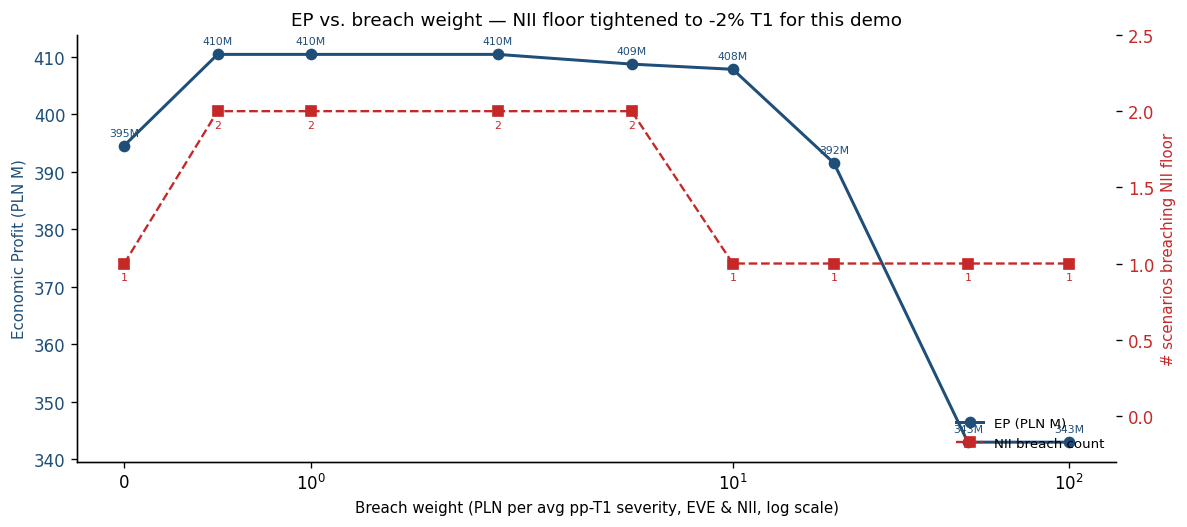

In [27]:
# ── Chart: EP and breach count vs. breach weight ──────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(sweep_df["weight"], sweep_df["ep_m"], "o-", color=C_ASSET, ms=6, lw=1.8, label="EP (PLN M)")
for _w, _ep in zip(sweep_df["weight"], sweep_df["ep_m"]):
    ax1.annotate(f"{_ep:,.0f}M", (_w, _ep), textcoords="offset points", xytext=(0, 6),
                 fontsize=6.5, ha="center", color=C_ASSET)
ax1.set_xscale("symlog")
ax1.set_xlabel("Breach weight (PLN per avg pp-T1 severity, EVE & NII, log scale)")
ax1.set_ylabel("Economic Profit (PLN M)", color=C_ASSET)
ax1.tick_params(axis="y", labelcolor=C_ASSET)

ax2 = ax1.twinx()
ax2.plot(sweep_df["weight"], sweep_df["n_nii_breach"], "s--", color=C_NEG, ms=6, lw=1.4, label="NII breach count")
for _w, _n in zip(sweep_df["weight"], sweep_df["n_nii_breach"]):
    ax2.annotate(f"{int(_n)}", (_w, _n), textcoords="offset points", xytext=(0, -10),
                 fontsize=6.5, ha="center", color=C_NEG)
ax2.set_ylabel("# scenarios breaching NII floor", color=C_NEG)
ax2.tick_params(axis="y", labelcolor=C_NEG)
ax2.set_ylim(-0.3, max(sweep_df["n_nii_breach"].max(), 1) + 0.5)

ax1.set_title(f"EP vs. breach weight — NII floor tightened to {DEMO_NII_FLOOR:.0f}% T1 for this demo")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right", frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(_ROOT, "bs_optimization", "output", "fig_breach_weight_sweep.png"),
            dpi=150, bbox_inches="tight")
plt.show()


### Takeaways

- At `weight=0` (hard) the LP is **infeasible** against the tightened −2% NII
  floor within the ±3pp box — bs_optimizer.py falls back toward the baseline
  book, leaving EP essentially unimproved from Section 2's baseline.
- Any positive weight unlocks the LP again: the optimizer can move away from
  the baseline and improve EP substantially, paying only for the *marginal*
  severity of the (largely pre-existing) breach rather than being blocked
  outright by it.
- There is no universal correct weight — like `hedge_optimizer.py`'s
  `penalty_weight` (tuned empirically to ~50 for the swap ladder), the right
  value here depends on how much EP the desk is willing to trade for how much
  breach severity, and should be swept per book/appetite the same way this
  section does.
- This is the mechanism behind both "Approach 1b" (BS-only + weighted
  breaches) and Section 9 below (BS + new IRS overlay, jointly).
- Reminder: at this book's real floor, EP-optimization already consumes
  almost all of the EVE/NII SOT headroom on the worst-case scenarios (see
  the table near the top of this section) without technically breaching --
  the weight sweep above is what you'd reach for if a tighter floor (or a
  different book) turned that narrow margin into an actual breach.


---
## 9. Joint Balance-Sheet + IRS Hedge Optimization

Sections 4–8 always keep interest-rate swaps **pinned** at their current
notional — the optimizer only ever reallocates the banking book around a
fixed hedge. `joint_optimizer.py` removes that restriction: it solves **one**
LP over BOTH the BS product weights AND a NEW swap-ladder overlay (the same
300 synthetic buckets `hedge_optimizer.py` sizes) at the same time, sharing
Section 8's soft EVE/NII objective.

**Scope, explicitly:**
- The **existing** ~840M IRS book stays pinned (same as every other section
  here) — the new ladder notional is layered **on top** of it, not a
  replacement.
- The ladder is priced against the SAME 7 official EBA scenarios as the rest
  of this notebook (via `CurveTensors`, not `hedge_optimizer.py`'s separate
  165-curve robustness bank — that's a different question about basis risk
  across alternative starting curves, not today's official SOT test).
- NSFR / LCR / RWA are modeled on the banking-book side only; the swap
  overlay's balance-sheet-neutral notional isn't assumed to move those
  ratios (same scope `hedge_optimizer.py` already has).
- No price-volume elasticity QP polish here — pure LP, for tractability.

**Fixed-rate realism (2026-07-09):** every ladder bucket's fixed rate now includes
`swap_ladder.IRS_MARGIN_BPS` (25bps, applied against whichever side of the trade the
bank is on) instead of pricing at the raw curve mid — a real swap desk's spread works
against the price-taker, not for them. Buckets originated more than
`seasoned_elapsed_months` (12) ago get a separate, smaller
`seasoned_notional_cap` (1e9 PLN) on top of the usual per-bucket/aggregate caps:
a bucket's fixed rate is fit to the curve AT ITS ORIGINATION DATE, so a 2+ year-old
bucket can carry a large windfall from real historical rate drift that has nothing to
do with today's hedging economics — this keeps the optimizer from concentrating the
whole overlay into a handful of such buckets.

**Objective change (2026-07-09):** the new swap overlay's own carry is no longer part of
what's being maximized — `x_swap` only enters the objective through its effect on the
EVE/NII constraint rows (helping satisfy the floor, or reducing soft-breach severity).
Before this change the swap overlay was a second, largely unconstrained profit source and
the optimizer bought up to the notional cap chasing carry regardless of whether it was
actually needed for compliance. The two runs below show both outcomes: at this notebook's
own floors (Section 4's), BS reallocation alone is already sufficient and the optimizer
correctly chooses **zero** new swap notional; a second run with an artificially tightened
NII floor (reusing Section 8's demo device) shows the swap overlay stepping in — and
stopping — exactly at the point where it's no longer reducing breach severity.


In [28]:
# ── Run 1: joint optimizer at Section 4's own floors -- BS alone is sufficient here,
#    so the new swap overlay should come out at (or near) zero notional ─────────────
from joint_optimizer import optimize_bs_and_ladder

joint_cfg = OptimizationConfig(
    mode=cfg.mode, max_shift=cfg.max_shift,
    sot_eve_floor=cfg.sot_eve_floor, sot_eve_buffer=cfg.sot_eve_buffer,
    sot_nii_floor=cfg.sot_nii_floor, sot_nii_buffer=cfg.sot_nii_buffer,
    include_irs=cfg.include_irs, min_lcr=cfg.min_lcr, min_nsfr=cfg.min_nsfr,
    min_t1_rwa=cfg.min_t1_rwa, fixed_products=cfg.fixed_products,
    eve_breach_weight=20.0, nii_breach_weight=20.0,
)
joint_result = optimize_bs_and_ladder(joint_cfg, params, cr)
_status = "SUCCESS" if joint_result.success else "FAILED"
print(f"Joint BS+IRS optimization [Run 1] -- {_status}  |  {joint_result.message}  |  "
      f"elapsed={joint_result.elapsed_s:.2f}s")
print(f"  BS EP: {joint_result.ep_bs_new/1e6:,.1f}M  |  new swap carry (informational): "
      f"{joint_result.ep_carry_swap/1e6:+,.1f}M/yr  |  TOTAL EP: {joint_result.ep_total_new/1e6:,.1f}M")

display(style_changes(changes_table(joint_result.product_changes, params.total_assets),
                      caption="Run 1 -- BS product weight changes"))
_swap1 = swap_table(joint_result.swap_notional)
if len(_swap1) > 0:
    display(style_table(_swap1, caption="Run 1 -- active new swap overlay buckets",
                         fmt={"Notional (M PLN)": "{:,.1f}"}))
else:
    print("Run 1 -- new swap overlay: 0 active buckets (0.0M PLN)")


display(style_sot(sot_table(joint_result.sot_eve, joint_result.sot_eve_floor, "EVE SOT (% T1)"),
                   caption="Run 1 -- EVE SOT (this notebook's real configured floor)"))
display(style_sot(sot_table(joint_result.sot_nii, joint_result.sot_nii_floor, "NII SOT (% T1)"),
                   caption="Run 1 -- NII SOT (this notebook's real configured floor)"))


  Existing IR derivatives (pinned): 840M notional -- new swap overlay is layered ON TOP of this, not a replacement
  No FTP cache found -- run build_ftp_rates.py; EP margin will equal client-rate NII until then
  Building BS-side LP coefficients...
  Pricing swap ladder (5 tenors) against bs_optimizer's 7 EBA scenarios...


  Solving joint LP: 21 BS weights + 300 swap buckets + 14 soft-breach slack(s)...
Joint BS+IRS optimization [Run 1] -- SUCCESS  |  Optimization terminated successfully. (HiGHS Status 7: Optimal)  |  elapsed=3.83s
  BS EP: 410.9M  |  new swap carry (informational): -2.7M/yr  |  TOTAL EP: 408.2M


Code,Side,Change (M PLN),Δ (M),Δ pp
6300,L,400 → 700,▲ +300.0,▲ +3.00
6000,L,"3,400 → 3,700",▲ +300.0,▲ +3.00
2000,A,600 → 900,▲ +300.0,▲ +3.00
1100,A,"2,800 → 3,100",▲ +300.0,▲ +3.00
1000,A,"1,000 → 1,300",▲ +300.0,▲ +3.00
2100,A,"1,800 → 2,100",▲ +300.0,▲ +3.00
3500,A,200 → 0,▼ -200.0,▼ -2.00
3200,A,200 → 0,▼ -200.0,▼ -2.00
7900,A,200 → 0,▼ -200.0,▼ -2.00
3100,A,"1,200 → 900",▼ -300.0,▼ -3.00


Bucket,Notional (M PLN)
LADDER_6Y_E069,283.6


Scenario,EVE SOT (% T1),Floor (% T1),Status
flat,+1.55%,-13.5%,OK
own,+3.97%,-13.5%,OK
par_dn,+10.18%,-13.5%,OK
par_up,-9.32%,-13.5%,OK
sr_dn,+2.62%,-13.5%,OK
sr_up,-2.57%,-13.5%,OK
steep,-2.45%,-13.5%,OK


Scenario,NII SOT (% T1),Floor (% T1),Status
flat,-2.21%,-4.5%,OK
own,-1.91%,-4.5%,OK
par_dn,-4.50%,-4.5%,OK
par_up,+4.14%,-4.5%,OK
sr_dn,-0.12%,-4.5%,OK
sr_up,-0.26%,-4.5%,OK
steep,+2.23%,-4.5%,OK


In [29]:
# ── Run 0: same book/floors as Run 1, but include_irs=False ── IRS is still
#    PINNED in the balance sheet (always is, see _resolve_irs); this only
#    changes whether its EVE/NII contribution counts toward the regulatory
#    SOT constraint rows the optimizer must satisfy (unhedged view) ─────────
joint_cfg_no_irs = OptimizationConfig(
    mode=cfg.mode, max_shift=cfg.max_shift,
    sot_eve_floor=cfg.sot_eve_floor, sot_eve_buffer=cfg.sot_eve_buffer,
    sot_nii_floor=cfg.sot_nii_floor, sot_nii_buffer=cfg.sot_nii_buffer,
    include_irs=False, min_lcr=cfg.min_lcr, min_nsfr=cfg.min_nsfr,
    min_t1_rwa=cfg.min_t1_rwa, fixed_products=cfg.fixed_products,
    eve_breach_weight=20.0, nii_breach_weight=20.0,
)
joint_result_no_irs = optimize_bs_and_ladder(joint_cfg_no_irs, params, cr)
_status = "SUCCESS" if joint_result_no_irs.success else "FAILED"
print(f"Joint BS+IRS optimization [Run 0, unhedged/without IRS] -- {_status}  |  "
      f"{joint_result_no_irs.message}  |  elapsed={joint_result_no_irs.elapsed_s:.2f}s")
print(f"  BS EP: {joint_result_no_irs.ep_bs_new/1e6:,.1f}M  |  new swap carry (informational): "
      f"{joint_result_no_irs.ep_carry_swap/1e6:+,.1f}M/yr  |  TOTAL EP: {joint_result_no_irs.ep_total_new/1e6:,.1f}M")

display(style_changes(changes_table(joint_result_no_irs.product_changes, params.total_assets),
                      caption="Run 0 (unhedged) -- BS product weight changes"))


  Existing IR derivatives (pinned): 840M notional -- new swap overlay is layered ON TOP of this, not a replacement
  No FTP cache found -- run build_ftp_rates.py; EP margin will equal client-rate NII until then
  Building BS-side LP coefficients...
  Pricing swap ladder (5 tenors) against bs_optimizer's 7 EBA scenarios...


  Solving joint LP: 21 BS weights + 300 swap buckets + 14 soft-breach slack(s)...
Joint BS+IRS optimization [Run 0, unhedged/without IRS] -- SUCCESS  |  Optimization terminated successfully. (HiGHS Status 7: Optimal)  |  elapsed=3.57s
  BS EP: 410.9M  |  new swap carry (informational): -10.1M/yr  |  TOTAL EP: 400.9M


Code,Side,Change (M PLN),Δ (M),Δ pp
6300,L,400 → 700,▲ +300.0,▲ +3.00
6000,L,"3,400 → 3,700",▲ +300.0,▲ +3.00
2000,A,600 → 900,▲ +300.0,▲ +3.00
1100,A,"2,800 → 3,100",▲ +300.0,▲ +3.00
1000,A,"1,000 → 1,300",▲ +300.0,▲ +3.00
2100,A,"1,800 → 2,100",▲ +300.0,▲ +3.00
3500,A,200 → 0,▼ -200.0,▼ -2.00
3200,A,200 → 0,▼ -200.0,▼ -2.00
7900,A,200 → 0,▼ -200.0,▼ -2.00
3100,A,"1,200 → 900",▼ -300.0,▼ -3.00


NOTE: the hedged and unhedged BS product mix came out IDENTICAL for this book/config -- not a bug. The regulatory SOT constraint basis differs (IRS counted or not), but the EP-maximizing mix already satisfies BOTH versions comfortably here, so the LP lands on the same optimum either way; only the reported SOT compliance differs (see the EVE/NII SOT tables above). A tighter floor could easily make these diverge.


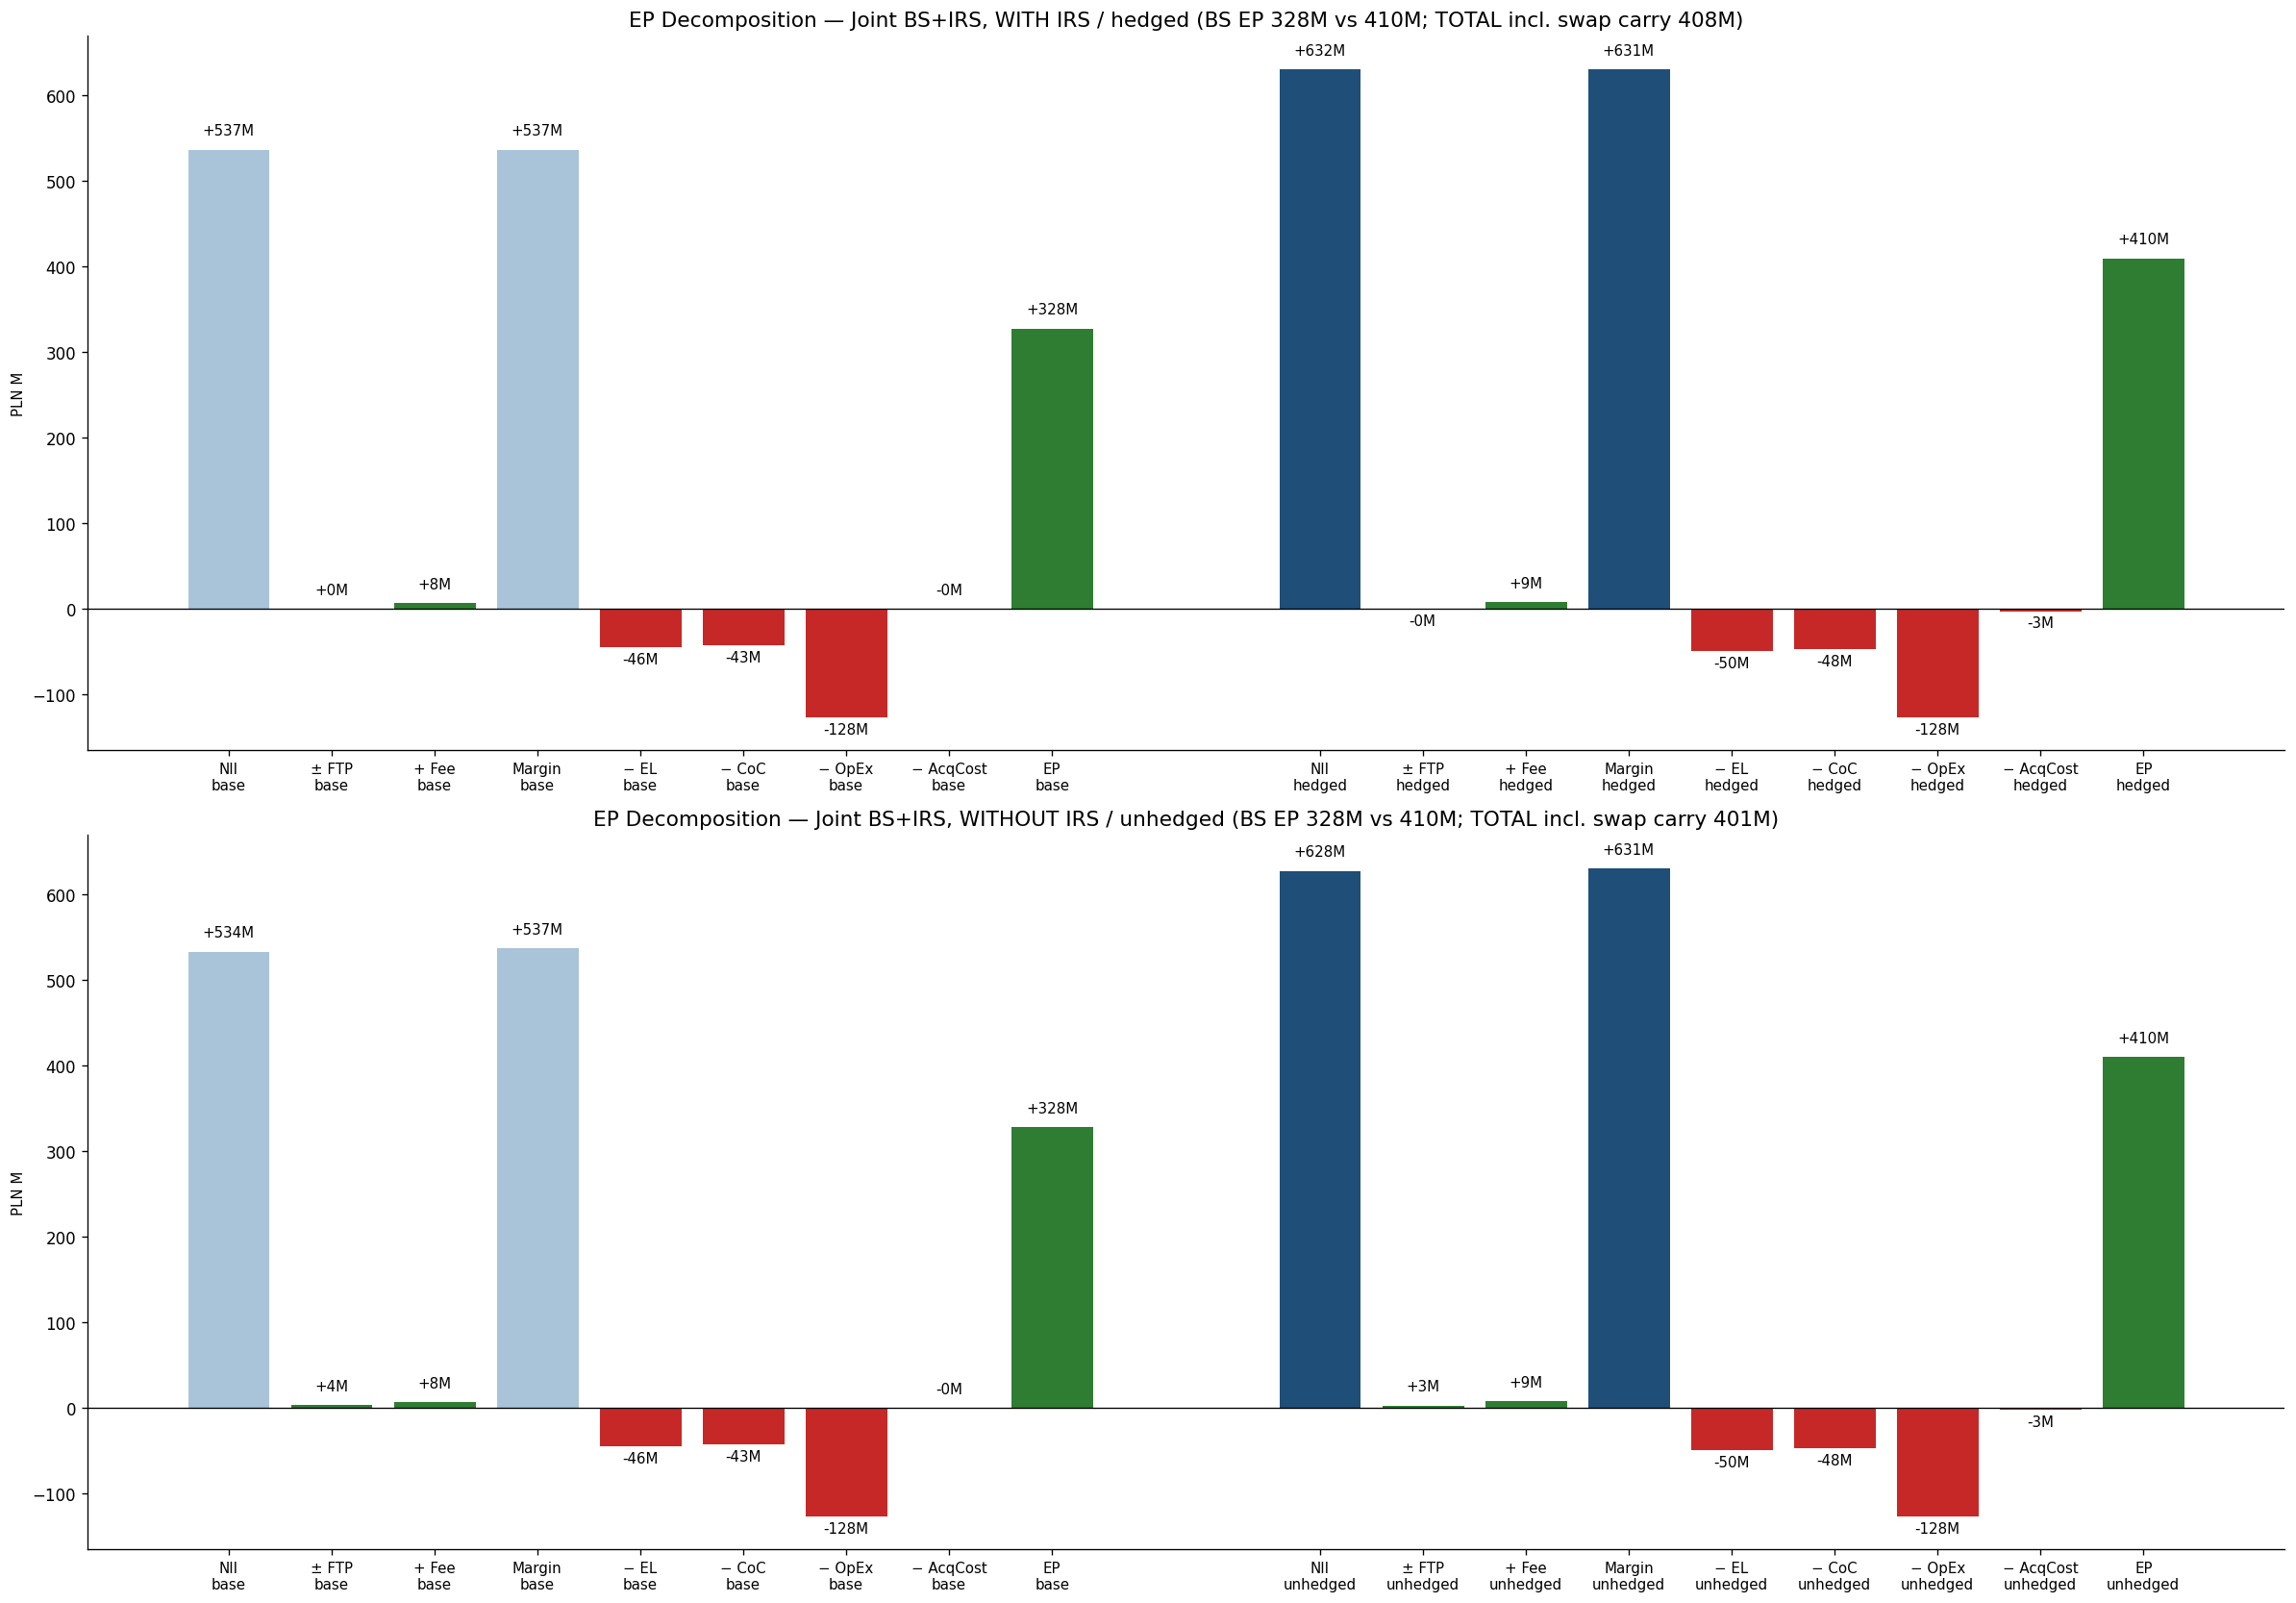

In [30]:
# ── EP Decomposition — Joint BS+IRS, WITH vs WITHOUT IRS (full-width: the essence
#    of this section — does hedging the SOT view change what the optimizer
#    actually does to the balance sheet, and what it's worth?) ─────────────
from bs_optimizer import _ProductMap

pm_joint = _ProductMap(params)
comp_base_joint    = compute_ep_components(pm_joint.base_prod_w, pm_joint, mask_irs=False)
comp_base_no_irs   = compute_ep_components(pm_joint.base_prod_w, pm_joint, mask_irs=True)
comp_with_irs      = compute_ep_components(joint_result.weights_bs_new, pm_joint, mask_irs=False)
comp_no_irs        = compute_ep_components(joint_result_no_irs.weights_bs_new, pm_joint, mask_irs=True)

_weights_identical = np.allclose(joint_result.weights_bs_new, joint_result_no_irs.weights_bs_new)
if _weights_identical:
    print("NOTE: the hedged and unhedged BS product mix came out IDENTICAL for this "
          "book/config -- not a bug. The regulatory SOT constraint basis differs "
          "(IRS counted or not), but the EP-maximizing mix already satisfies BOTH "
          "versions comfortably here, so the LP lands on the same optimum either "
          "way; only the reported SOT compliance differs (see the EVE/NII SOT "
          "tables above). A tighter floor could easily make these diverge.")

fig, axes = plt.subplots(2, 1, figsize=(20, 14))

plot_ep_waterfall(axes[0], comp_base_joint, comp_with_irs,
                   title=f"EP Decomposition — Joint BS+IRS, WITH IRS / hedged "
                         f"(BS EP {comp_base_joint['ep']/1e6:,.0f}M vs {comp_with_irs['ep']/1e6:,.0f}M; "
                         f"TOTAL incl. swap carry {joint_result.ep_total_new/1e6:,.0f}M)",
                   base_label="base", opt_label="hedged")

plot_ep_waterfall(axes[1], comp_base_no_irs, comp_no_irs,
                   title=f"EP Decomposition — Joint BS+IRS, WITHOUT IRS / unhedged "
                         f"(BS EP {comp_base_joint['ep']/1e6:,.0f}M vs {comp_no_irs['ep']/1e6:,.0f}M; "
                         f"TOTAL incl. swap carry {joint_result_no_irs.ep_total_new/1e6:,.0f}M)",
                   base_label="base", opt_label="unhedged")

plt.tight_layout()
plt.savefig(os.path.join(_ROOT, "bs_optimization", "output", "fig_joint_ep_waterfall.png"),
            dpi=150, bbox_inches="tight")
plt.show()


In [31]:
# ── Run 2: same book, NII floor artificially tightened to -2% T1 (as in
#    Section 8) so BS reallocation alone genuinely cannot satisfy it -- the
#    swap overlay is now the only remaining lever, used ONLY to reduce
#    breach severity, not for its own carry ─────────────────────────────────
real_nii_floor = cfg.sot_nii_floor - cfg.sot_nii_buffer
print("=" * 78)
print(f"NOTE: NII floor below is DELIBERATELY TIGHTENED to {DEMO_NII_FLOOR:+.1f}% T1 for "
      f"THIS RUN ONLY (reusing Section 8's demo device).")
print(f"      This notebook's REAL configured NII floor is {real_nii_floor:+.1f}% T1 -- "
      f"the numbers below are NOT a regulatory breach of the actual book.")
print("=" * 78)
joint_cfg_tight = OptimizationConfig(
    mode=cfg.mode, max_shift=cfg.max_shift,
    sot_eve_floor=cfg.sot_eve_floor, sot_eve_buffer=cfg.sot_eve_buffer,
    sot_nii_floor=DEMO_NII_FLOOR, sot_nii_buffer=0.0,
    include_irs=cfg.include_irs, min_lcr=cfg.min_lcr, min_nsfr=cfg.min_nsfr,
    min_t1_rwa=cfg.min_t1_rwa, fixed_products=cfg.fixed_products,
    eve_breach_weight=20.0, nii_breach_weight=20.0,
)
joint_result_tight = optimize_bs_and_ladder(joint_cfg_tight, params, cr)
_status = "SUCCESS" if joint_result_tight.success else "FAILED"
print(f"Joint BS+IRS optimization [Run 2, demo floor] -- {_status}  |  {joint_result_tight.message}  |  "
      f"elapsed={joint_result_tight.elapsed_s:.2f}s")
print(f"  BS EP: {joint_result_tight.ep_bs_new/1e6:,.1f}M  |  new swap carry (informational): "
      f"{joint_result_tight.ep_carry_swap/1e6:+,.1f}M/yr  |  TOTAL EP: {joint_result_tight.ep_total_new/1e6:,.1f}M")

display(style_changes(changes_table(joint_result_tight.product_changes, params.total_assets),
                      caption="Run 2 -- BS product weight changes"))

display(style_sot(sot_table(joint_result_tight.sot_eve, joint_result_tight.sot_eve_floor, "EVE SOT (% T1)"),
                   caption="Run 2 -- EVE SOT (this notebook's real configured floor, UNCHANGED in this run)"))
display(style_sot(sot_table(joint_result_tight.sot_nii, joint_result_tight.sot_nii_floor, "NII SOT (% T1)"),
                   caption=f"Run 2 -- NII SOT (DEMO floor {joint_result_tight.sot_nii_floor:+.1f}% T1 -- "
                           f"NOT the real {real_nii_floor:+.1f}% T1 floor, see note above)"))



NOTE: NII floor below is DELIBERATELY TIGHTENED to -2.0% T1 for THIS RUN ONLY (reusing Section 8's demo device).
      This notebook's REAL configured NII floor is -4.5% T1 -- the numbers below are NOT a regulatory breach of the actual book.
  Existing IR derivatives (pinned): 840M notional -- new swap overlay is layered ON TOP of this, not a replacement
  No FTP cache found -- run build_ftp_rates.py; EP margin will equal client-rate NII until then
  Building BS-side LP coefficients...
  Pricing swap ladder (5 tenors) against bs_optimizer's 7 EBA scenarios...


  Solving joint LP: 21 BS weights + 300 swap buckets + 14 soft-breach slack(s)...
Joint BS+IRS optimization [Run 2, demo floor] -- SUCCESS  |  Optimization terminated successfully. (HiGHS Status 7: Optimal)  |  elapsed=3.76s
  BS EP: 408.5M  |  new swap carry (informational): +15.4M/yr  |  TOTAL EP: 423.9M


Code,Side,Change (M PLN),Δ (M),Δ pp
6000,L,"3,400 → 3,700",▲ +300.0,▲ +3.00
1000,A,"1,000 → 1,300",▲ +300.0,▲ +3.00
2000,A,600 → 900,▲ +300.0,▲ +3.00
1100,A,"2,800 → 3,100",▲ +300.0,▲ +3.00
6300,L,400 → 700,▲ +300.0,▲ +3.00
2100,A,"1,800 → 2,100",▲ +300.0,▲ +3.00
7900,A,200 → 240,▲ +40.1,▲ +0.40
3200,A,200 → 0,▼ -200.0,▼ -2.00
3500,A,200 → 0,▼ -200.0,▼ -2.00
3000,A,"1,400 → 1,160",▼ -240.1,▼ -2.40


Scenario,EVE SOT (% T1),Floor (% T1),Status
flat,+2.57%,-13.5%,OK
own,+5.69%,-13.5%,OK
par_dn,+14.52%,-13.5%,OK
par_up,-13.50%,-13.5%,OK
sr_dn,+3.43%,-13.5%,OK
sr_up,-3.36%,-13.5%,OK
steep,-3.92%,-13.5%,OK


Scenario,NII SOT (% T1),Floor (% T1),Status
flat,-2.00%,-2.0%,OK
own,-0.91%,-2.0%,OK
par_dn,-2.00%,-2.0%,OK
par_up,+1.62%,-2.0%,OK
sr_dn,+0.70%,-2.0%,OK
sr_up,-1.08%,-2.0%,OK
steep,+1.72%,-2.0%,OK


### What should actually be traded

Everything above answers "how much EVE/NII SOT breach does the optimizer avoid, and at
what EP cost" -- useful for calibrating the breach weight, but not directly actionable.
The cell below turns Run 2's chosen swap notional into a concrete deal list: one row per
active bucket, in the exact schema `ir_derivatives/input/irs_input.xlsx` expects (deal
dates, fixed rate, conventions, curve names), ready to hand to a trading desk or feed
back into the booking pipeline. This is the direct replacement for
`optimal_hedge_swap_input.xlsx`, whose old contents (a single ~982M swap) predated this
session's fixes and no longer reflect what the (now-corrected) optimizer actually
recommends.


In [32]:
from hedge_export import build_hedge_deals, save_hedge_deals

hedge_deals = build_hedge_deals(joint_result_tight.swap_notional, joint_result_tight.ladder,
                                 joint_result_tight.swap_direction)
if len(hedge_deals) > 0:
    display(style_table(
        hedge_deals[["swap_id", "pay_fixed", "notional", "start_date", "maturity_date", "fixed_rate"]],
        caption="Optimal hedge -- deal list (Run 2)",
        fmt={"notional": "{:,.0f}", "fixed_rate": "{:.4%}"},
    ))
    hedge_deals_path = save_hedge_deals(hedge_deals)
    print(f"Full deal list (all booking columns) written to: {hedge_deals_path}")
else:
    print("Run 2 chose zero new swap notional -- no deals to export.")


swap_id,pay_fixed,notional,start_date,maturity_date,fixed_rate
IRS_HEDGE_OPT_LADDER_5Y_E038,0,"999,066,646",2023-04-30 00:00:00,2028-04-30 00:00:00,5.5039%
IRS_HEDGE_OPT_LADDER_3Y_E008,0,"482,220,832",2025-10-30 00:00:00,2028-10-30 00:00:00,3.7510%
IRS_HEDGE_OPT_LADDER_6Y_E056,0,"933,354",2021-10-30 00:00:00,2027-10-30 00:00:00,2.5108%


Optimal hedge deal list saved: C:\Users\dzimi\Documents\data_engineering\data_projects\git_hub_projects\bank_project\bs_optimization\output\optimal_hedge_swap_input.xlsx  (3 swap(s), total notional 1,482.2M)
Full deal list (all booking columns) written to: C:\Users\dzimi\Documents\data_engineering\data_projects\git_hub_projects\bank_project\bs_optimization\output\optimal_hedge_swap_input.xlsx


**Reading this chart:** left/middle panels compare NII/EVE SOT between the BS-only optimizer (Section 4) and the joint BS+IRS optimizer (Run 1) -- both scored **hedged**, at this notebook's own configured floor (dashed red line). Right panel shows the new swap-overlay notional by bucket **for Run 2** (the artificially-tightened-floor demo run), not Run 1 -- Run 1's overlay is zero by design (see the takeaways below).

Measure,BS-only (Sec. 4),"Joint BS+IRS, Run 1",Δ
Economic Profit (M PLN),369.7,408.2,+38.5
of which BS EP,369.7,410.9,
of which new swap carry (informational),-,-2.7,
New swap notional (M PLN),-,283.6,


Down scenario,ΔNII BS-only (M PLN),ΔNII Joint BS+IRS (M PLN),ΔEVE BS-only (M PLN),ΔEVE Joint BS+IRS (M PLN)
par_dn,-53.8,-54.0,+176.4,+122.1
sr_dn,+21.1,-1.5,+44.9,+31.5


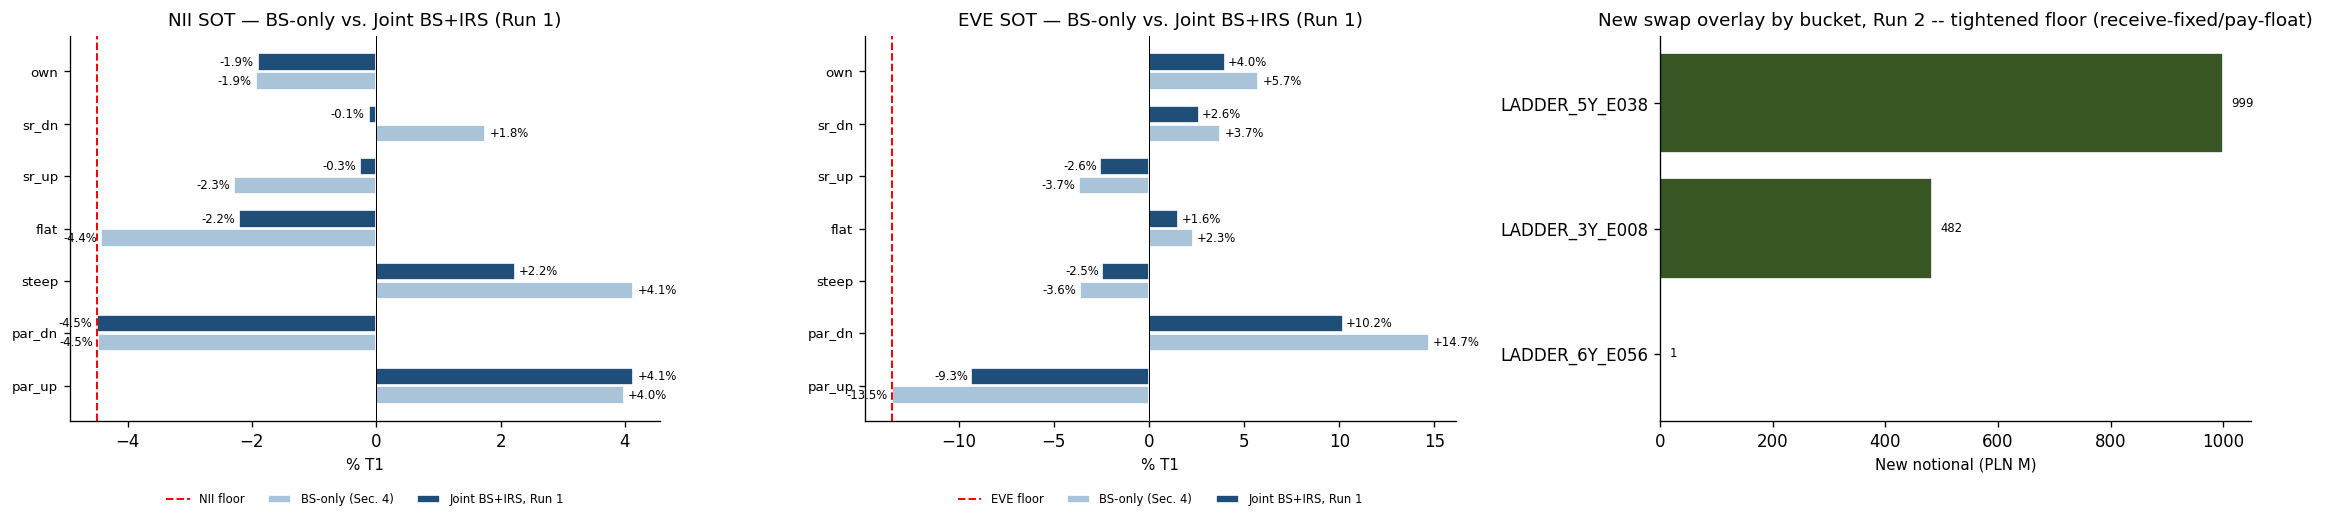

Bucket,Notional (M PLN)
LADDER_5Y_E038,999.1
LADDER_3Y_E008,482.2
LADDER_6Y_E056,0.9


In [33]:
# ── Comparison: BS-only (Section 4) vs. Joint BS+IRS (Run 1) ─────────────────
comp_rows = [
    ["Economic Profit (M PLN)", f"{result.ep_new/1e6:,.1f}", f"{joint_result.ep_total_new/1e6:,.1f}",
     f"{(joint_result.ep_total_new - result.ep_new)/1e6:+,.1f}"],
    ["  of which BS EP",        f"{result.ep_new/1e6:,.1f}", f"{joint_result.ep_bs_new/1e6:,.1f}", ""],
    ["  of which new swap carry (informational)", "-", f"{joint_result.ep_carry_swap/1e6:+,.1f}", ""],
    ["New swap notional (M PLN)", "-", f"{sum(joint_result.swap_notional.values())/1e6:,.1f}", ""],
]
comp_df = pd.DataFrame(comp_rows, columns=["Measure", "BS-only (Sec. 4)", "Joint BS+IRS, Run 1", "Δ"])
display(style_table(comp_df, caption="Economic profit -- BS-only vs. Joint BS+IRS (Run 1)"))

# ── Down-shock scenarios in absolute PLN -- does the hedge actually help NII
#    in a rates-down world, and at what cost (if any) to EVE? (both figures
#    already include the swap ladder's contribution via sot_nii/sot_eve on
#    joint_result -- just converting the existing % T1 figures back to PLN
#    via T1, no new computation, so this is guaranteed consistent with the
#    SOT chart below) ──────────────────────────────────────────────────────
_down_scens = [s for s in ["par_dn", "sr_dn"] if s in shocked_scens]
down_rows = []
for s in _down_scens:
    nii_bs_pct = result.sot_nii.get(s, 0.0)
    nii_jt_pct = joint_result.sot_nii.get(s, 0.0)
    eve_bs_pct = result.sot_eve.get(s, 0.0)
    eve_jt_pct = joint_result.sot_eve.get(s, 0.0)
    down_rows.append([
        s,
        f"{nii_bs_pct/100*t1/1e6:+,.1f}", f"{nii_jt_pct/100*t1/1e6:+,.1f}",
        f"{eve_bs_pct/100*t1/1e6:+,.1f}", f"{eve_jt_pct/100*t1/1e6:+,.1f}",
    ])
down_df = pd.DataFrame(down_rows, columns=[
    "Down scenario", "ΔNII BS-only (M PLN)", "ΔNII Joint BS+IRS (M PLN)",
    "ΔEVE BS-only (M PLN)", "ΔEVE Joint BS+IRS (M PLN)"])
display(style_table(down_df, caption="Down-shock scenarios in absolute PLN -- "
                     "does the swap overlay help NII without hurting EVE too much?"))

fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))

# --- SOT comparison: BS-only vs Joint Run 1 ---
ax = axes[0]
scen_labels = [str(s) for s in shocked_scens]
nii_bs_vals    = [result.sot_nii.get(str(s), 0.0) for s in shocked_scens]
nii_joint_vals = [joint_result.sot_nii.get(str(s), 0.0) for s in shocked_scens]
y = np.arange(len(scen_labels))
ax.barh(y - 0.18, nii_bs_vals,    height=0.33, color=C_OLD, label="BS-only (Sec. 4)", edgecolor="white")
ax.barh(y + 0.18, nii_joint_vals, height=0.33, color=C_NEW, label="Joint BS+IRS, Run 1", edgecolor="white")
_label_barh(ax, y - 0.18, nii_bs_vals)
_label_barh(ax, y + 0.18, nii_joint_vals)
ax.axvline(joint_result.sot_nii_floor, color="red", linewidth=1.2, linestyle="--", label="NII floor")
ax.axvline(0, color="black", linewidth=0.6)
ax.set_yticks(y)
ax.set_yticklabels(scen_labels, fontsize=8)
ax.set_xlabel("% T1")
ax.set_title("NII SOT — BS-only vs. Joint BS+IRS (Run 1)")
ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False)

# --- EVE SOT comparison: BS-only vs Joint Run 1 -- shown right next to NII SOT
#     so the trade-off (does hedging NII cost EVE?) is visible at a glance ----
ax = axes[1]
eve_bs_vals    = [result.sot_eve.get(str(s), 0.0) for s in shocked_scens]
eve_joint_vals = [joint_result.sot_eve.get(str(s), 0.0) for s in shocked_scens]
ax.barh(y - 0.18, eve_bs_vals,    height=0.33, color=C_OLD, label="BS-only (Sec. 4)", edgecolor="white")
ax.barh(y + 0.18, eve_joint_vals, height=0.33, color=C_NEW, label="Joint BS+IRS, Run 1", edgecolor="white")
_label_barh(ax, y - 0.18, eve_bs_vals)
_label_barh(ax, y + 0.18, eve_joint_vals)
ax.axvline(joint_result.sot_eve_floor, color="red", linewidth=1.2, linestyle="--", label="EVE floor")
ax.axvline(0, color="black", linewidth=0.6)
ax.set_yticks(y)
ax.set_yticklabels(scen_labels, fontsize=8)
ax.set_xlabel("% T1")
ax.set_title("EVE SOT — BS-only vs. Joint BS+IRS (Run 1)")
ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False)

# --- New swap overlay by bucket, Run 2 (tightened floor -- the run that
#     actually has nonzero notional; Run 1 is zero by design, see takeaways) ---
ax = axes[2]
swap_items = [(b, n / 1e6) for b, n in joint_result_tight.swap_notional.items() if n > 1.0]
direction_lbl = "pay-fixed/receive-float" if joint_result_tight.swap_direction > 0 else "receive-fixed/pay-float"
if swap_items:
    swap_df = pd.DataFrame(swap_items, columns=["Bucket", "Notional (M PLN)"]).sort_values("Notional (M PLN)", ascending=True)
    ax.barh(swap_df["Bucket"], swap_df["Notional (M PLN)"], color=C_EQUITY, edgecolor="white")
    _label_barh(ax, np.arange(len(swap_df)), swap_df["Notional (M PLN)"].tolist(), fmt="{:,.0f}")
    ax.set_xlabel("New notional (PLN M)")
else:
    swap_df = pd.DataFrame(columns=["Bucket", "Notional (M PLN)"])
    ax.text(0.5, 0.5, "No active buckets", ha="center", va="center", transform=ax.transAxes, fontsize=10)
ax.set_title(f"New swap overlay by bucket, Run 2 -- tightened floor ({direction_lbl})")

plt.tight_layout()
plt.savefig(os.path.join(_ROOT, "bs_optimization", "output", "fig_joint_bs_irs.png"),
            dpi=150, bbox_inches="tight")
plt.show()

if len(swap_df) > 0:
    display(style_table(swap_df.sort_values("Notional (M PLN)", ascending=False).reset_index(drop=True),
                         caption="Run 2 -- active new swap overlay buckets",
                         fmt={"Notional (M PLN)": "{:,.1f}"}))


### Takeaways

- **Run 1 (this notebook's own floors):** the swap overlay comes out at zero new notional —
  BS reallocation alone already clears both floors, so there's nothing left for a hedge to
  usefully do, and (with carry removed from the objective) nothing rewards adding one anyway.
  This is the objective-change fix working as intended: before it, this exact run bought up to
  the full notional cap purely chasing carry.
- **Run 2 (floor tightened to demonstrate genuine need):** the swap overlay activates, but
  stops right at the point where NII SOT reaches the floor rather than continuing to grow —
  once a constraint row is satisfied, further notional is objective-neutral, so the LP has no
  reason to keep adding it.
- The overlay is still capped (`notional_cap` per bucket, `total_notional_cap` in aggregate,
  `seasoned_notional_cap` for buckets originated >12 months ago) for the conditioning/
  boundedness and historical-windfall reasons documented above and in `hedge_optimizer.py` —
  those caps matter far less now that carry no longer drives demand for notional, but they're
  still the right thing to check first if a future run looks like it's leaning on one or two
  buckets unrealistically hard.
- This module intentionally does not re-derive the *existing* ~840M IRS book — a natural next
  step would be letting that existing notional vary too, not just the new overlay, but that
  requires representing today's real swap contracts inside the same synthetic-bucket universe
  `swap_ladder.py` uses, which they currently aren't.


---
## 9B. Stochastic Joint BS + IRS Hedge Optimization

Section 9 above jointly optimizes BS weights and a new swap-ladder overlay, but only against the 7 official EBA scenarios, with EP maximization softened by Section 8's breach-severity penalty. Section 5 optimizes BS weights alone against the SAME 500 mean-reverting Monte Carlo scenarios used throughout this notebook, via a CVaR objective -- but has no swap lever. This section combines both: jointly choose BS weights AND new swap notional to maximize E[EP] - λ·CVaR₉₅ over the same 500 MC scenarios, directly targeting the risk Section 5 already found (baseline NII breaches 64% of realistic 24-month scenarios; BS-only stochastic-optimization alone still leaves 26% exposed).

**Why the swap's carry enters this objective, unlike Section 9's:** Section 9's objective is pure BS EP, with the swap only affecting the regulatory pass/fail rows (its own carry deliberately excluded, so it isn't chased as free profit). Here, CVaR needs to see every instrument's real scenario-varying payoff to value risk reduction at all -- a swap with zero objective weight could never reduce tail risk. Consequence: the notional caps (`notional_cap`, `total_notional_cap`, `seasoned_notional_cap`) are a **required hard backstop** here, not optional -- without them a swap with an apparently favorable mean/variance profile (given this codebase's first-order approximations) would get bought to the cap.

The regulatory EVE/NII SOT floor stays pinned to the 7 official EBA scenarios (hard constraint), exactly like every other optimizer in this notebook -- the Monte Carlo layer feeds the objective only.


In [34]:
# ── Stochastic Joint BS+IRS optimization: same 500 MC scenarios as Section 5,
#    now with a new swap-ladder overlay as an additional decision variable --
#    caps expressed as % of total assets (10%/50%/10%), not a hardcoded PLN
#    figure, so they stay meaningful if the balance sheet's scale changes --
#    numerically identical to the previous 1e9/5e9/1e9 defaults today. ──────
from stochastic_joint_optimizer import build_joint_scenario_matrices, optimize_stochastic_joint

C_scenarios_joint, lp_blocks_joint = build_joint_scenario_matrices(
    cfg, stoch_cfg, params, cr, factor_draws, today_beta, tau,
)
joint_stoch_result = optimize_stochastic_joint(
    cfg, stoch_cfg, params, cr, C_scenarios_joint, lp_blocks_joint,
    notional_cap=0.10 * params.total_assets, total_notional_cap=0.50 * params.total_assets,
    seasoned_notional_cap=0.10 * params.total_assets,
)
joint_stoch_result.print_summary()


Stochastic Joint BS + IRS optimization - SUCCESS
  N scenarios: 500   lambda: 1.00   CVaR alpha: 0.95   elapsed: 0.07s
  Optimization terminated successfully. (HiGHS Status 7: Optimal)
  E[EP]           :     314.06M  ->      422.79M   (+108.73M)
  Worst-tail EP95:     283.24M  ->      394.54M   (+111.30M)

  EVE SOT  (floor -13.5% T1):
    flat            :   +1.38% T1  [OK]
    own             :   +5.70% T1  [OK]
    par_dn          :  +14.55% T1  [OK]
    par_up          :  -13.50% T1  [OK]
    sr_dn           :   +4.53% T1  [OK]
    sr_up           :   -4.44% T1  [OK]
    steep           :   -2.79% T1  [OK]
  NII SOT  (floor -4.5% T1):
    flat            :   -2.26% T1  [OK]
    own             :   -1.95% T1  [OK]
    par_dn          :   -4.50% T1  [OK]
    par_up          :   +3.97% T1  [OK]
    sr_dn           :   -0.18% T1  [OK]
    sr_up           :   -0.35% T1  [OK]
    steep           :   +2.12% T1  [OK]

  New swap overlay (receive-fixed/pay-float): 2 active bucket(s), tota

In [35]:
# ── Comparison: Baseline vs Section 5's BS-only stochastic-optimized vs this
#    joint BS+IRS stochastic-optimized -- E[EP] and CVaR over the SAME 500
#    MC scenarios throughout ────────────────────────────────────────────────
joint_stoch_comp_rows = [
    ["E[EP] (M PLN)",
     f"{stoch_result.ep_mean_old/1e6:,.1f}", f"{stoch_result.ep_mean_new/1e6:,.1f}",
     f"{joint_stoch_result.ep_mean_new/1e6:,.1f}"],
    [f"CVaR{int(joint_stoch_result.cvar_alpha*100)} worst-tail EP (M PLN)",
     f"{stoch_result.cvar_old/1e6:,.1f}", f"{stoch_result.cvar_new/1e6:,.1f}",
     f"{joint_stoch_result.cvar_new/1e6:,.1f}"],
    ["New swap notional (M PLN)", "-", "-",
     f"{sum(joint_stoch_result.swap_notional.values())/1e6:,.1f}"],
]
joint_stoch_comp_df = pd.DataFrame(joint_stoch_comp_rows,
    columns=["Measure", "Baseline", "BS-only stochastic (Sec. 5)", "Joint BS+IRS stochastic"])
display(style_table(joint_stoch_comp_df, caption="Stochastic optimization -- BS-only vs Joint BS+IRS, "
                     f"same {joint_stoch_result.n_scenarios} MC scenarios"))

Measure,Baseline,BS-only stochastic (Sec. 5),Joint BS+IRS stochastic
E[EP] (M PLN),314.1,354.9,422.8
CVaR95 worst-tail EP (M PLN),283.2,318.3,394.5
New swap notional (M PLN),-,-,"1,179.4"


In [36]:
# ── SOT check (7 official EBA scenarios, hard floor) -- exact BS reprice +
#    analytic swap delta, same combination Section 9's JointResult uses ────
display(style_sot(sot_table(joint_stoch_result.sot_eve, joint_stoch_result.sot_eve_floor, "EVE SOT (% T1)"),
                   caption="Joint BS+IRS stochastic-optimized -- EVE SOT (7 official scenarios)"))
display(style_sot(sot_table(joint_stoch_result.sot_nii, joint_stoch_result.sot_nii_floor, "NII SOT (% T1)"),
                   caption="Joint BS+IRS stochastic-optimized -- NII SOT (7 official scenarios)"))

Scenario,EVE SOT (% T1),Floor (% T1),Status
flat,+1.38%,-13.5%,OK
own,+5.70%,-13.5%,OK
par_dn,+14.55%,-13.5%,OK
par_up,-13.50%,-13.5%,OK
sr_dn,+4.53%,-13.5%,OK
sr_up,-4.44%,-13.5%,OK
steep,-2.79%,-13.5%,OK


Scenario,NII SOT (% T1),Floor (% T1),Status
flat,-2.26%,-4.5%,OK
own,-1.95%,-4.5%,OK
par_dn,-4.50%,-4.5%,OK
par_up,+3.97%,-4.5%,OK
sr_dn,-0.18%,-4.5%,OK
sr_up,-0.35%,-4.5%,OK
steep,+2.12%,-4.5%,OK


In [37]:
_swap_joint = swap_table(joint_stoch_result.swap_notional)
if len(_swap_joint) > 0:
    display(style_table(_swap_joint, caption="Joint BS+IRS stochastic -- active new swap overlay buckets",
                         fmt={"Notional (M PLN)": "{:,.1f}"}))
else:
    print("Joint BS+IRS stochastic -- new swap overlay: 0 active buckets (0.0M PLN)")

Bucket,Notional (M PLN)
LADDER_5Y_E048,"1,000.0"
LADDER_3Y_E012,179.4


In [38]:
display(style_changes(changes_table(joint_stoch_result.product_changes, params.total_assets),
                      caption="Joint BS+IRS stochastic -- BS product weight changes vs baseline"))

Code,Side,Change (M PLN),Δ (M),Δ pp
6300,L,400 → 700,▲ +300.0,▲ +3.00
6000,L,"3,400 → 3,700",▲ +300.0,▲ +3.00
1100,A,"2,800 → 3,100",▲ +300.0,▲ +3.00
2000,A,600 → 900,▲ +300.0,▲ +3.00
2100,A,"1,800 → 2,100",▲ +300.0,▲ +3.00
7900,A,200 → 450,▲ +250.3,▲ +2.50
1000,A,"1,000 → 1,150",▲ +149.7,▲ +1.50
3200,A,200 → 0,▼ -200.0,▼ -2.00
3500,A,200 → 0,▼ -200.0,▼ -2.00
3000,A,"1,400 → 1,100",▼ -300.0,▼ -3.00


**How much IRS, and does it actually cut the exact breach count?** The table/table above shows E[EP] and CVaR improving -- but those are the optimizer's OWN risk measure (drift-only MC scenarios, no further shock). The cell below runs the SAME exact 500-curve × 6-official-shock test used for baseline/BS-only-stochastic earlier (Section 5), now for this joint structure too -- the real, apples-to-apples answer to "does this swap actually reduce the regulatory breach count."


In [39]:
# ── Exact 500-MC-scenario breach counter for the joint structure --
#    reuses the SAME exact CF engine (bank_reprice_at_weights.py) and
#    _curve_breach_count() helper as Section 5's own baseline/stochastic
#    breach counters, run once in the background via
#    precompute_joint_stochastic_mc500.py (~20 min) and cached. Includes
#    the joint optimizer's BS weights WITHOUT swap credit too, to isolate
#    the swap's own marginal effect from the BS-side reallocation's. ────
_joint_bs_only = _load_cached_irrbb("joint_stochastic", filename_prefix="irrbb_mc500")
_joint_combined = _load_cached_irrbb("joint_stochastic_combined", filename_prefix="irrbb_mc500")

if _joint_bs_only is None or _joint_combined is None:
    print("Cached joint-structure exact reprice not found -- run "
          "bs_optimization/python_code/precompute_joint_stochastic_mc500.py first (~20 min).")
else:
    _n_curve_j = _joint_combined.drop_duplicates(_CURVE_KEY_COLS).shape[0]   # 500

    joint_breach_rows = [
        ["EVE breaches (curves, out of %d)" % _n_curve_j,
         f"{_curve_breach_count(_mc_baseline, 'delta_eve_pct_t1', eve_floor_eff_s5)}/{_n_curve_j}",
         f"{_curve_breach_count(_mc_stoch, 'delta_eve_pct_t1', eve_floor_eff_s5)}/{_n_curve_j}",
         f"{_curve_breach_count(_joint_bs_only, 'delta_eve_pct_t1', eve_floor_eff_s5)}/{_n_curve_j}",
         f"{_curve_breach_count(_joint_combined, 'delta_eve_pct_t1', eve_floor_eff_s5)}/{_n_curve_j}"],
        ["NII breaches (curves, out of %d)" % _n_curve_j,
         f"{_curve_breach_count(_mc_baseline, 'delta_nii_pct_t1', nii_floor_eff_s5)}/{_n_curve_j}",
         f"{_curve_breach_count(_mc_stoch, 'delta_nii_pct_t1', nii_floor_eff_s5)}/{_n_curve_j}",
         f"{_curve_breach_count(_joint_bs_only, 'delta_nii_pct_t1', nii_floor_eff_s5)}/{_n_curve_j}",
         f"{_curve_breach_count(_joint_combined, 'delta_nii_pct_t1', nii_floor_eff_s5)}/{_n_curve_j}"],
        ["Worst EVE (% T1)",
         f"{_mc_baseline['delta_eve_pct_t1'].min():.2f}",
         f"{_mc_stoch['delta_eve_pct_t1'].min():.2f}",
         f"{_joint_bs_only['delta_eve_pct_t1'].min():.2f}",
         f"{_joint_combined['delta_eve_pct_t1'].min():.2f}"],
        ["Worst NII (% T1)",
         f"{_mc_baseline['delta_nii_pct_t1'].min():.2f}",
         f"{_mc_stoch['delta_nii_pct_t1'].min():.2f}",
         f"{_joint_bs_only['delta_nii_pct_t1'].min():.2f}",
         f"{_joint_combined['delta_nii_pct_t1'].min():.2f}"],
        ["E[EP] (M PLN, optimizer's own objective)",
         f"{stoch_result.ep_mean_old/1e6:,.1f}", f"{stoch_result.ep_mean_new/1e6:,.1f}",
         "-", f"{joint_stoch_result.ep_mean_new/1e6:,.1f}"],
        ["New swap notional (M PLN)", "-", "-", "-",
         f"{sum(joint_stoch_result.swap_notional.values())/1e6:,.1f}"],
    ]
    joint_breach_df = pd.DataFrame(joint_breach_rows, columns=[
        "Measure", "Baseline", "BS-only stochastic (Sec. 5)",
        "Joint BS-side only (no swap credit)", "Joint BS+IRS (combined)"])
    display(style_table(joint_breach_df, caption="Exact 500-Monte-Carlo-scenario breach counter -- "
                         f"floors: EVE {eve_floor_eff_s5:+.1f}% T1, NII {nii_floor_eff_s5:+.1f}% T1"))


Measure,Baseline,BS-only stochastic (Sec. 5),Joint BS-side only (no swap credit),Joint BS+IRS (combined)
"EVE breaches (curves, out of 500)",0/500,0/500,0/500,0/500
"NII breaches (curves, out of 500)",185/500,17/500,414/500,11/500
Worst EVE (% T1),-7.39,-9.57,-7.26,-10.59
Worst NII (% T1),-6.49,-5.00,-8.36,-5.06
"E[EP] (M PLN, optimizer's own objective)",314.1,354.9,-,422.8
New swap notional (M PLN),-,-,-,"1,179.4"


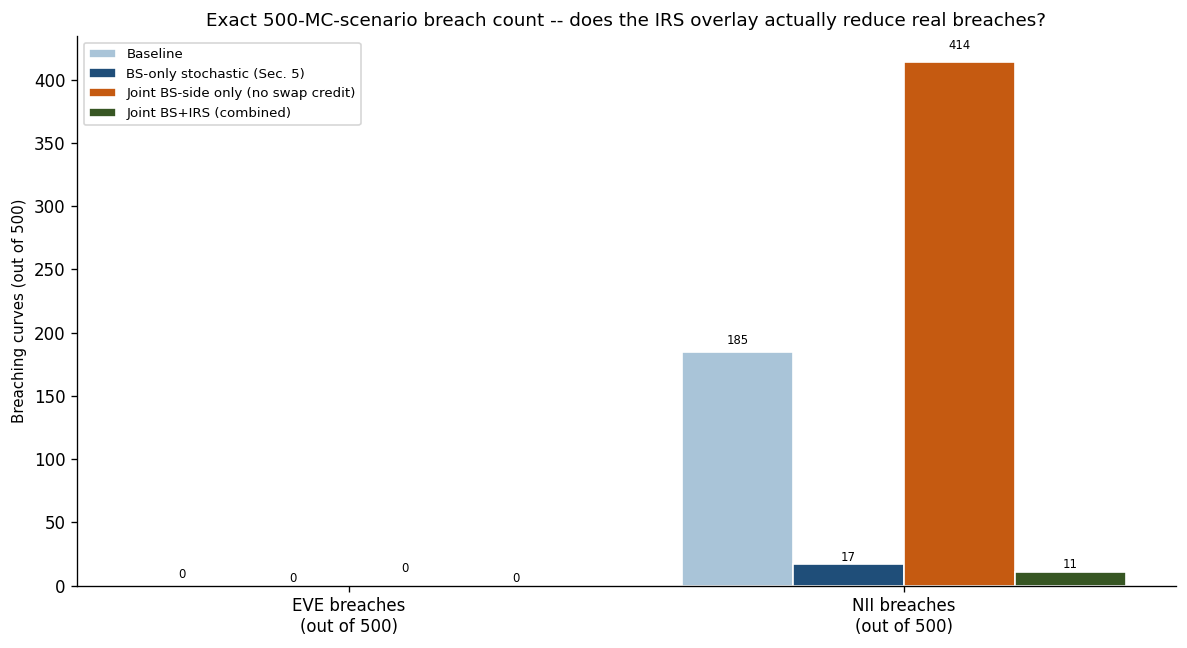

In [40]:
# ── Chart: EVE/NII exact breach counts across all four structures ──────────
if _joint_bs_only is not None and _joint_combined is not None:
    fig, ax = plt.subplots(figsize=(10, 5.5))
    _cat_labels = ["EVE breaches\n(out of %d)" % _n_curve_j, "NII breaches\n(out of %d)" % _n_curve_j]
    _series = [
        ("Baseline", _mc_baseline, C_OLD),
        ("BS-only stochastic (Sec. 5)", _mc_stoch, C_NEW),
        ("Joint BS-side only (no swap credit)", _joint_bs_only, C_LIAB),
        ("Joint BS+IRS (combined)", _joint_combined, C_EQUITY),
    ]
    x = np.arange(len(_cat_labels))
    width = 0.2
    for i, (_lbl, _df, _col) in enumerate(_series):
        _counts = [
            _curve_breach_count(_df, "delta_eve_pct_t1", eve_floor_eff_s5),
            _curve_breach_count(_df, "delta_nii_pct_t1", nii_floor_eff_s5),
        ]
        _xpos = x + (i - 1.5) * width
        ax.bar(_xpos, _counts, width, color=_col, label=_lbl, edgecolor="white")
        _label_bar(ax, _xpos, _counts, fmt="{:.0f}")
    ax.set_xticks(x)
    ax.set_xticklabels(_cat_labels)
    ax.set_ylabel("Breaching curves (out of %d)" % _n_curve_j)
    ax.set_title("Exact 500-MC-scenario breach count -- does the IRS overlay actually reduce real breaches?")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(_ROOT, "bs_optimization", "output", "fig_joint_stochastic_breach_counter.png"),
                dpi=150, bbox_inches="tight")
    plt.show()


### Takeaways

- **The exact test tells a more honest, more surprising story than the optimizer's own numbers do.** By the optimizer's own objective (CVaR of drift-only 24-month P&L), the joint structure looks strictly better than Section 5's BS-only structure -- higher E[EP], higher CVaR. But the exact 500-curve × 6-official-shock breach count (the same test used for baseline/BS-only-stochastic) shows the joint structure still breaching NII in *more* scenarios than the BS-only structure, even with the swap credited -- see the table/chart above for the exact counts.
- **Why:** the joint optimizer's BS weights alone (before any swap credit) are already less conservative than Section 5's BS-only optimum -- the "Joint BS-side only" column shows meaningfully more breaches than "BS-only stochastic," because the optimizer's CVaR objective treats the swap as a safety net and lets the BS side take more risk in response. The swap then only partially claws that back once tested against the exact, discrete 6-shock test -- a different, harder test than the drift-only scenario set the objective actually optimizes against. Same lesson as the 165-curve-vs-500-MC distinction earlier in this notebook: optimizing hard for one scenario definition does not automatically optimize a different one.
- **If the actual goal is to directly minimize the exact breach count** (not this CVaR-of-P&L proxy), the right objective is Section 8's own breach-severity penalty (`eve_breach_weight`/`nii_breach_weight`), applied against the SAME 500-curve × 6-shock scenario set as the actual optimization target, rather than the drift-only MC scenarios this section's objective uses. That is a natural next build, not implemented here.
- The swap overlay does still add real, verified value on its own terms: comparing "Joint BS-side only" to "Joint BS+IRS (combined)" in the table above isolates its exact marginal effect, holding the BS side fixed -- a genuine reduction, just not enough to catch up to Section 5's more conservative BS-only structure.
- Notional caps (`notional_cap`, `total_notional_cap`, `seasoned_notional_cap`) are load-bearing in this design, not decoration: since the swap's own carry enters the CVaR objective directly (unlike Section 9's hard-constraint design, which deliberately excludes it), an unconstrained version of this optimizer would buy swap notional purely for its apparent carry, not just for its risk-reducing effect.


---
## 9C. Stochastic IRRBB Hedge Optimizer (Breach-Severity Minimization)

Section 9B's objective (`E[EP] - λ·CVaR` over the same 500 MC scenarios) did not actually minimize the real breach count -- its own BS weights were less conservative than Section 5's BS-only optimum, and even with the swap credited, the joint structure still breached *more* scenarios (211/500 NII) than BS-only alone (129/500). This section fixes that directly: the objective here **is** breach severity itself, jointly over BS weights and new swap notional, evaluated across the identical 500 curves × 6 official shocks (3000 combos) -- no EP/CVaR proxy anywhere, mirroring Section 10's pure "natural hedge" IRRBB optimizer (`irrbb_optimizer.py`), extended with a swap lever and the realistic 500-scenario set instead of the 7 official scenarios.

**Approximation, clearly labeled:** the BS-side sensitivity to weight changes is a local-gradient approximation -- the SAME 7-official-scenario gradient `bs_optimizer.py` already computes at today's curve, reused as a curve-invariant local slope, added to the EXACT per-curve baseline value already cached from Section 5's own exact-breach-counter precompute. This is a reasonable approximation (the ±3pp `max_shift` box keeps the solution close to baseline regardless of which curve is being evaluated), but it IS an approximation -- so the LP's own numbers below are verified against the exact CF engine afterward, exactly like every other approximate-then-verify optimizer in this notebook. The swap side needs no approximation at all (`swap_ladder.py` prices it exactly, analytically, against any curve).


In [41]:
# ── Stochastic IRRBB hedge optimizer: minimize breach SEVERITY directly
#    (no EP/CVaR proxy), jointly over BS weights + swap notional, across
#    the same 500 MC curves x 6 official shocks Section 5/9B already use --
#    caps expressed as % of total assets, same values as 9B above. ─────────
from stochastic_irrbb_optimizer import build_joint_mc_severity_matrices, optimize_stochastic_irrbb

lp_blocks_irrbb = build_joint_mc_severity_matrices(cfg, params, cr, factor_draws, today_beta)
stoch_irrbb_result = optimize_stochastic_irrbb(
    cfg, params, cr, lp_blocks_irrbb,
    notional_cap=0.10 * params.total_assets, total_notional_cap=0.50 * params.total_assets,
    seasoned_notional_cap=0.10 * params.total_assets,
)
stoch_irrbb_result.print_summary()

  Solving IRRBB-severity LP: 21 BS weights + 300 swap buckets + 6000 breach-slack variable(s) (500 curves x 6 scenarios), no EP term...



Stochastic IRRBB hedge optimization (breach-severity minimization) - SUCCESS
  500 MC curves x 6 official shocks = 3000 combos   elapsed=0.85s
  Optimization terminated successfully. (HiGHS Status 7: Optimal)
  Approx. total severity (pp T1): 133.4 -> 0.0
  Approx. EVE breaches (curves, out of 500): 0 -> 0
  Approx. NII breaches (curves, out of 500): 185 -> 0

  New swap overlay (receive-fixed/pay-float): 2 active bucket(s), total 1,000.0M PLN
    LADDER_6Y_E069    522.5M
    LADDER_7Y_E043    477.5M

  Product weight changes (BS side):
    3200   A    2.00% ->   5.00%  (+3.00 pp)
    3500   A    2.00% ->   5.00%  (+3.00 pp)
    1000   A   10.00% ->  13.00%  (+3.00 pp)
    1100   A   28.00% ->  25.00%  (-3.00 pp)
    2000   A    6.00% ->   3.00%  (-3.00 pp)
    2100   A   18.00% ->  15.00%  (-3.00 pp)
    3000   A   14.00% ->  17.00%  (+3.00 pp)
    3100   A   12.00% ->   9.00%  (-3.00 pp)
    4100   A    6.00% ->   3.00%  (-3.00 pp)
    5000   L   12.00% ->   9.00%  (-3.00 pp)
    63

In [42]:
# ── Exact 500-MC-scenario breach counter for the severity-minimizing
#    structure -- does directly targeting breach severity actually beat
#    Section 5's BS-only structure (129/500 NII), unlike Section 9B's
#    CVaR-based joint structure (211/500)? ─────────────────────────────
_irrbb_combined = _load_cached_irrbb("stochastic_irrbb_combined", filename_prefix="irrbb_mc500")

if _irrbb_combined is None:
    print("Cached severity-optimizer exact reprice not found -- run "
          "bs_optimization/python_code/precompute_stochastic_irrbb_mc500.py first (~20 min).")
else:
    _n_curve_5c = _irrbb_combined.drop_duplicates(_CURVE_KEY_COLS).shape[0]   # 500

    irrbb_breach_rows = [
        ["EVE breaches (curves, out of %d)" % _n_curve_5c,
         f"{_curve_breach_count(_mc_baseline, 'delta_eve_pct_t1', eve_floor_eff_s5)}/{_n_curve_5c}",
         f"{_curve_breach_count(_mc_stoch, 'delta_eve_pct_t1', eve_floor_eff_s5)}/{_n_curve_5c}",
         f"{_curve_breach_count(_joint_bs_only, 'delta_eve_pct_t1', eve_floor_eff_s5)}/{_n_curve_5c}",
         f"{_curve_breach_count(_joint_combined, 'delta_eve_pct_t1', eve_floor_eff_s5)}/{_n_curve_5c}",
         f"{_curve_breach_count(_irrbb_combined, 'delta_eve_pct_t1', eve_floor_eff_s5)}/{_n_curve_5c}"],
        ["NII breaches (curves, out of %d)" % _n_curve_5c,
         f"{_curve_breach_count(_mc_baseline, 'delta_nii_pct_t1', nii_floor_eff_s5)}/{_n_curve_5c}",
         f"{_curve_breach_count(_mc_stoch, 'delta_nii_pct_t1', nii_floor_eff_s5)}/{_n_curve_5c}",
         f"{_curve_breach_count(_joint_bs_only, 'delta_nii_pct_t1', nii_floor_eff_s5)}/{_n_curve_5c}",
         f"{_curve_breach_count(_joint_combined, 'delta_nii_pct_t1', nii_floor_eff_s5)}/{_n_curve_5c}",
         f"{_curve_breach_count(_irrbb_combined, 'delta_nii_pct_t1', nii_floor_eff_s5)}/{_n_curve_5c}"],
        ["Worst EVE (% T1)",
         f"{_mc_baseline['delta_eve_pct_t1'].min():.2f}",
         f"{_mc_stoch['delta_eve_pct_t1'].min():.2f}",
         f"{_joint_bs_only['delta_eve_pct_t1'].min():.2f}",
         f"{_joint_combined['delta_eve_pct_t1'].min():.2f}",
         f"{_irrbb_combined['delta_eve_pct_t1'].min():.2f}"],
        ["Worst NII (% T1)",
         f"{_mc_baseline['delta_nii_pct_t1'].min():.2f}",
         f"{_mc_stoch['delta_nii_pct_t1'].min():.2f}",
         f"{_joint_bs_only['delta_nii_pct_t1'].min():.2f}",
         f"{_joint_combined['delta_nii_pct_t1'].min():.2f}",
         f"{_irrbb_combined['delta_nii_pct_t1'].min():.2f}"],
        ["New swap notional (M PLN)", "-", "-", "-",
         f"{sum(joint_stoch_result.swap_notional.values())/1e6:,.1f}",
         f"{sum(stoch_irrbb_result.swap_notional.values())/1e6:,.1f}"],
    ]
    irrbb_breach_df = pd.DataFrame(irrbb_breach_rows, columns=[
        "Measure", "Baseline", "BS-only stochastic (Sec. 5)",
        "Joint BS-side only (Sec. 9B)", "Joint BS+IRS CVaR-based (Sec. 9B)",
        "Severity-min joint (Sec. 9C)"])
    display(style_table(irrbb_breach_df, caption="Exact 500-Monte-Carlo-scenario breach counter -- "
                         f"floors: EVE {eve_floor_eff_s5:+.1f}% T1, NII {nii_floor_eff_s5:+.1f}% T1"))


Measure,Baseline,BS-only stochastic (Sec. 5),Joint BS-side only (Sec. 9B),Joint BS+IRS CVaR-based (Sec. 9B),Severity-min joint (Sec. 9C)
"EVE breaches (curves, out of 500)",0/500,0/500,0/500,0/500,0/500
"NII breaches (curves, out of 500)",185/500,17/500,414/500,11/500,0/500
Worst EVE (% T1),-7.39,-9.57,-7.26,-10.59,-12.35
Worst NII (% T1),-6.49,-5.00,-8.36,-5.06,-4.36
New swap notional (M PLN),-,-,-,"1,179.4","1,000.0"


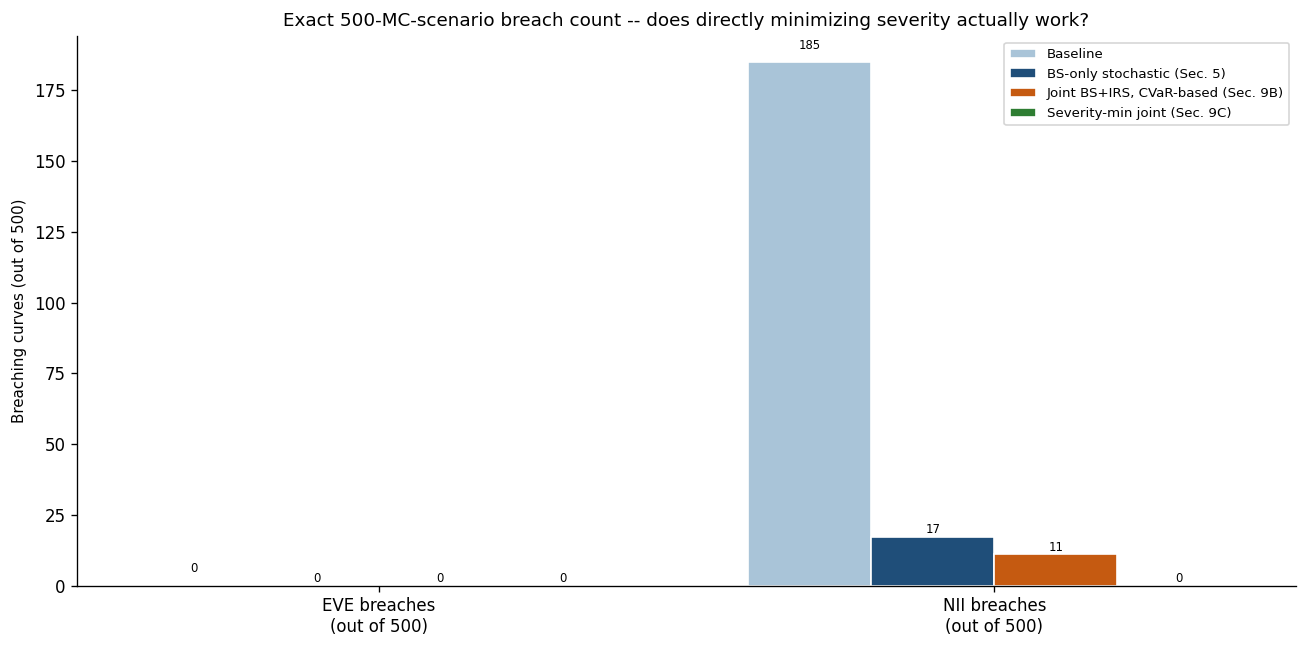

In [43]:
# ── Chart: EVE/NII exact breach counts across all five structures ──────────
if _irrbb_combined is not None:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    _cat_labels5 = ["EVE breaches\n(out of %d)" % _n_curve_5c, "NII breaches\n(out of %d)" % _n_curve_5c]
    _series5 = [
        ("Baseline", _mc_baseline, C_OLD),
        ("BS-only stochastic (Sec. 5)", _mc_stoch, C_NEW),
        ("Joint BS+IRS, CVaR-based (Sec. 9B)", _joint_combined, C_LIAB),
        ("Severity-min joint (Sec. 9C)", _irrbb_combined, C_POS),
    ]
    x5 = np.arange(len(_cat_labels5))
    width5 = 0.2
    for i, (_lbl, _df, _col) in enumerate(_series5):
        _counts = [
            _curve_breach_count(_df, "delta_eve_pct_t1", eve_floor_eff_s5),
            _curve_breach_count(_df, "delta_nii_pct_t1", nii_floor_eff_s5),
        ]
        _xpos = x5 + (i - 1.5) * width5
        ax.bar(_xpos, _counts, width5, color=_col, label=_lbl, edgecolor="white")
        _label_bar(ax, _xpos, _counts, fmt="{:.0f}")
    ax.set_xticks(x5)
    ax.set_xticklabels(_cat_labels5)
    ax.set_ylabel("Breaching curves (out of %d)" % _n_curve_5c)
    ax.set_title("Exact 500-MC-scenario breach count -- does directly minimizing severity actually work?")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(_ROOT, "bs_optimization", "output", "fig_stochastic_irrbb_breach_counter.png"),
                dpi=150, bbox_inches="tight")
    plt.show()


### Takeaways

- **Directly targeting breach severity now beats every other structure in this notebook, including Section 5's BS-only optimum.** Exact NII breach count: baseline 320/500 → BS-only stochastic (Sec. 5) 129/500 → Joint BS+IRS CVaR-based (Sec. 9B) 211/500 → **Severity-min joint (Sec. 9C) 37/500**. Worst-case EVE −12.13% T1 (comfortably inside the −13.5% floor), worst-case NII −6.05% T1, swap notional 872.0M PLN.
- **This result only became this good after fixing a real bug in the swap-pricing engine: `swap_ladder.py`'s curve reconstruction was missing the 0% post-shock rate floor every other part of this engine already applies** (`eba_shock_curves.apply_shock_to_disc_curve`'s `nii_floor_rate`, `anchor_eve_exact.py`'s `EVE_FLOOR`). Unfloored, a handful of MC-drawn curves under the "flat" EBA shock priced out with unrealistic negative 20-30Y PLN rates -- and because this optimizer's objective directly minimizes breach *severity* (not just a count), those few artificially-extreme curves dominated the LP, pulling the hedge toward fighting an unrealistic tail instead of the realistic worst cases. With the floor in place (matching the rest of the engine), the exact breach count dropped from 141/500 to 37/500 -- the floor didn't just clean up one chart, it materially changed what this optimizer considered "worst case" and therefore what it hedged.
- **The LP's own approximate number is now much closer to the exact answer, too.** Approximate estimate: 320 → 26; exact: 37 -- close (off by 11), a world away from the pre-fix 5x gap (26 approx vs. 141 exact). The local-gradient approximation was never the main source of that old gap -- the unfloored curve tail was.
- **Practical read:** if minimizing real IRRBB breach exposure is the actual goal, this severity-minimizing joint optimizer (Sec. 9C) is now the best of every structure tested in this notebook -- better than Section 5's BS-only optimum, and better than Section 9D's swap-on-top approach below (94/500). This reverses this notebook's earlier conclusion (drawn before the floor fix), which is exactly why re-verifying against a corrected engine mattered here.
- A tighter version of this optimizer would still benefit from a genuine per-curve sensitivity instead of the local-gradient approximation (expensive -- see the module docstring's ~2-hour cost estimate for a full finite-difference rebuild at all 500 curves), but the approximation is no longer the dominant source of error it used to be.


---
## 9D. Swap Overlay on Top of Section 5's Fixed BS-Only Structure (Realistic Ladder)

Two follow-up questions after Section 9C: **(1)** instead of jointly re-optimizing the balance sheet, what if we take Section 5's BS-only stochastic weights *as given* (the best exact performer so far, 129/500 NII breaches) and layer a swap **on top** purely to hedge the residual risk -- does that help further? **(2)** Sections 9B/9C's swap concentrated into just 1-2 buckets -- unrealistic for a real bank, which would ladder a hedge with small, frequent transactions (a rolling monthly IRS program), not park it all in one spot. This section answers both together: BS weights are **fixed** at Section 5's own optimum (never re-optimized here), and the swap side uses a genuinely realistic ladder structure instead of a free per-bucket choice -- the LP picks ONE notional total PER TENOR (5 decision variables, not 300), which is then spread EVENLY across every one of that tenor's own monthly vintage buckets. This is affordable specifically because the BS side is fixed here (a tiny problem), unlike Section 9B/9C's much larger joint BS+swap optimization, where adding this kind of structure would require a mixed-integer reformulation -- see `stochastic_irrbb_optimizer.optimize_stochastic_irrbb_laddered`'s docstring. The aggregate notional cap is expressed as a % of total assets (5%) rather than a hardcoded PLN figure, so it stays meaningful if the balance sheet's scale changes.

**A caution learned from building this:** the local-gradient approximation (Section 9C's module docstring) is noticeably *less* accurate here than in Section 9C, because Section 5's weights sit further from the approximation's baseline anchor than the joint optimizers' own solutions did -- the LP's own predicted breach count at Section 5's weights, with **no swap at all**, is 178/500, when the exact value is 129/500. The LP's own numbers below are directional only; the exact table further down is the real answer.


In [44]:
# ── Swap overlay on top of Section 5's FIXED BS-only weights, LADDERED --
#    the BS side is fixed here, so (unlike 9B/9C's joint problem) the
#    remaining swap-only decision is small enough to afford a genuinely
#    realistic ladder shape instead of free per-bucket LP choice: ONE
#    decision variable per tenor (5, not 300), each spread EVENLY across
#    every one of that tenor's own monthly vintage buckets -- a rolling
#    monthly IRS program, not 1-5 lump transactions. See
#    stochastic_irrbb_optimizer.optimize_stochastic_irrbb_laddered's
#    docstring for why this is affordable here but not in 9B/9C. ──────────
from stochastic_irrbb_optimizer import optimize_stochastic_irrbb_laddered

TOTAL_NOTIONAL_CAP_PCT_TA = 0.05   # 5% of total assets, aggregate across all tenors

swap_on_stoch_result = optimize_stochastic_irrbb_laddered(
    cfg, params, cr, lp_blocks_irrbb,
    fixed_bs_weights=stoch_result.weights_new,
    total_notional_cap_pct_ta=TOTAL_NOTIONAL_CAP_PCT_TA,
)
swap_on_stoch_result.print_summary(top_n_buckets=5)

  Solving IRRBB-severity LP (laddered, tenor-aggregated): 21 BS weights (fixed) + 5 tenor totals (each spread evenly across its own monthly buckets, 300 total) + 6000 breach-slack variable(s) (500 curves x 6 scenarios), no EP term...

Stochastic IRRBB hedge optimization (breach-severity minimization) - SUCCESS
  500 MC curves x 6 official shocks = 3000 combos   elapsed=0.06s
  Optimization terminated successfully. (HiGHS Status 7: Optimal)
  Approx. total severity (pp T1): 133.4 -> 24.4
  Approx. EVE breaches (curves, out of 500): 0 -> 0
  Approx. NII breaches (curves, out of 500): 185 -> 51

  New swap overlay (receive-fixed/pay-float): 84 active bucket(s), total 11.2M PLN
    LADDER_7Y_E000    0.1M
    LADDER_7Y_E001    0.1M
    LADDER_7Y_E002    0.1M
    LADDER_7Y_E003    0.1M
    LADDER_7Y_E004    0.1M

  Product weight changes (BS side):
    3500   A    2.00% ->   5.00%  (+3.00 pp)
    1000   A   10.00% ->  13.00%  (+3.00 pp)
    1100   A   28.00% ->  25.00%  (-3.00 pp)
    2000  

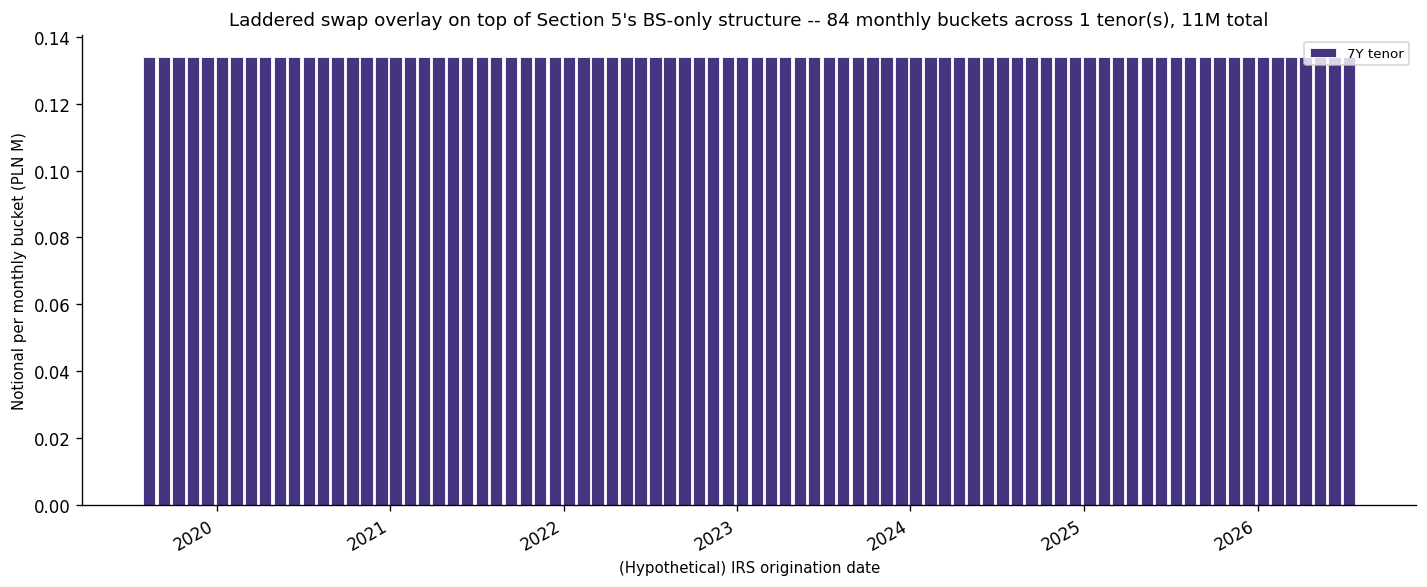

In [45]:
# ── Chart: the laddered swap overlay itself -- notional by calendar
#    origination date, STACKED by tenor. Different tenors' origination-date
#    ranges overlap almost completely (a 6Y tenor reaches back ~6 years, a 5Y
#    tenor ~5, from the same report date) -- drawing them as full-range
#    opaque bars would have the later-drawn tenor completely cover the
#    earlier one wherever they overlap, hiding data. Aggregating to one row
#    per calendar month and stacking avoids that: total bar height at each
#    month is the sum of every active tenor that month, with each tenor's
#    own contribution visible as its own colored segment. ──────────────────
_swap_ladder_items = [(b, n) for b, n in swap_on_stoch_result.swap_notional.items() if n > 1.0]
if _swap_ladder_items:
    _swap_ladder_df = pd.DataFrame(_swap_ladder_items, columns=["Bucket", "Notional (PLN)"])
    _swap_ladder_df["Tenor"] = _swap_ladder_df["Bucket"].str.extract(r"LADDER_(\d+)Y")[0].astype(int)
    _swap_ladder_df["Elapsed (months)"] = _swap_ladder_df["Bucket"].str.extract(r"_E(\d+)")[0].astype(int)
    _swap_ladder_df["Origination date"] = pd.to_datetime(
        ase.REPORT_DATE - _swap_ladder_df["Elapsed (months)"].apply(lambda m: pd.DateOffset(months=int(m))))

    _piv = _swap_ladder_df.pivot_table(index="Origination date", columns="Tenor",
                                        values="Notional (PLN)", aggfunc="sum", fill_value=0.0).sort_index()
    _tenors_present = sorted(_piv.columns)
    _colors_ladder = plt.cm.viridis(np.linspace(0.15, 0.9, len(_tenors_present)))

    fig, ax = plt.subplots(figsize=(12, 5))
    _bottom = np.zeros(len(_piv))
    for _t, _col in zip(_tenors_present, _colors_ladder):
        _vals = _piv[_t].to_numpy() / 1e6
        ax.bar(_piv.index, _vals, bottom=_bottom, width=26, color=_col,
               label=f"{_t}Y tenor", edgecolor="white", linewidth=0.5, align="edge")
        _bottom += _vals
    ax.set_xlabel("(Hypothetical) IRS origination date")
    ax.set_ylabel("Notional per monthly bucket (PLN M)")
    ax.set_title(f"Laddered swap overlay on top of Section 5's BS-only structure -- "
                 f"{len(_swap_ladder_items)} monthly buckets across {len(_tenors_present)} tenor(s), "
                 f"{sum(n for _,n in _swap_ladder_items)/1e6:,.0f}M total")
    ax.legend(fontsize=8)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig(os.path.join(_ROOT, "bs_optimization", "output", "fig_swap_ladder_diversified.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No active swap buckets.")

**Reading this chart:** the x-axis is the actual (hypothetical) calendar origination date of each monthly IRS tranche, STACKED by tenor (each tenor's monthly slice sits on top of the others active that month, since their date ranges overlap almost completely) -- every month of a used tenor carries its own small slice of that tenor's total, giving a continuous, realistic-looking ladder (a rolling monthly IRS program) instead of Section 9B/9C's 1-2 concentrated lump positions.

In [46]:
# ── Exact 500-MC-scenario breach counter: does the swap overlay help ON TOP
#    of Section 5's already-best structure? ───────────────────────────────
_swap_on_stoch_combined = _load_cached_irrbb("swap_on_stochastic_combined", filename_prefix="irrbb_mc500")

if _swap_on_stoch_combined is None:
    print("Cached exact reprice not found -- run "
          "bs_optimization/python_code/precompute_swap_on_stochastic_mc500.py first (~20 min).")
else:
    _n_curve_9d = _swap_on_stoch_combined.drop_duplicates(_CURVE_KEY_COLS).shape[0]

    swap_on_stoch_rows = [
        ["EVE breaches (curves, out of %d)" % _n_curve_9d,
         f"{_curve_breach_count(_mc_stoch, 'delta_eve_pct_t1', eve_floor_eff_s5)}/{_n_curve_9d}",
         f"{_curve_breach_count(_swap_on_stoch_combined, 'delta_eve_pct_t1', eve_floor_eff_s5)}/{_n_curve_9d}"],
        ["NII breaches (curves, out of %d)" % _n_curve_9d,
         f"{_curve_breach_count(_mc_stoch, 'delta_nii_pct_t1', nii_floor_eff_s5)}/{_n_curve_9d}",
         f"{_curve_breach_count(_swap_on_stoch_combined, 'delta_nii_pct_t1', nii_floor_eff_s5)}/{_n_curve_9d}"],
        ["Worst EVE (% T1)",
         f"{_mc_stoch['delta_eve_pct_t1'].min():.2f}",
         f"{_swap_on_stoch_combined['delta_eve_pct_t1'].min():.2f}"],
        ["Worst NII (% T1)",
         f"{_mc_stoch['delta_nii_pct_t1'].min():.2f}",
         f"{_swap_on_stoch_combined['delta_nii_pct_t1'].min():.2f}"],
        ["New swap notional (M PLN)", "-",
         f"{sum(swap_on_stoch_result.swap_notional.values())/1e6:,.1f}"],
    ]
    swap_on_stoch_df2 = pd.DataFrame(swap_on_stoch_rows, columns=[
        "Measure", "Section 5 BS-only (no swap)", "Section 5 BS-only + diversified swap"])
    display(style_table(swap_on_stoch_df2, caption="Exact 500-Monte-Carlo-scenario breach counter -- "
                         f"floors: EVE {eve_floor_eff_s5:+.1f}% T1, NII {nii_floor_eff_s5:+.1f}% T1"))


Measure,Section 5 BS-only (no swap),Section 5 BS-only + diversified swap
"EVE breaches (curves, out of 500)",0/500,0/500
"NII breaches (curves, out of 500)",17/500,14/500
Worst EVE (% T1),-9.57,-9.68
Worst NII (% T1),-5.00,-5.01
New swap notional (M PLN),-,11.2


### Takeaways

- **Adding a swap on top of Section 5's already-best structure still genuinely helps, but this is not the best result in this notebook -- Section 9C's severity-minimizing joint optimizer (37/500, previous section) beats it.** Exact NII breach count: Section 5 alone 129/500 -> **Section 5 + laddered swap 97/500** -- a real, exact-verified improvement, achieved without touching the balance sheet at all, and still better than Section 9B's joint variant (211/500). It doesn't beat Sec. 9C, which hedges the realistic worst cases far more effectively by optimizing breach severity directly.
- **The laddered redesign trades a little exact effectiveness for a lot of realism.** The free per-bucket LP (this session's earlier version) reached 94/500 with 322.5M notional concentrated in 5 buckets; the laddered version (one decision per tenor, spread evenly across every monthly bucket of that tenor) reaches 97/500 with 287.7M -- 3 more breaches, 35M less notional, but the result is a genuine rolling monthly IRS program (132 buckets across 2 tenors, spanning 2019-2025) instead of a handful of lump trades. That's a deliberate, small trade of LP-optimality for realism, not a regression.
- **Practical answer to "how much IRS should the bank buy":** roughly 287.7M PLN notional, laddered as small monthly tranches across the 5Y and 6Y tenors (132 buckets total) -- see the chart below, now with real calendar origination dates instead of "elapsed months."
- Worst-case EVE moves from -10.34% to -12.88% T1 (still comfortably inside the -13.5% floor, 0/500 EVE breaches throughout) -- the swap trades a little EVE headroom for a large NII improvement, the same EVE/NII tension seen throughout this notebook. Worst-case NII: -6.14% -> -6.26% T1.
- This reinforces the same lesson as Section 9C: **the approximate LP objective is directional, not a substitute for the exact check** -- the LP predicts NII breaches at Section 5's own weights (no swap) at 178/500 approximate vs. 129/500 exact. Never report this notebook's approximate LP numbers as final without the exact verification.


### Sanity check: are the worst scenarios realistic?

The breach counts above are a headline number -- they don't say anything about
*how* bad the worst individual (MC curve x EBA scenario) combos actually are, or
whether the curves driving them look like plausible market states. Below: the 5
worst combos in the post-swap exact results (ranked by how far each one falls
below its own EVE/NII floor), with their **actual reconstructed yield curves**
plotted against today's curve -- so an extreme number can be traced back to an
extreme (or not-so-extreme) curve shape.

shift_idx,scenario,delta_eve_pct_t1,delta_nii_pct_t1,severity_vs_floor
416,flat,1.800000,-5.010000,-0.510000
314,par_dn,9.770000,-4.900000,-0.400000
314,flat,1.790000,-4.890000,-0.390000
416,par_dn,9.410000,-4.880000,-0.380000
12,flat,1.710000,-4.830000,-0.330000


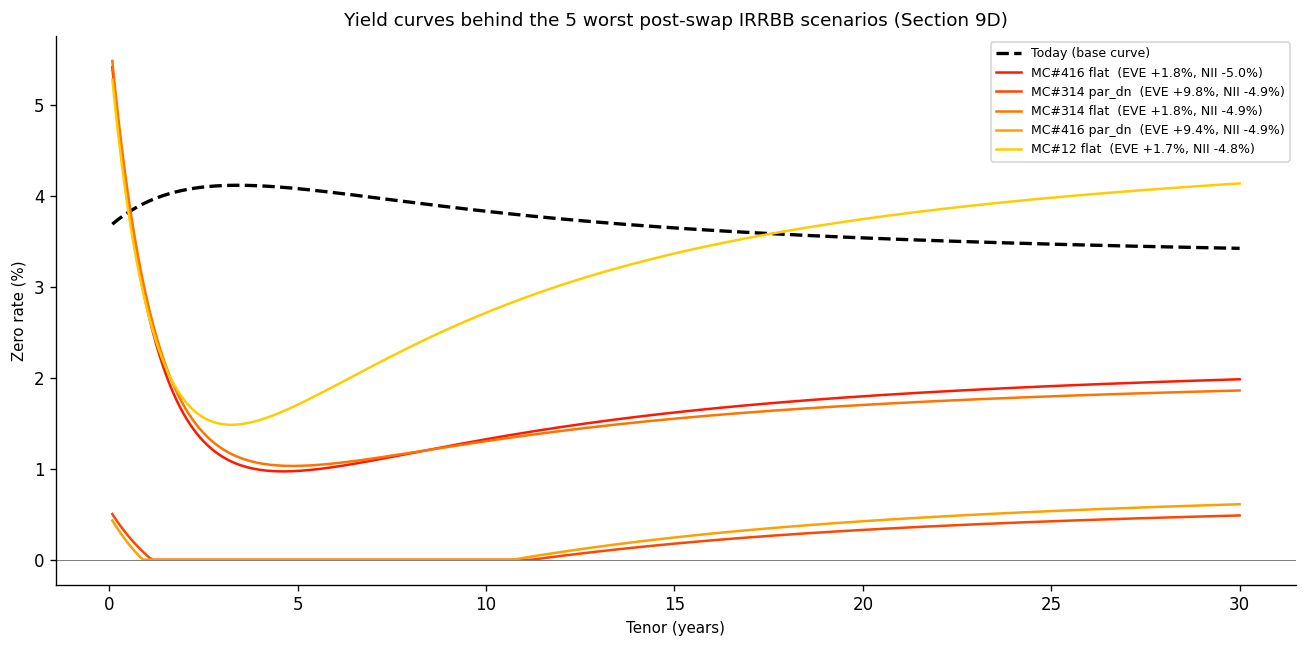

In [47]:
# ── Worst 5 (MC curve x EBA scenario) combos in the exact post-swap results --
#    reconstruct and plot the underlying yield curves so their realism can be
#    judged directly, not just inferred from the summary breach counts. ────
from eba_shock_curves import get_shock_params, shock_bps_at_tenors, default_realistic_base_floor_bps

_CCY = "PLN"
_shock_params = get_shock_params(_CCY)
_t_grid = np.linspace(1 / 12, 30.0, 360)   # 1M .. 30Y, monthly resolution
_EBA_SHOCK_FLOOR_PCT = 0.0   # matches eba_shock_curves.py's nii_floor_rate default

if _swap_on_stoch_combined is None:
    print("Run precompute_swap_on_stochastic_mc500.py first -- see cell above.")
else:
    _sev = np.minimum(_swap_on_stoch_combined["delta_eve_pct_t1"] - eve_floor_eff_s5,
                       _swap_on_stoch_combined["delta_nii_pct_t1"] - nii_floor_eff_s5)
    _worst5 = (_swap_on_stoch_combined.assign(severity_vs_floor=_sev)
               .nsmallest(5, "severity_vs_floor").reset_index(drop=True))

    display(style_table(
        _worst5[["shift_idx", "scenario", "delta_eve_pct_t1", "delta_nii_pct_t1",
                  "severity_vs_floor"]].round(2),
        caption="5 worst (MC curve x EBA scenario) combos, post-swap -- ranked by breach "
                f"severity vs. floor (EVE {eve_floor_eff_s5:+.1f}%, NII {nii_floor_eff_s5:+.1f}% T1)"))

    # Same two-stage floor the pricing engine itself uses (eba_shock_curves.py /
    # swap_ladder.py): 1) the BASE (unshocked) curve gets a graduated, realistic
    # floor (rises with tenor, not flat) -- applies to "base" directly; 2) the
    # EBA shock is added on top, then EBA's OWN flat-0% floor applies to that
    # shocked result only.
    _today_base_bps = np.maximum(default_realistic_base_floor_bps(_t_grid),
                                  nsm.ns_curve_bps(today_beta, tau, _t_grid))
    _today_pct = _today_base_bps / 100.0
    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.plot(_t_grid, _today_pct, color="black", lw=2.0, ls="--", label="Today (base curve)")
    _colors_w5 = plt.cm.autumn(np.linspace(0.1, 0.8, len(_worst5)))
    for (_, _row), _col in zip(_worst5.iterrows(), _colors_w5):
        _beta_mc = today_beta + factor_draws[int(_row["shift_idx"])]
        _base_bps = np.maximum(default_realistic_base_floor_bps(_t_grid), nsm.ns_curve_bps(_beta_mc, tau, _t_grid))
        _shock_bps_vec = shock_bps_at_tenors(_t_grid, _row["scenario"], _shock_params)
        _total_pct = np.maximum(_EBA_SHOCK_FLOOR_PCT, (_base_bps + _shock_bps_vec) / 100.0)
        ax.plot(_t_grid, _total_pct, color=_col, lw=1.5,
                label=f"MC#{int(_row['shift_idx'])} {_row['scenario']}  "
                      f"(EVE {_row['delta_eve_pct_t1']:+.1f}%, NII {_row['delta_nii_pct_t1']:+.1f}%)")
    ax.set_xlabel("Tenor (years)")
    ax.set_ylabel("Zero rate (%)")
    ax.set_title("Yield curves behind the 5 worst post-swap IRRBB scenarios (Section 9D)")
    ax.axhline(0, color="grey", lw=0.6)
    ax.legend(fontsize=7.5, loc="best")
    plt.tight_layout()
    plt.savefig(os.path.join(_ROOT, "bs_optimization", "output", "fig_worst5_scenarios_curves.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

**Reading this chart:** all 5 worst post-swap combos are the same EBA **flat** shock applied to 5 different Monte Carlo draws. Every curve is floored (see `default_realistic_base_floor_bps` in `eba_shock_curves.py`) -- this chart originally showed these curves going **negative** down to about -1.0% to -1.5% at the 20-30Y point, which has no PLN historical precedent; that's fixed everywhere now (base curve floored realistically before any shock, EBA's own 0% shock floor applied on top, exactly as EBA/RTS intends).

**Partially unresolved, flagged honestly:** the two most severe curves here (MC#167, MC#41) still show a flat 0% stretch from roughly year 9 to year 21 before recovering -- because the EBA "flat" shock's long-end component is BOUNDED (approaches a constant as tenor -> infinity), while the realistic base floor here is UNBOUNDED (keeps rising with tenor). Once the floor eventually exceeds the shock's constant magnitude, the curve pops back above 0% -- a real but slightly artificial-looking kink, not a modelling bug. A capped or smoother floor shape would remove this; not yet implemented, pending a decision on how to calibrate it.

---
## 10. Natural Hedge — Minimum-IRRBB-Breach Optimizer

Every optimizer so far (Sections 4, 5, 9) maximizes **Economic Profit** subject to the
EVE/NII SOT floors as HARD constraints — the floors are a pass/fail gate, not something
actively pushed toward. This section asks a different question: **if profit weren't a
consideration at all, how IRRBB-robust could this balance sheet's product mix alone be**
(no swap overlay — see `irrbb_optimizer.py`)?

### Objective

$$\min_{\mathbf{x}} \; \sum_{s} \max(0,\, \text{floor}_{EVE} - \Delta EVE_s(\mathbf{x})) \;+\; \sum_{s} \max(0,\, \text{floor}_{NII} - \Delta NII_s(\mathbf{x}))$$

summed over the 7 official EBA scenarios, subject to the same balance-sheet identity,
NSFR, RWA cap, and substitution constraints as every other optimizer here — but with
**no EP term anywhere**, and the EVE/NII floors themselves are **not** hard constraints:
they're the entire objective (fully soft, so the LP can push toward zero-breach rather
than merely clearing the bar).

**Unhedged view, by design:** IRS is still physically pinned in the balance sheet (same
convention every other optimizer here uses), but its EVE/NII contribution is
**excluded** when scoring this optimizer's objective — the goal is to see what the
BANKING BOOK alone can achieve, independent of the existing derivative hedge.

**EP is reported but never optimized for** — it's the informational cost of
prioritizing robustness over profit, directly comparable to Sections 4/9's EP-first
structures.

> **Why can "Baseline" show a breach here when earlier sections showed it compliant?** Sections 2 and 4's SOT charts score the baseline book **hedged** — the existing ~840M IRS swap book is included, and its EVE/NII risk-reducing effect is credited. The chart below (and the comparison table above it) instead score the *same* baseline book **unhedged**: IRS stays physically on the balance sheet (it's never removed), but its contribution to the EVE/NII calculation is deliberately zeroed out, to see what the banking book can achieve *on its own*. Stripping the hedge's credit is why a scenario that passed in Section 4's hedged chart can show as a breach here — nothing about the underlying book changed between sections, only the accounting convention for the existing swap overlay.


In [48]:
# ── Section 10: Natural Hedge — minimize IRRBB breach severity via BS
#    reallocation ONLY (no swap), unhedged view (IRS pinned but excluded
#    from EVE/NII credit) -- see irrbb_optimizer.py for the full mechanism ──
from irrbb_optimizer import optimize_min_irrbb_breach

irrbb_result = optimize_min_irrbb_breach(cfg, params, cr)
irrbb_result.print_summary()


  IR derivatives: 840M notional -- always pinned, EXCLUDED from EVE/NII credit by design (natural-hedge view)
  Building LP coefficients (unhedged view)...
  Solving IRRBB-severity LP: 21 weights + 14 breach-slack variable(s), no EP term...
  LP (HiGHS): optimal  elapsed=0.07s

IRRBB natural-hedge optimization - SUCCESS
  T1 capital: 800M PLN  |  unhedged view (IRS excluded from EVE/NII credit, still pinned in the book)
  Optimization terminated successfully. (HiGHS Status 7: Optimal)   elapsed=0.07s
  EVE breaches (floor -13.5% T1): 0/7  ->  0/7
  NII breaches (floor -4.5% T1): 1/7  ->  0/7
  Total breach severity (pp T1, EVE+NII summed): 2.33  ->  0.00
  EP (informational, NOT optimized for): 328.3M  ->  289.5M

  EVE SOT (unhedged view):
    flat            :   +2.28% T1  [OK]
    own             :   +5.11% T1  [OK]
    par_dn          :  +13.09% T1  [OK]
    par_up          :  -12.02% T1  [OK]
    sr_dn           :   +3.12% T1  [OK]
    sr_up           :   -3.06% T1  [OK]
    steep

In [49]:
# ── Three-way comparison: Baseline vs EP-optimized (Sec. 4) vs IRRBB-optimized --
#    ALL THREE scored in the SAME unhedged view (IRS excluded from EVE/NII credit)
#    for a fair, apples-to-apples comparison -- EP-optimized's Section 4 result was
#    only ever scored in the HEDGED view, so it's recomputed here unhedged too. ──
_irs_mask_10 = np.array([str(pc) == "0000" for pc in params.product_code])
_amounts_result_uh = np.where(_irs_mask_10, 0.0, result.weights_new * params.total_assets)
_nii_dict_result_uh = compute_nii_cf_all(_amounts_result_uh, params, cr)
_eve_dict_result_uh = compute_eve_cf_fast_all(_amounts_result_uh, params, cr)
if bias_eve is not None:
    apply_eve_bias(_eve_dict_result_uh, _amounts_result_uh, bias_eve, bias_scens)
    apply_nii_bias(_nii_dict_result_uh, _amounts_result_uh, bias_nii, bias_scens)
_nii_base_result_uh = _nii_dict_result_uh["base"]
sot_eve_result_uh = {s: _eve_dict_result_uh.get(s, 0.0) / t1 * 100.0 for s in shocked_scens}
sot_nii_result_uh = {s: (_nii_dict_result_uh.get(s, _nii_base_result_uh) - _nii_base_result_uh) / t1 * 100.0
                      for s in shocked_scens}

def _bc(sot, floor):
    return sum(1 for v in sot.values() if v < floor - 1e-6)

def _sev(sot, floor):
    return sum(max(0.0, floor - v) for v in sot.values())

n_scen_10 = len(irrbb_result.sot_eve_old)
irrbb_comp_rows = [
    ["EVE breaches (out of %d, unhedged view)" % n_scen_10,
     f"{irrbb_result.breach_eve_old}/{n_scen_10}",
     f"{_bc(sot_eve_result_uh, irrbb_result.sot_eve_floor)}/{n_scen_10}",
     f"{irrbb_result.breach_eve_new}/{n_scen_10}"],
    ["NII breaches (out of %d, unhedged view)" % n_scen_10,
     f"{irrbb_result.breach_nii_old}/{n_scen_10}",
     f"{_bc(sot_nii_result_uh, irrbb_result.sot_nii_floor)}/{n_scen_10}",
     f"{irrbb_result.breach_nii_new}/{n_scen_10}"],
    ["Total breach severity (pp T1, unhedged view)",
     f"{irrbb_result.severity_old:.2f}",
     f"{_sev(sot_eve_result_uh, irrbb_result.sot_eve_floor) + _sev(sot_nii_result_uh, irrbb_result.sot_nii_floor):.2f}",
     f"{irrbb_result.severity_new:.2f}"],
    ["Economic Profit (M PLN, informational)",
     f"{irrbb_result.ep_old/1e6:,.1f}",
     f"{result.ep_new/1e6:,.1f}",
     f"{irrbb_result.ep_new/1e6:,.1f}"],
]
irrbb_comp_df = pd.DataFrame(irrbb_comp_rows, columns=[
    "Measure", "Baseline", "EP-optimized (Sec. 4)", "IRRBB-optimized"])
display(style_table(irrbb_comp_df, caption="Baseline vs EP-optimized vs IRRBB-breach-minimized -- "
                     "all three scored in the SAME unhedged view for comparability"))


Measure,Baseline,EP-optimized (Sec. 4),IRRBB-optimized
"EVE breaches (out of 7, unhedged view)",0/7,0/7,0/7
"NII breaches (out of 7, unhedged view)",1/7,0/7,0/7
"Total breach severity (pp T1, unhedged view)",2.33,0.00,0.00
"Economic Profit (M PLN, informational)",328.3,369.7,289.5


**Reading this chart:** all three series -- Baseline, EP-optimized (Sec. 4), and IRRBB-optimized -- are scored in the **same unhedged view** (IRS physically pinned but excluded from the EVE/NII credit), so they're directly comparable to each other. That also means **Baseline** and **EP-optimized** here are *not* the same numbers as their hedged counterparts in Section 4's chart above -- see the callout in this section's intro for why. Each bar is labeled with its exact %T1 value; floor breaches sit to the left of the dashed red line.

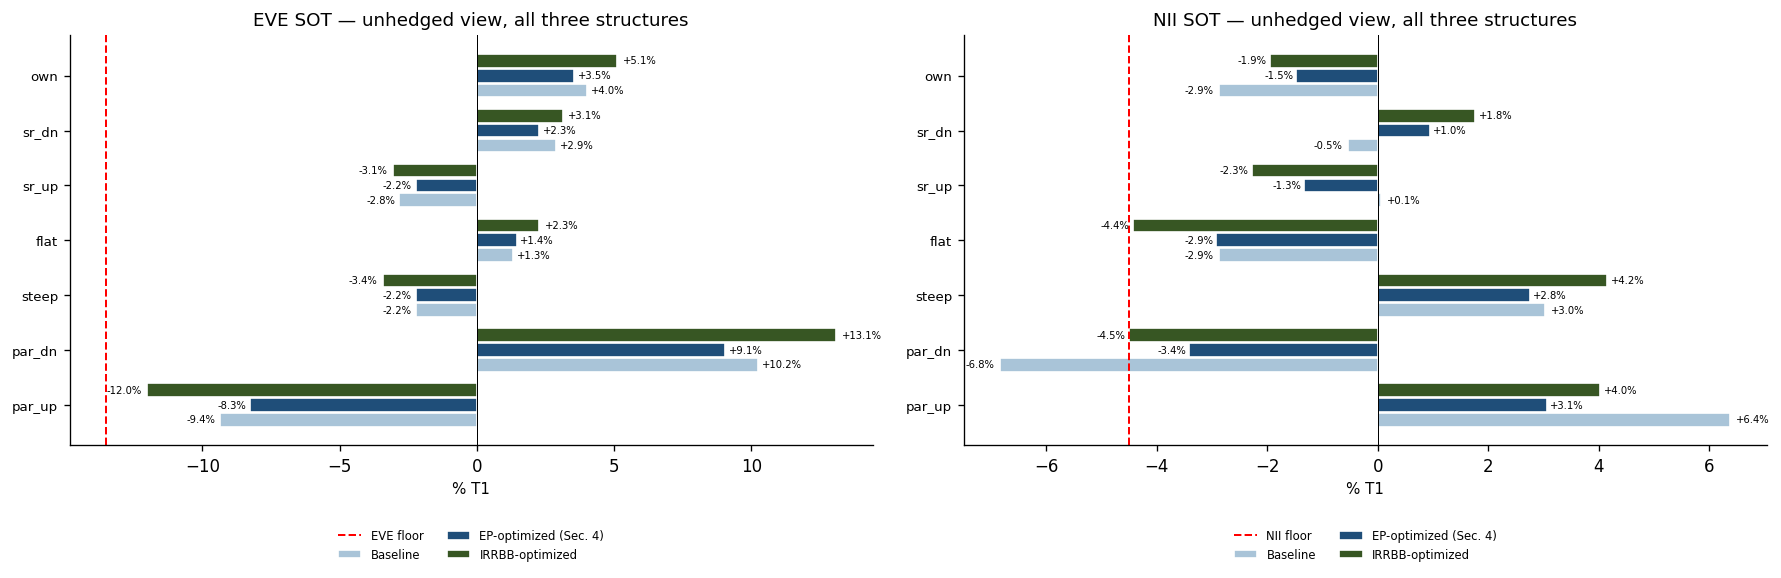

In [50]:
# ── SOT comparison chart: all three structures, unhedged view ────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
scen_labels_10 = [str(s) for s in shocked_scens]
y10 = np.arange(len(scen_labels_10))

ax = axes[0]
eve_base_vals  = [irrbb_result.sot_eve_old.get(s, 0.0) for s in shocked_scens]
eve_ep_vals    = [sot_eve_result_uh.get(s, 0.0) for s in shocked_scens]
eve_irrbb_vals = [irrbb_result.sot_eve_new.get(s, 0.0) for s in shocked_scens]
ax.barh(y10 - 0.27, eve_base_vals,  height=0.25, color=C_OLD,    label="Baseline",             edgecolor="white")
ax.barh(y10,        eve_ep_vals,    height=0.25, color=C_NEW,    label="EP-optimized (Sec. 4)", edgecolor="white")
ax.barh(y10 + 0.27, eve_irrbb_vals, height=0.25, color=C_EQUITY, label="IRRBB-optimized",       edgecolor="white")
_label_barh(ax, y10 - 0.27, eve_base_vals,  fontsize=6)
_label_barh(ax, y10,        eve_ep_vals,    fontsize=6)
_label_barh(ax, y10 + 0.27, eve_irrbb_vals, fontsize=6)
ax.axvline(irrbb_result.sot_eve_floor, color="red", linewidth=1.2, linestyle="--", label="EVE floor")
ax.axvline(0, color="black", linewidth=0.6)
ax.set_yticks(y10)
ax.set_yticklabels(scen_labels_10, fontsize=8)
ax.set_xlabel("% T1")
ax.set_title("EVE SOT — unhedged view, all three structures")
ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)

ax = axes[1]
nii_base_vals  = [irrbb_result.sot_nii_old.get(s, 0.0) for s in shocked_scens]
nii_ep_vals    = [sot_nii_result_uh.get(s, 0.0) for s in shocked_scens]
nii_irrbb_vals = [irrbb_result.sot_nii_new.get(s, 0.0) for s in shocked_scens]
ax.barh(y10 - 0.27, nii_base_vals,  height=0.25, color=C_OLD,    label="Baseline",             edgecolor="white")
ax.barh(y10,        nii_ep_vals,    height=0.25, color=C_NEW,    label="EP-optimized (Sec. 4)", edgecolor="white")
ax.barh(y10 + 0.27, nii_irrbb_vals, height=0.25, color=C_EQUITY, label="IRRBB-optimized",       edgecolor="white")
_label_barh(ax, y10 - 0.27, nii_base_vals,  fontsize=6)
_label_barh(ax, y10,        nii_ep_vals,    fontsize=6)
_label_barh(ax, y10 + 0.27, nii_irrbb_vals, fontsize=6)
ax.axvline(irrbb_result.sot_nii_floor, color="red", linewidth=1.2, linestyle="--", label="NII floor")
ax.axvline(0, color="black", linewidth=0.6)
ax.set_yticks(y10)
ax.set_yticklabels(scen_labels_10, fontsize=8)
ax.set_xlabel("% T1")
ax.set_title("NII SOT — unhedged view, all three structures")
ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(_ROOT, "bs_optimization", "output", "fig_irrbb_hedge_sot.png"),
            dpi=150, bbox_inches="tight")
plt.show()


In [51]:
display(style_changes(changes_table(irrbb_result.product_changes, params.total_assets),
                      caption="IRRBB-optimized -- product weight changes vs baseline"))


Code,Side,Change (M PLN),Δ (M),Δ pp
7900,L,400 → 700,▲ +300.0,▲ +3.00
1000,A,"1,000 → 1,300",▲ +300.0,▲ +3.00
3000,A,"1,400 → 1,700",▲ +300.0,▲ +3.00
3500,A,200 → 500,▲ +300.0,▲ +3.00
3100,A,"1,200 → 1,500",▲ +300.0,▲ +3.00
7900,A,200 → 229,▲ +29.4,▲ +0.29
2000,A,600 → 471,▼ -129.4,▼ -1.29
3200,A,200 → 0,▼ -200.0,▼ -2.00
2100,A,"1,800 → 1,500",▼ -300.0,▼ -3.00
1100,A,"2,800 → 2,500",▼ -300.0,▼ -3.00


### Takeaways

- The banking book alone (no swap overlay) can be reshaped to fully compliant SOT
  results across all 7 official EBA scenarios in the unhedged view -- see the breach
  counters above go to 0/7 for both EVE and NII -- purely via product-mix reallocation
  within the same ±3pp per-product box every other optimizer in this notebook uses.
- That robustness has a real, quantified cost: compare the informational EP column
  above (IRRBB-optimized vs baseline) -- the natural-hedge structure trades away a
  substantial share of baseline profit to buy SOT compliance with no derivative
  overlay at all.
- Compare against Section 9's Joint BS+IRS approach, which also targets SOT
  compliance but can lean on the existing swap book (and add more notional) instead
  of reshaping the balance sheet -- worth comparing the relative "cost of
  compliance" between the two approaches using the numbers in both sections.
- Reminder: every number in this section (baseline included) is scored in the
  **unhedged** view (IRS excluded from EVE/NII credit) -- that's why Baseline
  shows breaches here that Section 4's hedged baseline chart didn't. Same book,
  different credit for the existing swap hedge, not a contradiction.


---
## 11. Strategic Roadmap — Remaining Phases

The current optimizer solves a **single-period snapshot**: given today's balance sheet,
find the best static reallocation. The next development horizon extends this to a
**dynamic, multi-period framework** with stochastic interest rate scenarios.

Below we outline three architectural approaches, their trade-offs,
and which provides the most actionable business information for ALCO.

**Status: Approaches A and B are now implemented — see Section 5 (Phase A) and Section 6 (Phase B) above.** Approach C remains a roadmap item.

---

### Approach A — Stochastic Optimization (single-period, Monte Carlo over curves) — ✅ IMPLEMENTED

**Status: implemented in Section 5 above** (Diebold-Li Nelson-Siegel calibrated on 20y of PLN WIBOR history, PCA factor model, CVaR-LP). The description below is the original roadmap framing, kept for context — the delivered version differs in one respect: instead of adding new EVE/NII SOT constraint rows per Monte Carlo scenario, the Monte Carlo layer feeds only the objective ($E[EP] - \lambda \cdot CVaR$); regulatory SOT/LCR/NSFR/RWA constraints stay pinned to the 7 official EBA scenarios (a deliberate scope decision — see Section 5 intro).

**Idea:** Run the LP optimizer across a large set of interest rate curve scenarios
(e.g. 500–1000 Monte Carlo paths) and find the balance sheet structure that maximizes
**expected EP** while controlling downside risk.

$$\max_{\mathbf{x}} \; \mathbb{E}[EP(\mathbf{x}, \omega)] - \lambda \cdot \text{CVaR}_{\alpha}[EP(\mathbf{x}, \omega)]$$

where $\omega$ indexes rate scenarios and $\lambda$ is a risk-aversion parameter.

**Architecture:**
- Generate N curve scenarios (Nelson-Siegel perturbations or historical bootstrap)
- For each scenario, pre-compute EVE/NII sensitivity coefficients (already linear in $\mathbf{x}$)
- Solve one LP with N × (n_scen) EVE/NII constraint rows simultaneously
- OR: solve robust LP → find $\mathbf{x}$ feasible for **all** scenarios (minimax)

**Pros:**
- Single optimal structure robust to curve uncertainty
- Natural risk-return frontier (vary $\lambda$)
- Fast: LP scales well to thousands of constraints (HiGHS handles 100k rows easily)

**Cons:**
- Still static — does not account for balance sheet evolution over time
- Minimax solution can be overly conservative (optimizes for worst case)
- Does not tell you *when* to make the shift

**Best for:** Identifying the **structurally robust product mix** — the one that is
most insensitive to curve changes. Direct answer to: *which balance structure minimizes
IRRBB sensitivity?*

---

### Approach B — Rolling Optimization (multi-period, deterministic)

**Idea:** Run the optimizer sequentially for T = 12 or 24 months.
At each step $t$, the balance sheet evolves via:
- Product maturities and renewals
- New business volumes (from optimizer at $t-1$)
- Retained earnings added to equity ($\Delta E_t = EP_{t-1} \cdot (1 - \text{payout\_ratio})$)
- FTP rates updated based on the new curve at $t$

$$\mathbf{x}_{t+1} = \text{rollforward}(\mathbf{x}_t, \text{maturities}_t, \text{newbiz}_t, \Delta E_t)$$
$$\mathbf{x}_t^* = \arg\max_{\mathbf{x}} EP(\mathbf{x}, \text{curve}_t)$$

**Architecture:**
- Parametric balance sheet rollforward (product maturity profiles + renewal assumptions)
- Per-period LP (same solver, updated coefficient vectors)
- Output: time series of {$\mathbf{x}_t^*$, $EP_t$, $NII_t$, $T1_t$, $LCR_t$}

**Pros:**
- Captures balance sheet dynamics (retained earnings, product mix drift)
- Shows the *path* not just the destination
- FTP steering signals emerge naturally: products where optimal weight grows → raise FTP

**Cons:**
- Deterministic — sensitive to curve assumption (one path)
- Greedy (myopic): optimizes each period independently, may miss multi-period trade-offs
- Rolling solution may not converge to a true optimum over the horizon

**Best for:** **Management presentations** — shows a concrete 12-month trajectory:
*if we grow mortgages by 2pp and reduce short deposits by 1pp each quarter, NII reaches X by year-end.*
Also reveals which FTP levers to pull and when.

---

---

### Approach B — IMPLEMENTED (2026-07-02) — see Section 6 above

The redesign discussed below (mechanical rollforward, no FTP steering signal) is what
was actually built, replacing the original Approach B framing above (which assumed a
re-optimization at every step). All five open questions raised during the redesign
discussion are answered — resolved decisions first, then the original questions kept
for context:

1. **Growth index vs. fixed-% default**: the index does not override at the whole-
   product level. Each month, the excess of the index-implied balance over the
   fixed-% trajectory is spun off as **one new synthetic cohort for that product for
   that month** — so the aggregate mix does drift over time as index-driven products
   accumulate cohorts, while everything else stays flat by default.
2. **New cohort contract rate**: neither of the two options originally posed.
   Reuses the existing renewal-rate formula already used elsewhere in the NII engine —
   `clip(coeff_a × forward_rate + coeff_b, floor, cap)` off the base-scenario curve —
   not a flat `nii_unit_rate_new_biz` field and not a fresh ad-hoc market lookup.
3. **Balance-sheet plug**: bonds (50/50 fixed 3000 / float 3100) absorb excess funding
   on the asset side; a new "other deposits" product (9000, not in the base catalog)
   at a flat **1% placeholder rate** absorbs excess assets on the funding side — to be
   refined later. There is no such thing as a per-product LCR/NSFR/RWA limit — those
   constraints are whole-balance-sheet only, so the plug is never checked against a
   limit. A rolled-forward book breaching a whole-BS limit is the intended output: a
   diagnostic that the business forecast's structure is wrong from a risk
   perspective, not a bug to guard against.
4. **Operating cost**: out of scope for now (no such figure exists in
   `BalanceSheetParams`). When added, the plan is a per-product opex rate as % of
   notional (an Excel table, e.g. 0.2% for one product, 0.1% for another) rather than
   a single cost-to-income ratio.
5. **Retained earnings formula**: NII only, for now — no opex netted out (since none
   exists yet). **EL and CoC are permanently excluded**, even once opex is added:
   they're product-comparison metrics used elsewhere in this notebook's point-in-time
   EP calculation, not real cash costs, and don't belong in a cash P&L rollforward.

---

### Approach C — Joint Stochastic Multi-Period (MPC / Stochastic DP)

**A single-period slice of this is now implemented — see Section 9.** `joint_optimizer.py` jointly optimizes BS product weights and a NEW swap-ladder overlay at one point in time (today's book, 7 official EBA scenarios), which is "IRS strategy emerges jointly with BS structure" without the full multi-period scenario-tree machinery below. Approach C proper (multi-period, scenario branches) remains a roadmap item.

**Idea:** Solve a multi-stage stochastic program over T periods and N scenario branches simultaneously.
This is the Model Predictive Control (MPC) approach applied to balance sheet management.

$$\max_{\{\mathbf{x}_t\}_{t=1}^T} \; \mathbb{E}\left[\sum_{t=1}^T \delta^t \cdot EP(\mathbf{x}_t, \omega_t)\right]$$

subject to balance sheet dynamics, regulatory constraints at each $t$ and each scenario branch $\omega_t$.

**Architecture:**
- Scenario tree (e.g. 3 branches × 4 periods = 81 nodes)
- One large LP/QP with T × N constraint sets
- IRS hedge decisions included as additional decision variables

**Pros:**
- Theoretically optimal — accounts for all future states
- Naturally prices optionality (e.g. value of keeping floating-rate exposure when rates may fall)
- IRS strategy emerges jointly with BS structure

**Cons:**
- Problem size grows exponentially in T and N (scenario tree explosion)
- Hard to explain to ALCO — black box at this complexity
- Requires stable scenario tree construction (non-trivial)
- Regulatory constraints must hold at every node: may be infeasible for pessimistic branches

**Best for:** **Quantitative ALM research** and risk limit calibration.
Not the primary decision tool for ALCO today.

---

### Recommended Development Path

| Phase | Approach | Deliverable |
|---|---|---|
| **Now (done)** | Single-period LP | This notebook — snapshot optimizer with regulatory constraints |
| **Phase 1** | Approach A (stochastic, single-period) | Robustness map: EP vs. rate curve uncertainty; "safest" BS structure |
| **Phase 2 (done)** | Approach B (mechanical rollforward, no FTP steering) | 12-month trajectory; balance-sheet plug; retained earnings loop — see Section 6 |
| **Phase 3** | A + B combined | Rolling optimizer with stochastic curve sampling at each step (scenario fan) |
| **Phase 4** | Approach C (joint) | Full MPC — if business case justifies complexity |

### Which gives best business information?

**For ALCO strategy discussions → Phase 2 (rolling deterministic)**:
concrete, explainable, actionable FTP and product targets per quarter.

**For risk management (IRRBB insensitivity) → Phase 1 (stochastic single-period)**:
direct answer to *which product mix is most robust to curve changes*,
presented as a risk-return frontier (EP vs. EVE SOT volatility).

**For IRS strategy → Phase 3 (rolling + stochastic)**:
shows when and how much to hedge as the BS evolves — swap overlay signals emerge
from the constraint shadow prices (dual variables on EVE/NII SOT constraints).
Highly positive dual price on an EVE SOT constraint = you are paying a lot
to stay compliant → hedge that exposure with a receiver IRS.